# Previsão de demanda operacional em incidentes — Locaweb

### Challenge FIAP × Locaweb · Sprint 3 · Machine Learning e Artificial Intelligence

**Projeto:** FlowGuard
**Grupo:** FIVESIGHT
**Turma:** `2TSCPV`



| RM | Nome |
|---|---|
| RM 566274| `ARTHUR NISHIYAMA` |
| RM 561541| `DIOGO SANTANA` |
| RM 562481| `ISABELLA MATTAR` |
| RM 562733| `KAREN AKEMI` |


---

### Como ler este notebook

Ele segue a ordem em que o trabalho realmente aconteceu: primeiro olhamos os dados, depois
decidimos o que prever, e só então modelamos. Cada gráfico é seguido de duas coisas — **o que ele
mostrou** e **o que decidimos por causa dele**. Se um gráfico não gerou decisão, ele não está aqui.

**Convenção de honestidade numérica.** Todo número citado no texto é impresso por uma célula de
código imediatamente anterior ou é gerado automaticamente pelo próprio código (blocos `LEITURA
AUTOMÁTICA`). Isso existe para impedir que o texto e as saídas divirjam quando o notebook for
reexecutado — um risco real em notebook longo.

**Requisitos da Sprint 3 endereçados** (disciplina de ML e AI — ver mapa de rastreabilidade na seção 28):

1. Análise Exploratória de Dados — nulos, missing, outliers, dados inválidos, necessidade de
   imputação, distribuições e correlações → seções 5 a 13
2. Engenharia de features — código, utilidade, **vantagens e limitações** → seção 14
3. Modelo simples e interpretável para avaliar a importância das variáveis criadas → seções 20 e 21
4. **Atenção máxima a Data Leakage** → seções 15 e 17 (com demonstração empírica)

**Requisitos do desafio Locaweb:** previsão **D+1 e D+7** (seção 25), foco em **P2 e P3** (seção 13),
risco de OLA (seção 13), explicabilidade (seções 8, 21 e 27).


## 1 · Contexto do problema

O **FlowGuard** nasceu de uma necessidade prática da Locaweb: transformar uma operação que hoje consegue enxergar os incidentes que já aconteceram em uma operação com mais capacidade de **antecipar pressão e planejar recursos**.

Em uma operação 24×7, o volume de chamados não representa apenas um número. Ele afeta filas, equipes, tempo de atendimento e, em consequência, o cumprimento dos OLAs. Por isso, nossa pergunta central é simples: **como usar o histórico para entender o que está vindo antes que a operação precise apenas reagir?**

Neste notebook, construímos o primeiro componente inteligente do FlowGuard: o **Motor Preditivo**. Ele estima o volume diário de incidentes com impacto operacional em dois horizontes — D+1 e D+7 — e entrega uma base que pode ser consumida pelas próximas camadas da solução, como dashboard, alertas de pressão e planejamento de capacidade.

O objetivo aqui não é dizer que o FlowGuard já está pronto em todas as suas funcionalidades. A ideia desta Sprint 3 é provar que o núcleo preditivo funciona, pode ser avaliado de forma rigorosa e consegue gerar uma informação útil para a operação.


## 2 · Objetivo e critério de sucesso

Dentro do FlowGuard, o objetivo desta etapa é construir e avaliar o **Motor Preditivo**, responsável por estimar o volume diário de incidentes que exigem atendimento humano e estão ligados a OLA. Trabalhamos com dois horizontes:

- **D+1** — apoiar decisões de plantão e capacidade para o dia seguinte;
- **D+7** — apoiar o planejamento operacional da semana seguinte.

O sucesso não é medido apenas por “ter uma previsão”. O modelo precisa mostrar que consegue gerar uma referência melhor do que um **baseline sazonal ingênuo**, que simplesmente repete o mesmo dia da semana anterior. A comparação é feita com **backtest walk-forward**, mantendo a ordem temporal dos dados.

A métrica principal é o **MAE**, porque traduz o resultado para uma pergunta que faz sentido para a operação: **em média, quantos incidentes erramos por dia?** RMSE, MAPE e MASE complementam a leitura, permitindo avaliar impacto dos erros maiores, erro relativo e ganho em relação ao baseline.

Essa abordagem conecta o notebook à proposta do FlowGuard: primeiro construímos uma previsão confiável; depois essa previsão pode alimentar as camadas de risco, alertas, dimensionamento e visualização da solução.


## 3 · Onde este notebook entra no FlowGuard

O FlowGuard foi pensado como uma solução de AIOps com diferentes camadas. Nesta Sprint, o notebook concentra a parte de **Machine Learning** que sustenta o motor preditivo.

```text
FLOWGUARD
│
├── Dados de incidentes e contexto operacional
│
├── Engenharia de Features
│
├── MOTOR PREDITIVO  ← este notebook
│   ├── Previsão D+1
│   └── Previsão D+7
│
├── Monitor de risco de OLA
├── Dimensionamento de equipes
├── Clusterização e análise de recorrência
└── Dashboard + alertas operacionais
```

O que entregamos aqui é, portanto, o **núcleo preditivo**. A previsão produzida neste notebook pode ser utilizada pelas próximas camadas para responder perguntas mais acionáveis, como **quando a operação pode sofrer pressão, onde a carga está concentrada e quanta capacidade pode ser necessária**.

Isso também explica por que algumas funcionalidades apresentadas no protótipo do FlowGuard, como o monitor de risco de OLA e o dimensionamento inteligente, aparecem como próximos passos e não como resultados já prontos nesta Sprint. Não estamos escondendo uma lacuna: estamos mostrando a evolução incremental do produto.


## 4 · Setup e reprodutibilidade

Antes de começar a tirar conclusões dos dados, deixamos o ambiente preparado para que outra pessoa consiga reproduzir a análise. Registramos versões das bibliotecas, fixamos a semente aleatória e validamos o arquivo de entrada.

A ideia é simples: **o resultado precisa vir do processo, e não de uma execução que só funciona na máquina de quem fez o trabalho**.


In [1]:
import sys, platform, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import sklearn
import scipy

# --- Reprodutibilidade -------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Ambiente de execução")
print(f"  Python      {platform.python_version()}  ({sys.platform})")
print(f"  pandas      {pd.__version__}")
print(f"  numpy       {np.__version__}")
print(f"  scikit-learn{sklearn.__version__:>8s}")
print(f"  scipy       {scipy.__version__}")
print(f"  matplotlib  {matplotlib.__version__}")
print(f"  seed global {SEED}")

# --- Exibição ----------------------------------------------------------------
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# Paleta e estilo únicos para todo o notebook
AZUL, LARANJA, CINZA, VERDE, VERMELHO = "#2a78d6", "#eb6834", "#8b939a", "#1baf7a", "#d03b3b"
plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25, "grid.linewidth": .7,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 10, "font.size": 10, "legend.frameon": False,
})

def eixo_pt(ax):
    "Formata o eixo y com separador de milhar brasileiro."
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, p: f"{v:,.0f}".replace(",", ".")))
    return ax

def br(x, casas=0):
    "Número no formato brasileiro, para uso nos blocos de leitura automática."
    return f"{x:,.{casas}f}".replace(",", "@").replace(".", ",").replace("@", ".")

Ambiente de execução
  Python      3.13.15  (linux)
  pandas      2.2.3
  numpy       2.1.3
  scikit-learn   1.6.1
  scipy       1.16.3
  matplotlib  3.10.0
  seed global 42


In [2]:
# --- Carga do dataset --------------------------------------------------------
# Ordem de prioridade:
#   1) CAMINHO_MANUAL, se você preencher abaixo;
#   2) nomes padrão na pasta do notebook;
#   3) widget de upload (Colab) — escolhe o arquivo na hora.

CAMINHO_MANUAL = ""      # ex.: "/content/LWDATASET.xlsx" ou r"C:\Users\eu\Downloads\LW-DATASET(2).xlsx"
ABA = "Dataset Geral"

def _localizar_dataset():
    if CAMINHO_MANUAL:
        p = Path(CAMINHO_MANUAL).expanduser()
        if not p.exists():
            raise FileNotFoundError(f"CAMINHO_MANUAL aponta para um arquivo inexistente: {p}")
        return p

    for p in [Path("LWDATASET.xlsx"), Path("LW-DATASET(2).xlsx")]:
        if p.exists():
            return p

    # Último recurso: pedir o arquivo ao usuário (só funciona no Colab).
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(
            "Nenhum dataset encontrado. Coloque 'LWDATASET.xlsx' ou 'LW-DATASET(2).xlsx' "
            "na pasta deste notebook, ou preencha CAMINHO_MANUAL no topo desta célula."
        )
    print("Nenhum dataset na pasta. Selecione o arquivo .xlsx para enviar:")
    enviados = files.upload()
    if not enviados:
        raise FileNotFoundError("Nenhum arquivo foi enviado.")
    return Path(next(iter(enviados)))

CAMINHO = _localizar_dataset()

# A aba padrão pode não existir se o arquivo tiver sido renomeado/reexportado.
_abas = pd.ExcelFile(CAMINHO).sheet_names
if ABA not in _abas:
    raise ValueError(f"A aba '{ABA}' não existe em {CAMINHO.name}. Abas disponíveis: {_abas}")

df = pd.read_excel(CAMINHO, sheet_name=ABA)

for c in ["Aberto", "Resolvido", "Encerrado"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

print(f"Linhas: {br(len(df))}   Colunas: {df.shape[1]}")
print(f"Origem: {CAMINHO.resolve()}")
print()
print(df.dtypes.to_string())


Nenhum dataset na pasta. Selecione o arquivo .xlsx para enviar:


Saving LW-DATASET.xlsx to LW-DATASET.xlsx
Linhas: 122.543   Colunas: 19
Origem: /content/LW-DATASET.xlsx

Número                          object
Prioridade                      object
Produto                         object
Categoria                       object
Subcategoria                    object
Grupo designado                 object
Item de configuração            object
Aberto                  datetime64[ns]
Resolvido               datetime64[ns]
Encerrado               datetime64[ns]
Duração                          int64
Código de fechamento            object
Descrição resumida              object
Solução                         object
Aberto por                      object
Incidente Pai                   object
Status                          object
Entrou para KPI?                object
KPI Violado?                    object


## 5 · Entendimento dos dados

Antes de pensar em modelo, precisamos entender a matéria-prima. Nesta etapa verificamos o tamanho da base, os tipos das colunas, o significado das principais variáveis e se os registros fazem sentido para o problema que queremos resolver.


In [3]:
# Amostra das colunas mais importantes para entender o que é cada registro
amostra = df[["Número", "Prioridade", "Aberto", "Encerrado", "Duração", "Status",
              "Aberto por", "Entrou para KPI?", "Grupo designado"]].head(5)
print(amostra.to_string(index=False))

    Número Prioridade              Aberto           Encerrado  Duração          Status    Aberto por Entrou para KPI? Grupo designado
INC8654273  3 - Média 2025-12-31 23:45:18 2025-12-31 23:45:32       14 Sem Intervenção Monitoramento              NAO          Team14
INC8654270  4 - Baixa 2025-12-31 23:39:36 2025-12-31 23:43:05      209 Sem Intervenção Monitoramento              NAO          Team14
INC8654264  4 - Baixa 2025-12-31 23:23:10 2025-12-31 23:25:00      110 Sem Intervenção Monitoramento              NAO          Team14
INC8654263  4 - Baixa 2025-12-31 23:23:07 2025-12-31 23:24:57      110 Sem Intervenção Monitoramento              NAO          Team14
INC8654262  4 - Baixa 2025-12-31 23:23:05 2025-12-31 23:23:47       42 Sem Intervenção Monitoramento              NAO          Team14


Cada linha representa um incidente. `Aberto` indica quando ele entrou na operação e `Encerrado`, quando foi finalizado. `Duração` registra o tempo em segundos. A coluna `Aberto por` separa chamados criados manualmente de eventos vindos de `Monitoramento`, diferença que se torna importante quando investigamos o crescimento da base. Já `Entrou para KPI?` ajuda a identificar os incidentes realmente relevantes para o recorte de OLA que escolhemos.


## 6 · AED — qualidade dos dados e necessidade de imputação

Começamos com três perguntas básicas: **há registros duplicados? existem valores nulos? encontramos algo inválido?**

A Sprint também pede uma decisão sobre imputação. Então não basta mostrar onde existe nulo: precisamos entender **por que ele está ali** e decidir se preencher esse campo melhora ou piora a análise.


In [4]:
print("--- Integridade estrutural ---")
chk = {
    "Duplicados de linha inteira": int(df.duplicated().sum()),
    "Duplicados da chave 'Número'": int(df["Número"].duplicated().sum()),
    "Linhas com 'Aberto' nulo": int(df["Aberto"].isna().sum()),
    "Linhas com 'Aberto' > 'Encerrado'": int((df["Aberto"] > df["Encerrado"]).sum()),
    "Duração negativa": int((df["Duração"] < 0).sum()),
    "Duração nula/ausente": int(df["Duração"].isna().sum()),
}
for k, v in chk.items():
    print(f"  {k:36s}: {v}")

print()
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "pct": (df.isna().mean() * 100).round(1),
}).sort_values("pct", ascending=False)
print("--- Nulos por coluna ---")
print(nulos[nulos.nulos > 0].to_string())

# LEITURA AUTOMÁTICA — impede que o texto abaixo divirja das saídas numa reexecução
problemas = [k for k, v in chk.items() if v > 0]
print()
print("LEITURA AUTOMÁTICA:", "nenhum problema de integridade estrutural encontrado."
      if not problemas else f"ATENÇÃO — problemas encontrados: {problemas}")

--- Integridade estrutural ---
  Duplicados de linha inteira         : 0
  Duplicados da chave 'Número'        : 0
  Linhas com 'Aberto' nulo            : 0
  Linhas com 'Aberto' > 'Encerrado'   : 0
  Duração negativa                    : 0
  Duração nula/ausente                : 0

--- Nulos por coluna ---
                       nulos   pct
Incidente Pai         107416  87.7
Solução               107243  87.5
KPI Violado?           96943  79.1
Resolvido              82302  67.2
Código de fechamento   81739  66.7
Produto                77935  63.6
Categoria              77721  63.4
Subcategoria           77720  63.4
Item de configuração    1780   1.5

LEITURA AUTOMÁTICA: nenhum problema de integridade estrutural encontrado.


**O que encontramos.** A estrutura da base é consistente: não aparecem chaves duplicadas, datas de abertura posteriores ao encerramento ou durações negativas.

Ao mesmo tempo, existem muitos nulos em algumas colunas. Em vez de tratar todo nulo como “erro”, investigamos a origem. Isso foi importante porque um campo vazio pode significar duas coisas bem diferentes: falta de preenchimento ou simplesmente **uma informação que não se aplica àquele tipo de incidente**.

Esse cuidado evita uma correção artificial que poderia colocar informação inventada dentro do modelo.


In [5]:
# De onde vêm os nulos de Produto? Cruzando com quem abriu o incidente.
tab = pd.crosstab(df["Aberto por"], df["Produto"].isna(),
                  rownames=["Aberto por"], colnames=["Produto é nulo"])
print(tab.to_string())
print()
pct_por_origem = df.groupby("Aberto por")["Produto"].apply(lambda s: s.isna().mean() * 100).round(1)
print("% de nulo em Produto, por origem:")
print(pct_por_origem.to_string())

print()
print("Nulos de 'Item de configuração' (a única coluna com nulo NÃO explicado pela origem):")
ic = df["Item de configuração"].isna()
print(f"  total: {int(ic.sum())} linhas ({ic.mean()*100:.2f}% da base)")
print(pd.crosstab(df["Aberto por"], ic, colnames=["IC é nulo"]).to_string())

Produto é nulo  False  True 
Aberto por                  
Manual          18132    112
Monitoramento   26476  77823

% de nulo em Produto, por origem:
Aberto por
Manual            0.6
Monitoramento    74.6

Nulos de 'Item de configuração' (a única coluna com nulo NÃO explicado pela origem):
  total: 1780 linhas (1.45% da base)
IC é nulo       False  True 
Aberto por                  
Manual          18186     58
Monitoramento  102577   1722


**O que isso mostrou.** Os nulos de `Produto` estão concentrados nos incidentes abertos por
`Monitoramento`; incidentes abertos manualmente têm o campo praticamente sempre preenchido.

**Decisão sobre imputação — e a justificativa que a Sprint pede.**

| Coluna | Diagnóstico | Imputar? | Por quê |
|---|---|---|---|
| `Produto`, `Categoria`, `Subcategoria` | Nulo **estrutural**: um alarme automático ("Apache Busy Workers") não tem produto comercial associado | **Não** | Imputar inventaria informação de negócio inexistente. Tratamos como categoria própria; o recorte escolhido na seção 8 elimina o problema |
| `Solução`, `Código de fechamento`, `Resolvido`, `KPI Violado?` | Nulo **por dependência temporal**: só são preenchidos após a resolução | **Não** | São variáveis proibidas por leakage (seção 14). Imputar não muda isso |
| `Incidente Pai` | Nulo **legítimo**: a maioria dos incidentes não é filho de outro | **Não** | Ausência é a informação. Se fôssemos usar, viraria a flag booleana `tem_pai` |
| `Item de configuração` | ~1,5% de nulo, disperso | **Não é necessário** | Não entra em nenhuma feature do modelo diário. Se entrasse, a imputação correta seria a categoria `"desconhecido"`, nunca a moda — a moda criaria correlação artificial com o CI mais frequente |

Nenhuma coluna do modelo final tem nulo depois do recorte da seção 8, o que dispensa imputação no
pipeline preditivo. Isso é registrado aqui como decisão consciente, não como omissão.

## 7 · AED — cobertura temporal e viés de sobrevivência

O arquivo apresenta registros de 2023 a 2025, mas isso não significa que os três anos estejam igualmente representados. Antes de transformar os dados em uma série temporal, verificamos como esse histórico realmente chegou até nós.


In [6]:
print("Aberto   :", df["Aberto"].min(), "->", df["Aberto"].max())
print("Encerrado:", df["Encerrado"].min(), "->", df["Encerrado"].max())
print()

por_ano = df["Aberto"].dt.year.value_counts().sort_index()
print("Incidentes por ano de ABERTURA:")
print(por_ano.to_string())
print()

antigos = df[df["Aberto"] < "2025-01-01"]
n_ant = len(antigos)
pct_ant = n_ant / len(df) * 100
pct_enc25 = (antigos["Encerrado"] >= "2025-01-01").mean() * 100
med_ant_d = antigos["Duração"].median() / 86400
med_25_h = df.loc[df["Aberto"] >= "2025-01-01", "Duração"].median() / 3600

print(f"Registros anteriores a 2025 : {br(n_ant)} ({pct_ant:.1f}% do total)")
print(f"Desses, encerrados em 2025  : {int((antigos['Encerrado'] >= '2025-01-01').sum())} ({pct_enc25:.1f}%)")
print(f"Duração mediana deles       : {med_ant_d:,.0f} dias")
print(f"Duração mediana em 2025     : {med_25_h:.1f} horas")
print()
print("LEITURA AUTOMÁTICA: os registros pré-2025 representam "
      f"{pct_ant:.1f}% da base, {pct_enc25:.0f}% foram encerrados em 2025 e sua duração mediana "
      f"({med_ant_d:,.0f} dias) é {med_ant_d*24/med_25_h:,.0f}x maior que a de 2025 "
      f"({med_25_h:.1f} h).")

Aberto   : 2023-01-02 20:19:58 -> 2025-12-31 23:45:18
Encerrado: 2025-01-01 00:10:45 -> 2025-12-31 23:45:32

Incidentes por ano de ABERTURA:
Aberto
2023       110
2024       622
2025    121811

Registros anteriores a 2025 : 732 (0.6% do total)
Desses, encerrados em 2025  : 732 (100.0%)
Duração mediana deles       : 174 dias
Duração mediana em 2025     : 0.3 horas

LEITURA AUTOMÁTICA: os registros pré-2025 representam 0.6% da base, 100% foram encerrados em 2025 e sua duração mediana (174 dias) é 15,750x maior que a de 2025 (0.3 h).


**O que encontramos.** Os registros anteriores a 2025 representam uma parcela muito pequena da base e, em sua maioria, ficaram abertos por bastante tempo antes de serem encerrados. Isso cria um **viés de sobrevivência**: para 2023 e 2024, a base não representa todos os incidentes daquele período; ela representa principalmente os casos que sobreviveram por mais tempo.

Por isso, para não criar uma série histórica artificial, trabalhamos com o período de **01/01/2025 a 31/12/2025**, que oferece a cobertura diária mais consistente para o problema.


In [7]:
d25 = df[df["Aberto"] >= "2025-01-01"].copy()
d25["dia"] = d25["Aberto"].dt.normalize()
d25["mes"] = d25["Aberto"].dt.to_period("M")

mensal = d25.groupby("mes").size()
print("Incidentes abertos por mês em 2025:")
print(mensal.to_string())
print()
a8, b4 = mensal.iloc[:8].mean(), mensal.iloc[8:].mean()
print(f"Média jan-ago : {br(a8)}")
print(f"Média set-dez : {br(b4)}")
print(f"Salto         : {b4/a8:.1f}x")

Incidentes abertos por mês em 2025:
mes
2025-01     3714
2025-02     3553
2025-03     3588
2025-04     3202
2025-05     3329
2025-06     3558
2025-07     3448
2025-08     3996
2025-09    21561
2025-10    23017
2025-11    21524
2025-12    27321
Freq: M

Média jan-ago : 3.548
Média set-dez : 23.356
Salto         : 6.6x


## 8 · A quebra estrutural de setembro

Aqui apareceu um dos achados mais importantes do projeto. O volume total muda de patamar de forma muito forte em setembro. Antes de aceitar isso como uma “crise operacional”, investigamos se a mudança vinha da própria operação ou da forma como os incidentes estavam sendo registrados.


In [8]:
ct_origem = pd.crosstab(d25["mes"], d25["Aberto por"])
ct_status = pd.crosstab(d25["mes"], d25["Status"])
ct_prio   = pd.crosstab(d25["mes"], d25["Prioridade"])

print("=== Origem do incidente, por mês ===");    print(ct_origem.to_string()); print()
print("=== Status, por mês ===");                 print(ct_status.to_string());  print()
print("=== Prioridade, por mês ===");             print(ct_prio.to_string());    print()

# Decomposição do crescimento: quanto de cada prioridade explica o salto de setembro?
ago, set_ = ct_prio.loc[ct_prio.index[7]], ct_prio.loc[ct_prio.index[8]]
delta = (set_ - ago)
print("=== De onde veio o crescimento de agosto -> setembro (em nº de incidentes) ===")
tab_delta = pd.DataFrame({"ago": ago, "set": set_, "delta": delta,
                          "% do crescimento": (delta / delta.clip(lower=0).sum() * 100).round(1)})
print(tab_delta.to_string())

=== Origem do incidente, por mês ===
Aberto por  Manual  Monitoramento
mes                              
2025-01       1870           1844
2025-02       1820           1733
2025-03       1566           2022
2025-04       1450           1752
2025-05       1578           1751
2025-06       1400           2158
2025-07       1529           1919
2025-08       1592           2404
2025-09       1553          20008
2025-10       1505          21512
2025-11       1028          20496
2025-12        814          26507

=== Status, por mês ===
Status   Aguardando Problema  Encerrado  Encerrado Automaticamente  Sem Intervenção
mes                                                                                
2025-01                    0       1498                       2215                1
2025-02                    0       1281                       2265                7
2025-03                    0       1361                       2224                3
2025-04                    0       1106   

**O que encontramos.** As evidências apontam para uma **mudança de instrumentação**, e não para uma simples explosão de demanda.

1. `Monitoramento` cresce de forma muito acentuada, enquanto `Manual` cai.
2. `Sem Intervenção` passa a representar dezenas de milhares de registros, indicando uma forte entrada de eventos automáticos.
3. Grande parte do crescimento acontece em `4 - Baixa`, a menor severidade.

Existe uma nuance importante: P2 e P3 também crescem em setembro. Por isso não usamos um corte simplista de prioridade. Em vez disso, buscamos o recorte que melhor representa a demanda operacional e permanece mais estável na mudança de patamar: **os incidentes elegíveis a OLA**.

Esse foi o ponto em que a análise deixou de ser apenas uma contagem e passou a responder uma pergunta de negócio: **qual parte desse volume realmente representa trabalho para a operação?**


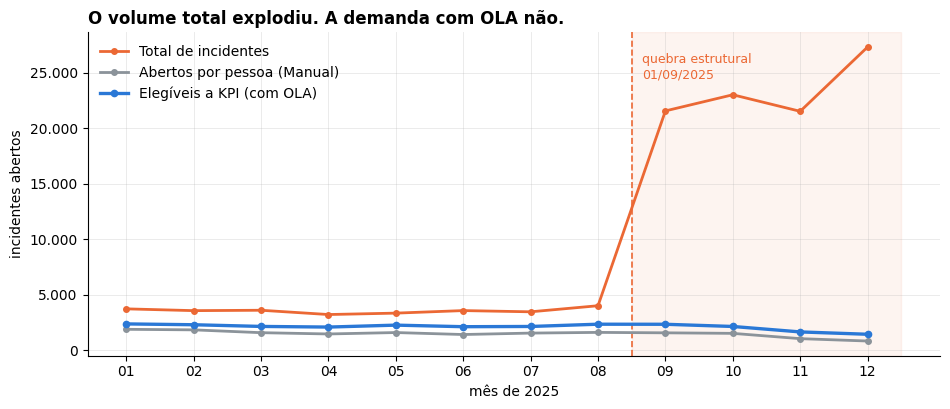

Variação jan-ago -> set-dez (média mensal):
  Total              3.548 -> 23.356   (+558.2%)
  Manual             1.601 -> 1.225   ( -23.5%)
  Elegíveis a KPI    2.206 -> 1.877   ( -14.9%)

LEITURA AUTOMÁTICA: o volume total variou +558%, o aberto por pessoa -23% e a demanda com OLA -15%. As três séries contam histórias diferentes.


In [9]:
# Duas séries mensais no mesmo eixo: tudo x o que exige atendimento com OLA
elig_mes   = d25[d25["Entrou para KPI?"] == "SIM"].groupby("mes").size()
manual_mes = d25[d25["Aberto por"] == "Manual"].groupby("mes").size()
x = np.arange(len(mensal))
rot = [str(m)[-2:] for m in mensal.index]

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.axvspan(7.5, len(x) - .5, color=LARANJA, alpha=.07)
ax.axvline(7.5, color=LARANJA, ls="--", lw=1.2)
ax.annotate("quebra estrutural\n01/09/2025", xy=(7.65, mensal.max() * .98),
            color=LARANJA, fontsize=9, va="top")
ax.plot(x, mensal.values,     "o-", color=LARANJA, lw=2,   ms=4,   label="Total de incidentes")
ax.plot(x, manual_mes.values, "o-", color=CINZA,   lw=2,   ms=4,   label="Abertos por pessoa (Manual)")
ax.plot(x, elig_mes.values,   "o-", color=AZUL,    lw=2.4, ms=4.5, label="Elegíveis a KPI (com OLA)")
ax.set_xticks(x); ax.set_xticklabels(rot)
ax.set_title("O volume total explodiu. A demanda com OLA não.")
ax.set_xlabel("mês de 2025"); ax.set_ylabel("incidentes abertos")
ax.legend(loc="upper left"); eixo_pt(ax)
plt.show()

print("Variação jan-ago -> set-dez (média mensal):")
variacoes = {}
for nome, s in [("Total", mensal), ("Manual", manual_mes), ("Elegíveis a KPI", elig_mes)]:
    a, b = s.iloc[:8].mean(), s.iloc[8:].mean()
    variacoes[nome] = (b / a - 1) * 100
    print(f"  {nome:18s} {br(a)} -> {br(b)}   ({variacoes[nome]:+6.1f}%)")

print()
print(f"LEITURA AUTOMÁTICA: o volume total variou {variacoes['Total']:+.0f}%, "
      f"o aberto por pessoa {variacoes['Manual']:+.0f}% e a demanda com OLA "
      f"{variacoes['Elegíveis a KPI']:+.0f}%. As três séries contam histórias diferentes.")

**O que encontramos.** As três séries contam histórias diferentes: o total dispara, enquanto os incidentes abertos manualmente e os elegíveis a OLA apresentam queda.

Isso muda completamente a modelagem. Se usássemos o volume bruto como target, o modelo aprenderia principalmente a mudança no sistema de monitoramento, e não a demanda de trabalho que queremos antecipar.

Por isso, um dos principais resultados do projeto é também uma recomendação: **antes de prever a demanda, precisamos separar sinal de ruído**. Essa separação evita que uma mudança de instrumentação seja interpretada como aumento real da carga operacional.


## 9 · Definição do target

A escolha do target foi tratada como uma decisão de negócio, e não apenas como uma escolha técnica. Comparamos as séries candidatas olhando estabilidade, dispersão, quantidade de zeros e volume médio.

A ideia foi encontrar uma variável que representasse **o problema que a Locaweb realmente quer antecipar**, sem carregar o ruído da mudança de instrumentação.


In [10]:
idx = pd.date_range("2025-01-01", "2025-12-31", freq="D")

def serie_diaria(sub):
    "Contagem diária reindexada no calendário completo (dias sem incidente viram 0, não somem)."
    return sub.groupby("dia").size().reindex(idx, fill_value=0)

candidatos = {
    "1. Volume total":       serie_diaria(d25),
    "2. Só monitoramento":   serie_diaria(d25[d25["Aberto por"] == "Monitoramento"]),
    "3. Abertos por pessoa": serie_diaria(d25[d25["Aberto por"] == "Manual"]),
    "4. Elegíveis a KPI":    serie_diaria(d25[d25["Entrou para KPI?"] == "SIM"]),
}

linhas = []
for nome, s in candidatos.items():
    a = s.loc[:"2025-08-31"].mean()
    b = s.loc["2025-09-01":].mean()
    linhas.append({"candidato": nome, "n total": int(s.sum()), "média/dia": round(s.mean(), 1),
                   "desvio": round(s.std(), 1), "CV": round(s.std() / s.mean(), 2),
                   "salto set (x)": round(b / a, 2), "dias zerados": int((s == 0).sum())})
comp = pd.DataFrame(linhas).set_index("candidato")
print(comp.to_string())
print()

n_elig = int((d25["Entrou para KPI?"] == "SIM").sum())
n_viol = int((d25["KPI Violado?"] == "SIM").sum())
taxa_viol = n_viol / n_elig * 100
print(f"5. Violações de OLA (alvo de classificação): {n_viol} eventos em {br(n_elig)} elegíveis "
      f"= taxa base de {taxa_viol:.2f}%")
print()
melhor = comp["salto set (x)"].sub(1).abs().idxmin()
print(f"LEITURA AUTOMÁTICA: o candidato mais estável na quebra estrutural é '{melhor}' "
      f"(salto = {comp.loc[melhor, 'salto set (x)']}x, CV = {comp.loc[melhor, 'CV']}, "
      f"{comp.loc[melhor, 'dias zerados']} dias zerados).")

                       n total  média/dia  desvio    CV  salto set (x)  dias zerados
candidato                                                                           
1. Volume total         121811      333.7   330.7  0.99           6.55             0
2. Só monitoramento     104106      285.2   334.0  1.17          11.31             0
3. Abertos por pessoa    17705       48.5    28.1  0.58           0.76             0
4. Elegíveis a KPI       25156       68.9    30.0  0.43           0.85             0

5. Violações de OLA (alvo de classificação): 238 eventos em 25.156 elegíveis = taxa base de 0.95%

LEITURA AUTOMÁTICA: o candidato mais estável na quebra estrutural é '4. Elegíveis a KPI' (salto = 0.85x, CV = 0.43, 0 dias zerados).


**O que encontramos.** A variável que melhor equilibra estabilidade, volume e utilidade operacional é a série de **incidentes elegíveis a KPI/OLA**.

A violação de OLA, por outro lado, aparece em uma frequência muito baixa. Como um classificador que sempre dissesse “não viola” já teria mais de 99% de acerto, não seria responsável apresentar um modelo de classificação como se ele tivesse poder preditivo real com essa base. Preferimos registrar essa limitação e indicar o dado adicional que seria necessário para evoluir esse ponto.

### Target escolhido

> `y_t` = **número de incidentes abertos no dia _t_ com `Entrou para KPI? = SIM`**

**Por que esse target faz sentido?** Ele evita a quebra estrutural, tem volume suficiente para uma previsão diária útil e representa melhor a carga que precisa de acompanhamento humano. Em termos práticos, estamos tentando responder: **“quantos atendimentos relevantes podemos esperar?”**

Isso também aproxima o modelo do objetivo do desafio: antecipar carga, apoiar escala e ajudar a operação a agir antes do pico.


In [11]:
elig = d25[d25["Entrou para KPI?"] == "SIM"].copy()

print("Prioridades presentes no target (confirma exigência de P2 e P3):")
print(elig["Prioridade"].value_counts().to_string())
print()
preench = (elig[["Produto", "Categoria", "Subcategoria"]].notna().mean() * 100).round(1)
print("Preenchimento de Produto/Categoria DENTRO do target (%):")
print(preench.to_string())
print()

y = serie_diaria(elig).rename("y")
print("Resumo estatístico do alvo diário:")
print(y.describe().round(1).to_string())
print()
prios = sorted(elig["Prioridade"].unique())
print(f"LEITURA AUTOMÁTICA: o target contém as prioridades {prios}; "
      f"o preenchimento mínimo entre Produto/Categoria/Subcategoria dentro do recorte é "
      f"{preench.min():.1f}% (contra a taxa de nulos vista na seção 5).")

Prioridades presentes no target (confirma exigência de P2 e P3):
Prioridade
3 - Média    19997
2 - Alta      5159

Preenchimento de Produto/Categoria DENTRO do target (%):
Produto         99.8
Categoria       99.8
Subcategoria    99.8

Resumo estatístico do alvo diário:
count    365.0
mean      68.9
std       30.0
min       10.0
25%       42.0
50%       76.0
75%       90.0
max      186.0

LEITURA AUTOMÁTICA: o target contém as prioridades ['2 - Alta', '3 - Média']; o preenchimento mínimo entre Produto/Categoria/Subcategoria dentro do recorte é 99.8% (contra a taxa de nulos vista na seção 5).


**Nota importante.** Ao escolher o recorte, o problema de nulos que apareceu na seção 5 se resolveu
sozinho: dentro do target, `Produto` e `Categoria` estão quase integralmente preenchidos. Isso
confirma o diagnóstico de que aqueles nulos eram estruturais, e não uma falha de qualidade — e
valida a decisão de **não imputar**.

## 10 · AED — comportamento da série alvo

Com o target definido, entramos na parte mais importante da AED: entender **como essa demanda se comporta no tempo**. Observamos nível, dispersão, tendência, sazonalidade e possíveis efeitos de extração.


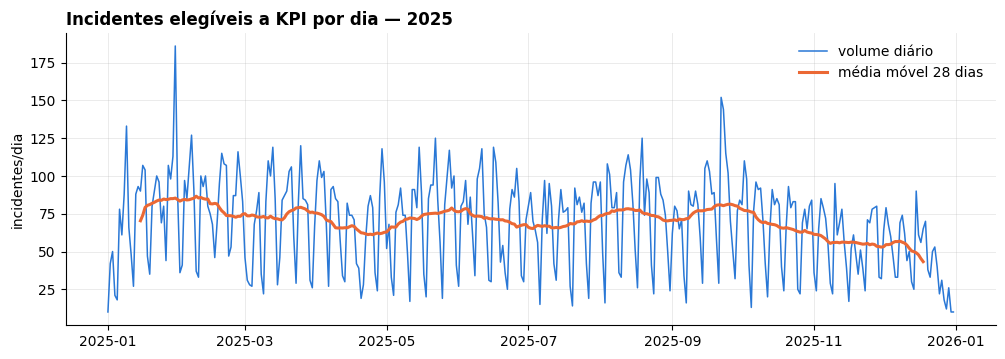

média 68.9 | mediana 76 | desvio 30.0 | mín 10 | máx 186

Média diária por mês:
Jan/25    76.0
Feb/25    81.5
Mar/25    68.7
Apr/25    69.1
May/25    72.5
Jun/25    70.2
Jul/25    68.6
Aug/25    75.2
Sep/25    77.5
Oct/25    68.6
Nov/25    54.5
Dec/25    45.9

LEITURA AUTOMÁTICA: o nível vai de 81.5 chamados/dia no mês mais alto (Feb/25) para 45.9 no mais baixo (Dec/25), uma variação de -44%.


In [12]:
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(y.index, y.values, lw=1.1, color=AZUL, label="volume diário")
ax.plot(y.index, y.rolling(28, center=True).mean(), lw=2.2, color=LARANJA,
        label="média móvel 28 dias")
ax.set_title("Incidentes elegíveis a KPI por dia — 2025")
ax.set_ylabel("incidentes/dia"); ax.legend(); eixo_pt(ax)
plt.show()

print(f"média {y.mean():.1f} | mediana {y.median():.0f} | desvio {y.std():.1f} "
      f"| mín {y.min()} | máx {y.max()}")
print()
med_mes = y.resample("ME").mean().round(1)
print("Média diária por mês:")
print(med_mes.rename(lambda d: d.strftime("%b/%y")).to_string())
print()
print(f"LEITURA AUTOMÁTICA: o nível vai de {med_mes.max():.1f} chamados/dia no mês mais alto "
      f"({med_mes.idxmax():%b/%y}) para {med_mes.min():.1f} no mais baixo "
      f"({med_mes.idxmin():%b/%y}), uma variação de {(med_mes.min()/med_mes.max()-1)*100:+.0f}%.")

**O que encontramos.** Existe uma oscilação forte ao longo da semana e uma queda de nível no último trimestre. A primeira leitura poderia ser simplesmente “a demanda caiu”, mas o notebook vai além e testa se parte dessa queda pode estar ligada ao período de extração e ao recesso de fim de ano.

Esse cuidado é importante porque queremos construir um modelo que funcione fora da amostra, e não apenas explique o passado.


In [13]:
# Teste de censura à direita: se houver, a duração máxima cai perto do fim da base
dur = elig.assign(mes=elig["Aberto"].dt.to_period("M"), dur_h=elig["Duração"] / 3600)
cens = dur.groupby("mes")["dur_h"].agg(
    n="count", mediana="median", p90=lambda s: s.quantile(.90), maxima="max").round(1)
print(cens.to_string())
print()

longos = (dur.assign(l=dur.dur_h > 168).groupby("mes")["l"].mean() * 100).round(1)
print("% de incidentes com duração > 7 dias, por mês de abertura:")
print(longos.to_string())
print()

monot = bool((cens["maxima"].diff().dropna() <= 0).all())
print(f"LEITURA AUTOMÁTICA: a duração MÁXIMA por mês é monotonicamente decrescente? {monot}. "
      f"Vai de {cens['maxima'].iloc[0]:,.0f}h em {cens.index[0]} para "
      f"{cens['maxima'].iloc[-1]:,.0f}h em {cens.index[-1]}; o p90 cai de "
      f"{cens['p90'].max():,.0f}h (pico) para {cens['p90'].iloc[-1]:,.0f}h no último mês. "
      f"Isso é a assinatura de censura à direita.")

            n  mediana     p90  maxima
mes                                   
2025-01  2357      0.9    11.2  7255.1
2025-02  2282      1.0     7.7  7202.5
2025-03  2130      1.0    11.0  6814.8
2025-04  2072      1.4    23.6  6200.1
2025-05  2247      1.4    55.2  5304.5
2025-06  2105      1.2    19.1  4678.6
2025-07  2126      1.2   150.5  4234.7
2025-08  2330      1.7  1413.2  3489.3
2025-09  2324      1.4   438.1  2529.1
2025-10  2126      1.3    69.4  2024.3
2025-11  1634      1.1    13.2  1055.3
2025-12  1423      1.1     9.0   452.7

% de incidentes com duração > 7 dias, por mês de abertura:
mes
2025-01     3.3
2025-02     2.9
2025-03     4.3
2025-04     5.3
2025-05     6.1
2025-06     5.0
2025-07     8.7
2025-08    17.5
2025-09    11.1
2025-10     6.8
2025-11     4.1
2025-12     2.2
Freq: M

LEITURA AUTOMÁTICA: a duração MÁXIMA por mês é monotonicamente decrescente? True. Vai de 7,255h em 2025-01 para 453h em 2025-12; o p90 cai de 1,413h (pico) para 9h no último mês. Isso é a a

**O que encontramos.** Há **evidência forte e compatível com censura à direita**: a duração máxima observada diminui ao longo dos meses e o p90 cai bastante no fim do ano. Isso sugere que a janela de observação pode estar afetando principalmente os incidentes mais longos.

Não tratamos isso como prova de que todos os incidentes longos de dezembro ficaram de fora. Tratamos como uma **limitação de observação** e mantemos a interpretação da queda de nov/dez com cautela.

A escolha de não usar `Duração` como feature também protege o modelo de uma variável que só estaria disponível depois da abertura do incidente.


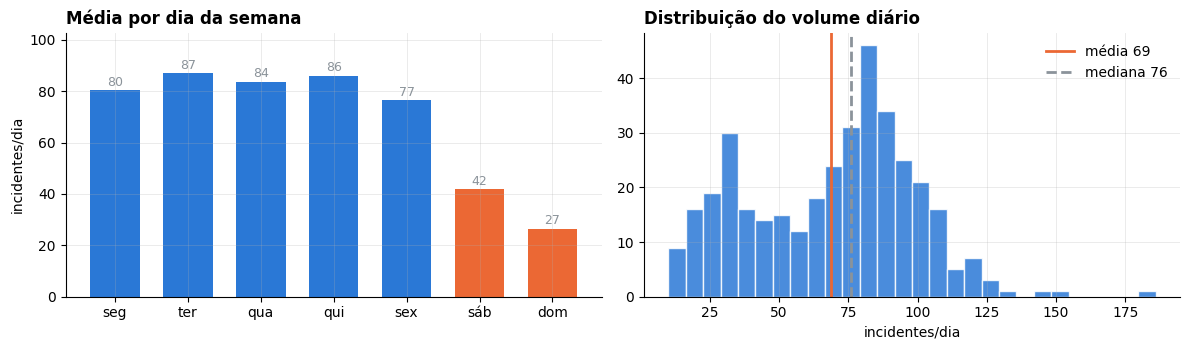

seg    80.3
ter    87.1
qua    83.7
qui    86.1
sex    76.6
sáb    41.8
dom    26.6

Razão entre o maior e o menor dia da semana: 3.28x (ter vs dom)


In [14]:
dias_pt = ["seg", "ter", "qua", "qui", "sex", "sáb", "dom"]
med_dow = y.groupby(y.index.dayofweek).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
cores = [AZUL] * 5 + [LARANJA] * 2
axes[0].bar(dias_pt, med_dow.values, color=cores, width=.68)
for i, v in enumerate(med_dow.values):
    axes[0].text(i, v + med_dow.max() * .02, f"{v:.0f}", ha="center", fontsize=9, color=CINZA)
axes[0].set_title("Média por dia da semana"); axes[0].set_ylabel("incidentes/dia")
axes[0].set_ylim(0, med_dow.max() * 1.18)

axes[1].hist(y.values, bins=28, color=AZUL, alpha=.85, edgecolor="white")
axes[1].axvline(y.mean(),   color=LARANJA, lw=2, label=f"média {y.mean():.0f}")
axes[1].axvline(y.median(), color=CINZA,   lw=2, ls="--", label=f"mediana {y.median():.0f}")
axes[1].set_title("Distribuição do volume diário"); axes[1].set_xlabel("incidentes/dia")
axes[1].legend()
plt.tight_layout(); plt.show()

print(med_dow.round(1).rename(dict(enumerate(dias_pt))).to_string())
razao_dow = med_dow.max() / med_dow.min()
print(f"\nRazão entre o maior e o menor dia da semana: {razao_dow:.2f}x "
      f"({dias_pt[int(med_dow.idxmax())]} vs {dias_pt[int(med_dow.idxmin())]})")

**O que encontramos.** O dia mais movimentado da semana passa de três vezes o volume do dia menos movimentado. A distribuição também é claramente bimodal: fim de semana de um lado e dias úteis do outro.

Isso muda a forma de modelar. Domingo não é um “outlier”; é parte legítima do comportamento da operação. Por isso o calendário entra como informação central do modelo, e os valores baixos não são removidos.


In [15]:
# Os extremos são outliers ou dias explicáveis?
print("=== 10 menores dias ===")
menor = y.nsmallest(10)
print(pd.DataFrame({"valor": menor.values, "dia": [dias_pt[d.dayofweek] for d in menor.index]},
                   index=menor.index.strftime("%Y-%m-%d")).to_string())
print()
print("=== 6 maiores dias ===")
maior = y.nlargest(6)
print(pd.DataFrame({"valor": maior.values, "dia": [dias_pt[d.dayofweek] for d in maior.index]},
                   index=maior.index.strftime("%Y-%m-%d")).to_string())
print()

q1, q3 = y.quantile([.25, .75]); iqr = q3 - q1
lo_iqr, hi_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
mask_iqr = (y < lo_iqr) | (y > hi_iqr)
print(f"Regra IQR global (1,5x): fora de [{lo_iqr:.0f}, {hi_iqr:.0f}] -> {int(mask_iqr.sum())} ponto(s)")
if mask_iqr.any():
    print("  ", [f"{d:%d/%m} ({dias_pt[d.dayofweek]}) = {int(v)}" for d, v in y[mask_iqr].items()])

# A regra do IQR global é enganosa numa série bimodal: o correto é aplicá-la DENTRO de cada
# dia da semana, senão o fim de semana inteiro compete com o dia útil na mesma distribuição.
print()
print("Regra IQR aplicada DENTRO de cada dia da semana (correção para a bimodalidade):")
out_dow = []
for k in range(7):
    s = y[y.index.dayofweek == k]
    a, b = s.quantile([.25, .75]); i_ = b - a
    m = (s < a - 1.5 * i_) | (s > b + 1.5 * i_)
    for d, v in s[m].items():
        out_dow.append((d, int(v), dias_pt[k]))
print(f"  {len(out_dow)} ponto(s) sinalizado(s):")
for d, v, k in sorted(out_dow):
    print(f"    {d:%d/%m/%Y} ({k}) = {v}")

=== 10 menores dias ===
            valor  dia
2025-01-01     10  qua
2025-12-30     10  ter
2025-12-31     10  qua
2025-12-28     12  dom
2025-10-05     13  dom
2025-07-20     14  dom
2025-07-06     15  dom
2025-08-03     16  dom
2025-09-07     16  dom
2025-05-11     17  dom

=== 6 maiores dias ===
            valor  dia
2025-01-30    186  qui
2025-09-22    152  seg
2025-09-23    144  ter
2025-01-09    133  qui
2025-02-06    127  qui
2025-05-22    125  qui

Regra IQR global (1,5x): fora de [-30, 162] -> 1 ponto(s)
   ['30/01 (qui) = 186']

Regra IQR aplicada DENTRO de cada dia da semana (correção para a bimodalidade):
  17 ponto(s) sinalizado(s):
    01/01/2025 (qua) = 10
    25/01/2025 (sáb) = 80
    30/01/2025 (qui) = 186
    23/02/2025 (dom) = 53
    03/03/2025 (seg) = 28
    04/03/2025 (ter) = 27
    21/04/2025 (seg) = 28
    19/08/2025 (ter) = 125
    22/09/2025 (seg) = 152
    23/09/2025 (ter) = 144
    23/12/2025 (ter) = 53
    24/12/2025 (qua) = 40
    25/12/2025 (qui) = 22
  

**O que isso mostrou.** Os menores dias são feriados nacionais, o recesso de fim de ano e domingos.
Os maiores são dias úteis de meio de semana.

**Por que fizemos a regra do IQR duas vezes.** A regra global é a que quase todo notebook aplica — e
numa série **bimodal** ela é enganosa: como fim de semana e dia útil estão na mesma distribuição, os
quartis ficam esticados e a regra praticamente não sinaliza nada. Aplicada **dentro de cada dia da
semana**, ela passa a comparar segunda com segunda e domingo com domingo, que é a comparação
correta. Os dois resultados estão impressos acima justamente para tornar essa diferença visível.

**Decisão sobre outliers.** **Não removemos nenhum ponto.** Todos os pontos sinalizados têm
explicação de calendário. Remover feriado de uma série de demanda seria apagar exatamente o padrão
que queremos que o modelo aprenda. Em vez de remover, **criamos features de feriado** (seção 14)
para o modelo saber tratá-los — e a seção 23 verifica, nos resíduos, se essa decisão funcionou.

## 11 · Estacionariedade e autocorrelação

A Sprint chama atenção para a ordem temporal e para a estacionariedade. Em vez de assumir como a série se comporta, testamos.

Usamos o **teste de Dickey-Fuller aumentado (ADF)** e a ACF para entender duas coisas: se existe tendência persistente e quanto do comportamento de hoje ainda aparece nos próximos dias. Essa leitura ajuda a decidir quais features realmente fazem sentido para previsão.


In [16]:
from statsmodels.tsa.stattools import adfuller

def adf(serie, max_lag=14):
    # ADF com seleção de defasagem por AIC e p-valor.
    s = pd.Series(serie).dropna().astype(float)
    stat, pvalue, usedlag, nobs, crit, icbest = adfuller(
        s, maxlag=max_lag, regression="c", autolag="AIC"
    )
    return stat, pvalue, usedlag, crit

for nome, serie in [("y (série bruta)", y),
                    ("y − média do dia da semana", y - y.groupby(y.index.dayofweek).transform("mean")),
                    ("Δy (1ª diferença)", y.diff().dropna())]:
    t, p, p_sel, vc = adf(serie)
    veredito = "ESTACIONÁRIA (p < 0,05)" if p < 0.05 else "NÃO estacionária (p ≥ 0,05)"
    print(f"{nome:32s} ADF t = {t:7.3f} | p = {p:.4f} | lags={p_sel:2d} -> {veredito}")

print("\nValores críticos de MacKinnon, modelo com constante:")
print({k: round(v, 4) for k, v in adf(y)[3].items()})


y (série bruta)                  ADF t =  -1.292 | p = 0.6330 | lags=14 -> NÃO estacionária (p ≥ 0,05)
y − média do dia da semana       ADF t =  -2.873 | p = 0.0485 | lags= 6 -> ESTACIONÁRIA (p < 0,05)
Δy (1ª diferença)                ADF t =  -7.863 | p = 0.0000 | lags=13 -> ESTACIONÁRIA (p < 0,05)

Valores críticos de MacKinnon, modelo com constante:
{'1%': np.float64(-3.4492), '5%': np.float64(-2.8698), '10%': np.float64(-2.5712)}


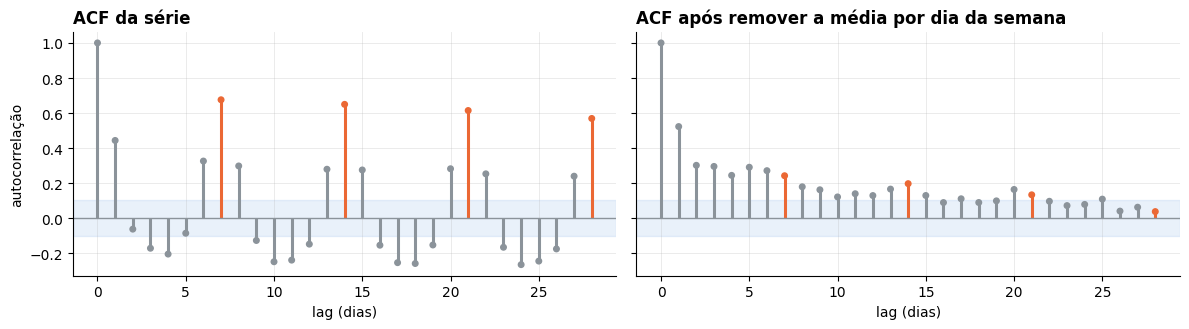

Banda de significância (±1,96/√n) = ±0.103

Lags múltiplos de 7 (série original):
  lag  7: 0.676
  lag 14: 0.650
  lag 21: 0.615
  lag 28: 0.569

Lags curtos após remover o efeito do dia da semana:
  lag  1: 0.523
  lag  2: 0.302
  lag  3: 0.296
  lag  7: 0.243

LEITURA AUTOMÁTICA: pico sazonal máximo em lag 7 = 0.676 (acima da banda). Persistência residual em lag 1 = 0.523 (acima da banda).


In [17]:
def acf(s, nlags=28):
    "Autocorrelação amostral simples (estimador com divisor comum)."
    s = np.asarray(s, float); s = s - s.mean()
    d = (s ** 2).sum()
    return np.array([1.0] + [float((s[k:] * s[:-k]).sum() / d) for k in range(1, nlags + 1)])

a  = acf(y, 28)
resid_dow = y - y.groupby(y.index.dayofweek).transform("mean")
ar = acf(resid_dow, 28)
lim = 1.96 / np.sqrt(len(y))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for ax, dados, tit in [(axes[0], a,  "ACF da série"),
                       (axes[1], ar, "ACF após remover a média por dia da semana")]:
    cor = [LARANJA if (k % 7 == 0 and k > 0) else CINZA for k in range(len(dados))]
    ax.vlines(range(len(dados)), 0, dados, color=cor, lw=2.2)
    ax.scatter(range(len(dados)), dados, color=cor, s=16, zorder=3)
    ax.axhspan(-lim, lim, color=AZUL, alpha=.10)
    ax.axhline(0, color=CINZA, lw=1)
    ax.set_title(tit); ax.set_xlabel("lag (dias)")
axes[0].set_ylabel("autocorrelação")
plt.tight_layout(); plt.show()

print(f"Banda de significância (±1,96/√n) = ±{lim:.3f}\n")
print("Lags múltiplos de 7 (série original):")
for k in (7, 14, 21, 28):
    print(f"  lag {k:2d}: {a[k]:.3f}")
print("\nLags curtos após remover o efeito do dia da semana:")
for k in (1, 2, 3, 7):
    print(f"  lag {k:2d}: {ar[k]:.3f}")
print()
print(f"LEITURA AUTOMÁTICA: pico sazonal máximo em lag 7 = {a[7]:.3f} "
      f"({'acima' if a[7] > lim else 'dentro'} da banda). "
      f"Persistência residual em lag 1 = {ar[1]:.3f} "
      f"({'acima' if ar[1] > lim else 'dentro'} da banda).")

**O que encontramos.** Dois padrões aparecem com bastante clareza:

1. **Sazonalidade semanal forte**, com picos da ACF nos lags 7, 14, 21 e 28.
2. **Persistência de curto prazo**, porque mesmo após retirar o efeito médio do dia da semana ainda existe informação no lag 1.

O ADF reforça essa leitura: a série bruta não é estacionária (p=0,633), enquanto a série ajustada pelo dia da semana fica muito próxima do limite de 5% (p≈0,049), e a primeira diferença é estacionária.

A decisão, portanto, não é “forçar” a série a ficar estacionária a qualquer custo. É **preservar a ordem temporal, representar o calendário e usar apenas informação disponível no passado**.


## 12 · AED — correlações

A Sprint pede investigação de correlações entre variáveis. Imprimimos a matriz **em texto**, e não
só como mapa de calor, para que cada número citado adiante seja auditável.

Matriz de correlação de Pearson (impressa para auditoria):
                         y  ruido_monitoramento  abertos_por_pessoa     p2     p3  dia_util  lag_7  media_28
y                    1.000               -0.111               0.940  0.643  0.985     0.732  0.706     0.277
ruido_monitoramento -0.111                1.000              -0.159  0.022 -0.130     0.076 -0.065    -0.450
abertos_por_pessoa   0.940               -0.159               1.000  0.557  0.937     0.770  0.720     0.280
p2                   0.643                0.022               0.557  1.000  0.502     0.418  0.410     0.154
p3                   0.985               -0.130               0.937  0.502  1.000     0.733  0.705     0.278
dia_util             0.732                0.076               0.770  0.418  0.733     1.000  0.760    -0.001
lag_7                0.706               -0.065               0.720  0.410  0.705     0.760  1.000     0.307
media_28             0.277               -0.450               0.280  

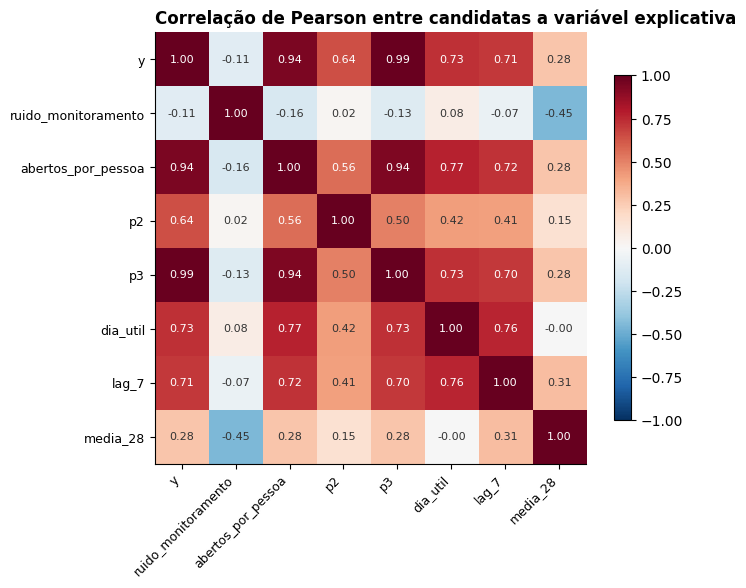

In [18]:
aux = pd.DataFrame({"y": y})
aux["ruido_monitoramento"] = serie_diaria(d25[d25["Aberto por"] == "Monitoramento"])
aux["abertos_por_pessoa"]  = serie_diaria(d25[d25["Aberto por"] == "Manual"])
aux["p2"]        = serie_diaria(elig[elig["Prioridade"] == "2 - Alta"])
aux["p3"]        = serie_diaria(elig[elig["Prioridade"] == "3 - Média"])
aux["dia_util"]  = (aux.index.dayofweek < 5).astype(int)
aux["lag_7"]     = aux["y"].shift(7)
aux["media_28"]  = aux["y"].rolling(28).mean().shift(1)

c = aux.corr(numeric_only=True)
print("Matriz de correlação de Pearson (impressa para auditoria):")
print(c.round(3).to_string())
print()
print("Correlação de cada candidata com o alvo y, ordenada por magnitude:")
print(c["y"].drop("y").reindex(c["y"].drop("y").abs().sort_values(ascending=False).index)
      .round(3).to_string())

fig, ax = plt.subplots(figsize=(7.2, 5.6))
im = ax.imshow(c, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(c))); ax.set_xticklabels(c.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(c))); ax.set_yticklabels(c.columns, fontsize=9)
for i in range(len(c)):
    for j in range(len(c)):
        ax.text(j, i, f"{c.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(c.iloc[i, j]) > .55 else "#333")
ax.set_title("Correlação de Pearson entre candidatas a variável explicativa")
ax.grid(False); fig.colorbar(im, shrink=.8)
plt.show()

**O que isso mostrou.** Quatro leituras que orientam a modelagem (todos os valores estão na tabela
impressa acima):

- `p3` e `abertos_por_pessoa` têm correlação altíssima com o alvo. Isso **não é informação útil**:
  P3 é a maior parte do próprio alvo, e "aberto por pessoa" é quase o mesmo conjunto de incidentes.
  São correlações **tautológicas** — usá-las como features seria vazamento disfarçado de sinal.
- `dia_util` é o driver **externo** mais forte, confirmando a seção 9.
- `lag_7` e `media_28` trazem informação de nível e são pouco correlacionados **entre si**, então
  os dois têm algo distinto a contribuir (um é "a semana passada", o outro é "o patamar do mês").
- `ruido_monitoramento` tem correlação praticamente nula com o alvo. Guardem esse número: na
  seção 16 mostramos que uma variável com correlação quase zero ainda assim consegue destruir o
  modelo — porque o problema dela não é correlação, é **escala e estacionariedade**.

**Uma ressalva metodológica.** A correlação de Pearson mede associação **linear e contemporânea**.
Ela não detecta relação defasada nem não-linear, e em série temporal duas séries com tendência comum
correlacionam sem nenhuma relação causal (correlação espúria). Por isso ela orienta, mas não decide:
a decisão sobre features é tomada por validação cruzada temporal na seção 18.

## 13 · Análise por prioridade, produto e equipe

O enunciado exige análise de tendência **por prioridade (P2 e P3 obrigatórias)** agrupada por
categoria, produto ou item de configuração. Além de cumprir o requisito, isso alimenta o dashboard
da disciplina de Data Visualization.

Prioridade  2 - Alta  3 - Média  % P2
Aberto                               
2025-01          552       1805  23.4
2025-02          470       1812  20.6
2025-03          470       1660  22.1
2025-04          393       1679  19.0
2025-05          375       1872  16.7
2025-06          409       1696  19.4
2025-07          386       1740  18.2
2025-08          414       1916  17.8
2025-09          442       1882  19.0
2025-10          436       1690  20.5
2025-11          448       1186  27.4
2025-12          364       1059  25.6

LEITURA AUTOMÁTICA: a participação de P2 vai de 16.7% (2025-05) a 27.4% (2025-11), enquanto o volume mensal total varia de 1,423 a 2,357.


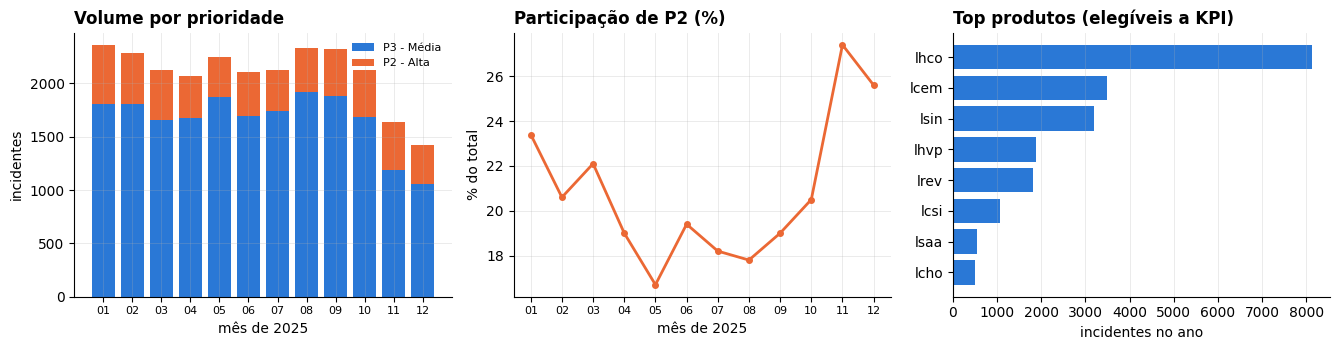

In [19]:
mix = pd.crosstab(elig["Aberto"].dt.to_period("M"), elig["Prioridade"])
col_p2 = "2 - Alta"; col_p3 = "3 - Média"
mix["% P2"] = (mix[col_p2] / mix[[col_p2, col_p3]].sum(axis=1) * 100).round(1)
print(mix.to_string())
print()
print(f"LEITURA AUTOMÁTICA: a participação de P2 vai de {mix['% P2'].min():.1f}% "
      f"({mix['% P2'].idxmin()}) a {mix['% P2'].max():.1f}% ({mix['% P2'].idxmax()}), "
      f"enquanto o volume mensal total varia de {mix[[col_p2, col_p3]].sum(axis=1).min():,} "
      f"a {mix[[col_p2, col_p3]].sum(axis=1).max():,}.")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
m = np.arange(len(mix))
axes[0].bar(m, mix[col_p3], color=AZUL, label="P3 - Média")
axes[0].bar(m, mix[col_p2], bottom=mix[col_p3], color=LARANJA, label="P2 - Alta")
axes[0].set_xticks(m); axes[0].set_xticklabels([str(i)[-2:] for i in mix.index], fontsize=8)
axes[0].set_title("Volume por prioridade"); axes[0].legend(fontsize=8)
axes[0].set_xlabel("mês de 2025"); axes[0].set_ylabel("incidentes")

axes[1].plot(m, mix["% P2"], "o-", color=LARANJA, lw=2, ms=4)
axes[1].set_xticks(m); axes[1].set_xticklabels([str(i)[-2:] for i in mix.index], fontsize=8)
axes[1].set_title("Participação de P2 (%)"); axes[1].set_ylabel("% do total")
axes[1].set_xlabel("mês de 2025")

top_prod = elig["Produto"].value_counts().head(8)
axes[2].barh(top_prod.index[::-1].astype(str), top_prod.values[::-1], color=AZUL)
axes[2].set_title("Top produtos (elegíveis a KPI)"); axes[2].grid(axis="y", alpha=0)
axes[2].set_xlabel("incidentes no ano")
plt.tight_layout(); plt.show()

In [20]:
print("=== Concentração por equipe ===")
eq = elig["Grupo designado"].value_counts()
eq_pct = (eq / eq.sum() * 100).round(1)
conc = pd.DataFrame({"incidentes": eq.head(6), "%": eq_pct.head(6),
                     "% acum": eq_pct.head(6).cumsum().round(1)})
print(conc.to_string())
print()

print("=== Carga mensal e variação no ano — 4 maiores equipes ===")
top4 = eq.head(4).index.tolist()
ct = pd.crosstab(elig["Grupo designado"], elig["Aberto"].dt.to_period("M")).loc[top4]
print(ct.to_string())
print()
var_eq = {t: (ct.loc[t].iloc[-1] / ct.loc[t].iloc[0] - 1) * 100 for t in top4}
for t, v in var_eq.items():
    print(f"  {t}: {ct.loc[t].iloc[0]} (jan) -> {ct.loc[t].iloc[-1]} (dez)  ({v:+.0f}%)")
pior = min(var_eq, key=var_eq.get)
print(f"\nLEITURA AUTOMÁTICA: as {len(top4)} maiores equipes concentram "
      f"{conc['% acum'].iloc[len(top4)-1]:.1f}% dos incidentes com OLA. "
      f"A maior retração de carga é de {pior} ({var_eq[pior]:+.0f}%); "
      f"as demais variam entre {min(v for k, v in var_eq.items() if k != pior):+.0f}% e "
      f"{max(var_eq.values()):+.0f}%.")

print()
print("=== Top categorias ===")
cat = elig["Categoria"].value_counts().head(5)
print(pd.DataFrame({"n": cat, "%": (cat / elig["Categoria"].notna().sum() * 100).round(1)}).to_string())
print()
print("=== Códigos de fechamento ===")
cf = elig["Código de fechamento"].value_counts().head(6)
print(pd.DataFrame({"n": cf, "%": (cf / elig["Código de fechamento"].notna().sum() * 100).round(1)}).to_string())
print()

print("=== Violação de OLA por prioridade (contagem e TAXA) ===")
k = elig[elig["KPI Violado?"].notna()]
tab_viol = pd.crosstab(k["Prioridade"], k["KPI Violado?"])
tab_viol["taxa % de violação"] = (tab_viol.get("SIM", 0) / tab_viol.sum(axis=1) * 100).round(2)
print(tab_viol.to_string())

=== Concentração por equipe ===
                 incidentes     %  % acum
Grupo designado                          
Team14                 8932  35.5    35.5
Team11                 8642  34.4    69.9
Team05                 3393  13.5    83.4
Team09                 1993   7.9    91.3
Team17                  478   1.9    93.2
Team03                  415   1.6    94.8

=== Carga mensal e variação no ano — 4 maiores equipes ===
Aberto           2025-01  2025-02  2025-03  2025-04  2025-05  2025-06  2025-07  2025-08  2025-09  2025-10  2025-11  2025-12
Grupo designado                                                                                                            
Team14               769      761      686      643      597      641      698      977     1051      859      645      605
Team11               777      813      711      819     1089      885      796      660      651      613      453      375
Team05               405      277      371      247      219      276      3

**O que encontramos.** Alguns resultados são especialmente úteis para transformar o modelo em decisão:

1. A participação de **P2 aumenta** no segundo semestre, mesmo enquanto o volume cai. Isso significa que menos chamados não necessariamente significam menos pressão operacional.
2. A carga está concentrada em poucas equipes. Isso indica onde uma estratégia de capacidade pode gerar maior impacto.
3. A retração aparece em várias equipes, então existe uma pergunta importante para a Locaweb: estamos vendo automação, mudança de escopo ou redistribuição de trabalho?
4. Um código de fechamento concentra grande parte dos encerramentos, o que pode apontar para uma oportunidade de análise preventiva.

Também calculamos a taxa de violação de OLA por prioridade. As taxas ficam baixas, o que reforça a decisão de não vender uma classificação de “risco de violação” que a base atual não consegue sustentar com confiança.


## 14 · Engenharia de features

Aqui está uma das decisões mais importantes do projeto: **cada horizonte tem sua própria visão do passado**.

A regra é simples: se queremos prever o dia **T** a partir de **T−h**, nenhuma feature pode usar informação depois de T−h. Em outras palavras, para um horizonte D+7, não podemos usar um dado que só estaria disponível seis dias antes da previsão.

Por isso a função `montar_features(base, h)` recebe o horizonte como parâmetro. O controle de leakage acontece dentro da própria construção das features, o que torna o processo mais seguro e menos dependente de lembrar regras manualmente.


In [21]:
# Feriados nacionais brasileiros de 2025, fixos no código (sem dependência externa,
# para o notebook rodar em qualquer máquina, inclusive sem internet).
FERIADOS = pd.to_datetime([
    "2025-01-01",                # Confraternização Universal
    "2025-03-03", "2025-03-04",  # Carnaval (móvel)
    "2025-04-18",                # Paixão de Cristo (móvel)
    "2025-04-21",                # Tiradentes
    "2025-05-01",                # Dia do Trabalho
    "2025-06-19",                # Corpus Christi (móvel)
    "2025-09-07",                # Independência
    "2025-10-12",                # Nossa Senhora Aparecida
    "2025-11-02",                # Finados
    "2025-11-15",                # Proclamação da República
    "2025-11-20",                # Consciência Negra
    "2025-12-25",                # Natal
])
print(f"{len(FERIADOS)} feriados nacionais cadastrados para 2025.")

# Painel diário com o alvo e os agregados operacionais (mix de prioridade, equipe e produto).
# Os 'sh_*' são SHARES do próprio dia; só entram no modelo depois de defasados por h.
base = pd.DataFrame({"y": y})
base["n_total"] = serie_diaria(d25)

top_equipes = elig["Grupo designado"].value_counts().head(2).index.tolist()
top_produto = elig["Produto"].value_counts().index[0]
mix_specs = [("sh_p2", elig["Prioridade"] == "2 - Alta"),
             (f"sh_eq1", elig["Grupo designado"] == top_equipes[0]),
             (f"sh_eq2", elig["Grupo designado"] == top_equipes[1]),
             ("sh_prod1", elig["Produto"] == top_produto)]
for nome, mask in mix_specs:
    base[nome] = (serie_diaria(elig[mask]) / base["y"].replace(0, np.nan)).fillna(0)

print(f"Equipes usadas no mix: {top_equipes} | produto: {top_produto}")
print(base.head(3).round(3).to_string())
print(f"\nPainel diário: {base.shape[0]} dias x {base.shape[1]} colunas")

13 feriados nacionais cadastrados para 2025.
Equipes usadas no mix: ['Team14', 'Team11'] | produto: lhco
             y  n_total  sh_p2  sh_eq1  sh_eq2  sh_prod1
2025-01-01  10       34  0.400   0.600   0.200     0.400
2025-01-02  42       55  0.095   0.167   0.429     0.119
2025-01-03  50       77  0.200   0.180   0.240     0.240

Painel diário: 365 dias x 6 colunas


In [22]:
def montar_features(base, h):
    # Features para prever y[T] usando SOMENTE informação disponível até T-h.
    #
    # REGRA ANTI-LEAKAGE: todo shift aplicado ao alvo é >= h.
    # Se a origem da previsão é o fim do dia T-h, conhecemos y integralmente até T-h.
    # Logo y.shift(k) só é legítimo para k >= h; o mesmo vale para qualquer janela móvel,
    # que precisa ser deslocada por h depois de calculada.
    b = base.copy()
    X = pd.DataFrame(index=b.index)

    # --- 1. Calendário (conhecido com qualquer antecedência, nunca vaza) ---
    dow = b.index.dayofweek
    for k in range(6):                      # domingo (6) é a CATEGORIA DE REFERÊNCIA
        X[f"dow_{k}"] = (dow == k).astype(int)
    # NOTA: NÃO criamos 'fim_semana'. Ele seria uma combinação linear exata das dummies
    # acima com o intercepto (fim_semana = 1 - dow_0 - dow_1 - dow_2 - dow_3 - dow_4),
    # produzindo multicolinearidade perfeita e coeficientes não identificáveis.
    # A verificação empírica está na seção 15.
    X["dia_mes"] = b.index.day             # proxy de ciclo de fechamento mensal

    # --- 2. Feriados ---
    X["feriado"]     = b.index.isin(FERIADOS).astype(int)
    X["vespera_fer"] = b.index.isin(FERIADOS - pd.Timedelta("1D")).astype(int)
    X["pos_fer"]     = b.index.isin(FERIADOS + pd.Timedelta("1D")).astype(int)

    # --- 3. Lags do alvo (só os permitidos pelo horizonte) ---
    for L in sorted({h, h + 1, h + 2, 7, 14, 21, 28}):
        if L >= h:
            X[f"lag_{L}"] = b["y"].shift(L)

    # --- 4. Janelas móveis, todas deslocadas por h ---
    X["med_7"]      = b["y"].rolling(7).mean().shift(h)
    X["med_28"]     = b["y"].rolling(28).mean().shift(h)
    X["dp_7"]       = b["y"].rolling(7).std().shift(h)
    X["mediana_28"] = b["y"].rolling(28).median().shift(h)

    # --- 5. Tendência (nível da semana contra o nível do mês) ---
    X["tend"]  = X["med_7"] - X["med_28"]       # diferença absoluta
    X["razao"] = X["med_7"] / X["med_28"]       # a mesma ideia, em escala relativa

    # --- 6. Mix operacional (candidatas — serão TESTADAS, não assumidas) ---
    for c in [n for n, _ in mix_specs]:
        X[c + "_7d"] = b[c].rolling(7).mean().shift(h)

    # --- 7. Ruído de alarmística (candidata suspeita — teste na seção 16) ---
    X["ruido_7d"] = (b["n_total"] - b["y"]).rolling(7).mean().shift(h)
    return X


X1 = montar_features(base, h=1)
X7 = montar_features(base, h=7)
print(f"D+1: {X1.shape[1]} features | lags = {[c for c in X1 if c.startswith('lag_')]}")
print(f"D+7: {X7.shape[1]} features | lags = {[c for c in X7 if c.startswith('lag_')]}")
print("\nRepare: o conjunto D+7 simplesmente NÃO TEM lag_1, lag_2 e lag_3.")
print("Não é uma opção de modelagem, é uma impossibilidade física do horizonte.")

# Verificação automática da regra anti-leakage: nenhuma feature pode ter correlação
# perfeita com y[T] por construção; e todo lag precisa ser >= h.
for h_, Xh in [(1, X1), (7, X7)]:
    lags = [int(c.split("_")[1]) for c in Xh if c.startswith("lag_")]
    assert all(L >= h_ for L in lags), f"LEAKAGE: lag < h no horizonte {h_}"
print("\nOK — asserção anti-leakage passou nos dois horizontes.")

D+1: 28 features | lags = ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28']
D+7: 27 features | lags = ['lag_7', 'lag_8', 'lag_9', 'lag_14', 'lag_21', 'lag_28']

Repare: o conjunto D+7 simplesmente NÃO TEM lag_1, lag_2 e lag_3.
Não é uma opção de modelagem, é uma impossibilidade física do horizonte.

OK — asserção anti-leakage passou nos dois horizontes.


### Utilidade, vantagens e limitações de cada grupo de features

O enunciado pede explicitamente as **limitações**, não só a utilidade. Segue a leitura honesta.

| Grupo | Utilidade | Vantagem | **Limitação** |
|---|---|---|---|
| **Calendário** (`dow_0..dow_5`) | Captura a sazonalidade semanal, que a ACF da seção 10 mostrou ser o padrão dominante | Nunca vaza — o calendário do ano que vem já é conhecido hoje | Domingo é a categoria de referência; o efeito de cada dia é lido **contra domingo**, não em absoluto. Não capta feriado móvel automaticamente nem eventos pontuais (migração planejada, campanha) |
| **`dia_mes`** | Proxy de ciclo de fechamento mensal (faturamento, corte de billing) | Custo zero, sempre disponível | Entra como **inteiro linear**, o que impõe a hipótese de que o dia 31 "vale 31×" o dia 1 — hipótese fraca. Só se justifica porque a validação cruzada da seção 18 não mostrou perda; a alternativa correta seria codificação cíclica (seno/cosseno) |
| **Feriados** | Explica os menores dias do ano (Ano Novo, Independência, recesso) | Transforma o que pareceria outlier em informação modelável — é o que sustenta a decisão de **não remover outliers** (seção 9) | **Só há 13 feriados em 1 ano.** Amostra pequena demais para one-hot por feriado; por isso usamos flag genérica. O modelo aprende "feriado reduz", não "Carnaval reduz X%". Véspera e pós são ainda mais raros |
| **Lags** (`lag_h … lag_28`) | Nível recente da série | `lag_7` sozinho já é um baseline forte — é literalmente o baseline sazonal | Para D+7 o lag mínimo é 7: o modelo fica **cego para a última semana** e não reage a choques recentes. É limite do horizonte, não do modelo. Lags são fortemente correlacionados entre si → colinearidade (seção 15) |
| **Janelas móveis** (`med_7`, `med_28`, `dp_7`, `mediana_28`) | Suavizam ruído diário e dão o nível de base | Mais estáveis que um lag isolado; `mediana_28` é robusta a um dia atípico | A média de 7 dias **mistura fim de semana com dia útil**; só funciona bem acompanhada das dummies de dia da semana. `dp_7` é volatilidade passada, não futura |
| **Tendência** (`tend`, `razao`) | Detecta se a semana está acima ou abaixo do patamar do mês | É o que sinaliza mudança de regime | Reage com cerca de uma semana de atraso: **confirma** quebras, não antecipa. Além disso `tend` e `razao` são a mesma informação em escalas diferentes → alta colinearidade, medida na seção 15 |
| **Mix operacional** (`sh_*_7d`) | Atende à exigência de análise por prioridade/produto/equipe | Um aumento no share de P2 sugere pressão maior do que a contagem indica | São séries muito estáveis — **podem não contribuir nada**. Medimos na seção 18 e reportamos o resultado mesmo que seja negativo |
| **Ruído de alarmística** (`ruido_7d`) | Hipótese: o volume automático poderia indicar saúde da infraestrutura | — | **Sofre a quebra estrutural de setembro** e por isso é não-estacionária. Suspeitamos que seja destrutiva; testamos na seção 16 em vez de descartar por intuição |

## 15 · Auditoria de Data Leakage

Data Leakage é um dos maiores riscos deste projeto porque pode produzir um modelo que parece ótimo no notebook e falha no mundo real. Por isso decidimos não apenas dizer que evitamos leakage: **testamos onde ele poderia acontecer e mostramos o impacto quando ele acontece**.

Primeiro removemos variáveis que só existem depois da abertura do incidente. Depois testamos o caso mais traiçoeiro em séries temporais: usar um lag menor do que o horizonte de previsão.


In [23]:
proibidas = pd.DataFrame([
    ("Duração", "Só existe quando o incidente fecha", "Prever o volume de hoje usando o tempo de resolução de hoje"),
    ("Resolvido", "Preenchida na resolução", "Mesma coisa; é nula justamente nos ainda não resolvidos"),
    ("Encerrado", "Preenchida no fechamento", "Conhecer o futuro do próprio dia"),
    ("Código de fechamento", "Classificação feita ao encerrar", "Saber a causa antes do efeito"),
    ("KPI Violado?", "Só se sabe após vencer o prazo", "Usar o desfecho para prever a chegada"),
    ("Solução", "Texto escrito na resolução", "Idem"),
    ("Status", "Muda ao longo do ciclo de vida", "Estado final observado no passado do próprio alvo"),
], columns=["coluna", "quando é preenchida", "por que vazaria"])
print(proibidas.to_string(index=False))
print()

PROIBIDAS = set(proibidas["coluna"])
usadas = sorted(X7.columns.tolist())
print("Features candidatas (D+7) — confirmação de que nenhuma coluna proibida entrou:")
print(usadas)
assert not (PROIBIDAS & set(usadas)), "LEAKAGE: coluna proibida entre as features"
print("\nOK — asserção passou: nenhuma coluna proibida entre as features.")

              coluna                quando é preenchida                                             por que vazaria
             Duração Só existe quando o incidente fecha Prever o volume de hoje usando o tempo de resolução de hoje
           Resolvido            Preenchida na resolução     Mesma coisa; é nula justamente nos ainda não resolvidos
           Encerrado           Preenchida no fechamento                            Conhecer o futuro do próprio dia
Código de fechamento    Classificação feita ao encerrar                               Saber a causa antes do efeito
        KPI Violado?     Só se sabe após vencer o prazo                       Usar o desfecho para prever a chegada
             Solução         Texto escrito na resolução                                                        Idem
              Status     Muda ao longo do ciclo de vida           Estado final observado no passado do próprio alvo

Features candidatas (D+7) — confirmação de que nenhuma coluna proibida 

### 14.2 · Demonstração: o que acontece se usarmos um lag proibido

Para D+7, usar `lag_1` parece inocente porque o código funciona normalmente. O problema é operacional: essa informação ainda não estaria disponível no momento em que a previsão D+7 precisasse ser gerada.

Fizemos esse teste de propósito para mostrar que **um número melhor pode ser, na verdade, um número errado**.


In [24]:
from sklearn.linear_model import LinearRegression, RidgeCV, PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

def mae(a, p):  return float(np.mean(np.abs(np.asarray(a, float) - np.asarray(p, float))))
def rmse(a, p): return float(np.sqrt(np.mean((np.asarray(a, float) - np.asarray(p, float)) ** 2)))
def mape(a, p):
    a, p = np.asarray(a, float), np.asarray(p, float)
    return float(np.nanmean(np.abs((a - p) / np.where(a == 0, np.nan, a))) * 100)

# Partição temporal (detalhada e justificada na seção 17)
TR = ("2025-01-01", "2025-09-07")
VA = ("2025-09-08", "2025-11-02")
TE = ("2025-11-03", "2025-12-28")

CAL = [c for c in X7 if c.startswith("dow_")] + ["dia_mes", "feriado", "vespera_fer", "pos_fer"]
JAN = ["med_7", "med_28", "dp_7", "mediana_28"]
TEN = ["tend", "razao"]
LAGS = lambda X: sorted([c for c in X if c.startswith("lag_")], key=lambda s: int(s.split("_")[1]))
MIX  = lambda X: [c for c in X if c.startswith("sh_")]
def base_feats(X): return CAL + LAGS(X) + JAN + TEN

lin = lambda: make_pipeline(StandardScaler(), LinearRegression())

X_ok  = X7[base_feats(X7)].copy()
X_vaz = X_ok.copy()
X_vaz["lag_1_PROIBIDO"] = base["y"].shift(1)   # informação de ontem, indisponível a 7 dias

res_leak = {}
for nome, XX in [("Honesto (todos os lags >= 7)", X_ok), ("VAZADO  (usa lag_1)", X_vaz)]:
    dfm = XX.join(base["y"]).dropna()
    tr, va = dfm.loc[TR[0]:TR[1]], dfm.loc[VA[0]:VA[1]]
    m = lin().fit(tr.drop(columns="y"), tr["y"])
    p = m.predict(va.drop(columns="y"))
    res_leak[nome] = mae(va["y"], p)
    print(f"{nome:32s} MAE na validação = {res_leak[nome]:6.2f}")

hon, vaz = res_leak["Honesto (todos os lags >= 7)"], res_leak["VAZADO  (usa lag_1)"]
print(f"\nLEITURA AUTOMÁTICA: o modelo vazado reporta um MAE {(1 - vaz/hon)*100:.0f}% menor "
      f"({vaz:.2f} contra {hon:.2f}). Esse ganho é INALCANÇÁVEL em produção — no dia em que a "
      f"previsão D+7 for pedida, o valor de 'ontem em relação ao alvo' ainda não terá acontecido.")

Honesto (todos os lags >= 7)     MAE na validação =  12.60
VAZADO  (usa lag_1)              MAE na validação =  10.98

LEITURA AUTOMÁTICA: o modelo vazado reporta um MAE 13% menor (10.98 contra 12.60). Esse ganho é INALCANÇÁVEL em produção — no dia em que a previsão D+7 for pedida, o valor de 'ontem em relação ao alvo' ainda não terá acontecido.


**O que isso mostrou.** O modelo vazado reporta um erro menor — e o problema é que esse número é
**impossível de reproduzir na operação**. O modelo entregaria em produção um erro pior do que o
relatório prometeu, e a diferença só apareceria depois que a Locaweb já tivesse dimensionado
plantão com base nele.

**Por isso a função `montar_features` recebe `h`.** O leakage não é evitado por disciplina do
analista na hora de escolher colunas — ele é evitado **por construção, no código**, e verificado por
`assert` a cada execução.

### 14.3 · Leakage no processo de validação

O mesmo cuidado vale para a validação cruzada. Três regras que seguimos no notebook inteiro:

1. **Nada de `train_test_split` aleatório.** Embaralhar os dias colocaria o futuro no treino.
2. **`TimeSeriesSplit` com `gap=h`.** Entre o fim de cada janela de treino e o início do fold de
   teste ficam `h` dias de vácuo, replicando a defasagem que existe na operação real. Sem o `gap`,
   o fold de teste começaria no dia seguinte ao treino e as janelas móveis atravessariam a fronteira.
3. **O padronizador (`StandardScaler`) fica dentro do `Pipeline`.** Se a média e o desvio fossem
   calculados sobre a base inteira antes de particionar, estatísticas do futuro entrariam no treino —
   um leakage sutil e frequente. Dentro do pipeline, o scaler é reajustado em cada fold.

Uma quarta regra, aplicada na seção 21: **o conjunto de teste não é tocado** durante nenhuma seleção
de feature ou de modelo.

## 16 · Diagnóstico de multicolinearidade

Como queremos interpretar as variáveis, não basta o modelo prever bem. Também precisamos garantir que os coeficientes façam sentido.

Por isso verificamos se a matriz de features tem posto completo e calculamos VIF. O objetivo aqui é simples: evitar que duas variáveis contem a mesma história e façam o modelo dividir um efeito de forma artificial.


In [25]:
def vif(Xdf):
    "Variance Inflation Factor de cada coluna, via R² da regressão dela contra as demais."
    out = {}
    M = Xdf.values.astype(float)
    for j, c in enumerate(Xdf.columns):
        outros = np.delete(M, j, axis=1)
        A = np.column_stack([np.ones(len(M)), outros])
        beta, *_ = np.linalg.lstsq(A, M[:, j], rcond=None)
        resid = M[:, j] - A @ beta
        sst = float(((M[:, j] - M[:, j].mean()) ** 2).sum())
        r2 = 1 - float(resid @ resid) / sst if sst > 0 else 1.0
        out[c] = np.inf if r2 >= 1 - 1e-10 else 1 / (1 - r2)
    return pd.Series(out).sort_values(ascending=False)

def posto_completo(Xdf):
    A = np.column_stack([np.ones(len(Xdf)), Xdf.values.astype(float)])
    return int(np.linalg.matrix_rank(A)), A.shape[1], float(np.linalg.cond(A))

Xd = X1[base_feats(X1)].join(base["y"]).dropna().drop(columns="y")

# (a) posto da matriz de desenho COM intercepto
r_, k_, cond_ = posto_completo(Xd)
print(f"Matriz de desenho (com intercepto): {len(Xd)} linhas x {k_} colunas | posto = {r_}")
print(f"  -> posto completo? {r_ == k_}   número de condição = {cond_:.3e}")

# (b) contraprova didática nº 1: e se tivéssemos criado a flag 'fim_semana'?
Xd_fs = Xd.copy()
Xd_fs["fim_semana"] = (Xd.index.dayofweek >= 5).astype(int)
r2_, k2_, _ = posto_completo(Xd_fs)
print(f"\nCONTRAPROVA 1 — mesma matriz acrescida de 'fim_semana': "
      f"{k2_} colunas, posto {r2_} -> posto completo? {r2_ == k2_}")
print("  Identidade exata: fim_semana == 1 - dow_0 - dow_1 - dow_2 - dow_3 - dow_4 ?",
      bool(np.allclose(Xd_fs["fim_semana"].values,
                       1 - Xd[["dow_0", "dow_1", "dow_2", "dow_3", "dow_4"]].values.sum(axis=1))))

# (c) contraprova nº 2: 'tend' também é combinação linear exata do que já existe
print(f"\nCONTRAPROVA 2 — identidade exata: tend == med_7 - med_28 ?",
      bool(np.allclose(Xd["tend"].values, Xd["med_7"].values - Xd["med_28"].values)))
print("  Ou seja, {med_7, med_28, tend} juntos JÁ tornam a matriz deficiente em posto,")
print("  mesmo sem 'fim_semana'. Um modelo linear não extrai nada de 'tend' nesse caso;")
print("  a variável só teria valor para modelos de árvore, que não formam combinações lineares.")

print("\n--- VIF do conjunto ANTES da poda (D+1) ---")
v_antes = vif(Xd)
print(v_antes.round(2).to_string())

Matriz de desenho (com intercepto): 337 linhas x 24 colunas | posto = 23
  -> posto completo? False   número de condição = 3.839e+16

CONTRAPROVA 1 — mesma matriz acrescida de 'fim_semana': 25 colunas, posto 23 -> posto completo? False
  Identidade exata: fim_semana == 1 - dow_0 - dow_1 - dow_2 - dow_3 - dow_4 ? True

CONTRAPROVA 2 — identidade exata: tend == med_7 - med_28 ? True
  Ou seja, {med_7, med_28, tend} juntos JÁ tornam a matriz deficiente em posto,
  mesmo sem 'fim_semana'. Um modelo linear não extrai nada de 'tend' nesse caso;
  a variável só teria valor para modelos de árvore, que não formam combinações lineares.

--- VIF do conjunto ANTES da poda (D+1) ---
med_28           inf
tend             inf
med_7            inf
razao          57.75
mediana_28     14.12
dow_3          13.00
dow_1          12.88
dow_2          12.69
dow_4          10.47
dow_0           8.95
lag_3           6.11
lag_1           5.91
lag_7           5.47
lag_2           5.33
lag_21          4.13
lag_14

In [26]:
def pruna_por_posto(Xdf, feats, verbose=True):
    """Remove, uma a uma, as features que NÃO aumentam o posto da matriz de desenho.

    Uma coluna que não aumenta o posto é combinação linear exata das anteriores: ela não
    acrescenta informação nenhuma a um modelo linear e destrói a identificabilidade dos
    coeficientes. A ordem de varredura preserva as features mais simples/interpretáveis
    (calendário e lags vêm antes das derivadas), então o que cai é sempre a variável
    redundante, nunca a original.
    """
    mantidas, descartadas = [], []
    A = np.ones((len(Xdf), 1))
    posto = 1
    for c in feats:
        A_try = np.column_stack([A, Xdf[c].values.astype(float)])
        r = np.linalg.matrix_rank(A_try)
        if r > posto:
            mantidas.append(c); A, posto = A_try, r
        else:
            descartadas.append(c)
    if verbose and descartadas:
        print(f"  poda por posto: descartadas {descartadas} (combinação linear exata das demais)")
    return mantidas

feats_podado = pruna_por_posto(Xd, base_feats(X1))
Xd_p = Xd[feats_podado]
r3_, k3_, cond3_ = posto_completo(Xd_p)
print(f"\nApós a poda: {k3_} colunas | posto {r3_} -> posto completo? {r3_ == k3_} | "
      f"condição = {cond3_:.3e}")
print(f"Redução do número de condição: {cond_:.1e} -> {cond3_:.1e}")

print("\n--- VIF DEPOIS da poda (todos finitos) ---")
v_dep = vif(Xd_p)
print(v_dep.round(2).to_string())
altos = v_dep[v_dep > 10]
print(f"\nLEITURA AUTOMÁTICA: antes da poda havia "
      f"{int(np.isinf(v_antes).sum())} feature(s) com VIF infinito (dependência exata). "
      f"Depois da poda não há nenhuma; restam {len(altos)} com VIF > 10, que é colinearidade "
      f"ALTA mas não perfeita — tolerável para predição, tratada por Ridge e por importância "
      f"de permutação na seção 20.")

  poda por posto: descartadas ['tend'] (combinação linear exata das demais)

Após a poda: 23 colunas | posto 23 -> posto completo? True | condição = 2.086e+04
Redução do número de condição: 3.8e+16 -> 2.1e+04

--- VIF DEPOIS da poda (todos finitos) ---
med_7          140.65
med_28          84.50
razao           57.75
mediana_28      14.12
dow_3           13.00
dow_1           12.88
dow_2           12.69
dow_4           10.47
dow_0            8.95
lag_3            6.11
lag_1            5.91
lag_7            5.47
lag_2            5.33
lag_21           4.13
lag_14           4.03
dow_5            3.49
lag_28           3.42
dp_7             2.46
pos_fer          1.23
dia_mes          1.18
feriado          1.10
vespera_fer      1.05

LEITURA AUTOMÁTICA: antes da poda havia 3 feature(s) com VIF infinito (dependência exata). Depois da poda não há nenhuma; restam 8 com VIF > 10, que é colinearidade ALTA mas não perfeita — tolerável para predição, tratada por Ridge e por importância de permutaçã

**O que isso mostrou — e por que isso corrigiu dois erros reais.**

As duas contraprovas são o ponto central desta seção, e as duas revelam **multicolinearidade
perfeita**, não apenas alta.

**Contraprova 1 — `fim_semana`.** Se tivéssemos incluído uma flag de fim de semana junto com as seis
dummies de dia da semana, a matriz de desenho perderia posto completo: `fim_semana` é **exatamente**
`1 − dow_0 − dow_1 − dow_2 − dow_3 − dow_4`, uma identidade que o código confirma numericamente
acima. Foi por isso que essa flag **não** existe na engenharia de features da seção 14.

**Contraprova 2 — `tend`.** Menos óbvia e igualmente fatal: `tend` foi definida como
`med_7 − med_28`, e as duas parcelas já estão no conjunto. O trio `{med_7, med_28, tend}` é
linearmente dependente por construção. Para um modelo linear, `tend` não carrega **nenhuma**
informação nova — só arruína a identificabilidade. (Para um modelo de árvore ela pode ajudar, porque
árvore não forma combinações lineares sozinha; é a única situação em que manter a variável faria
sentido, e não é a situação do modelo exigido pelo enunciado.)

**O perigo é que nada quebra.** O `scikit-learn` resolve o sistema por pseudo-inversa e devolve
coeficientes normalmente; a previsão até sai razoável. Mas os coeficientes individuais deixam de ser
identificáveis — o efeito se espalha arbitrariamente entre as variáveis dependentes — e qualquer
frase do tipo "sábado multiplica a demanda por X" passa a ser numericamente verdadeira e
semanticamente falsa. **Uma seção de interpretação construída sobre essa matriz pode reportar o
oposto do que a AED mostrou**, com o agravante de que o número parece perfeitamente respeitável.

**A correção é automática, não manual.** A função `pruna_por_posto` varre as features na ordem em
que foram declaradas — calendário e lags primeiro, derivadas depois — e descarta qualquer coluna que
não aumente o posto da matriz. Assim o que cai é sempre a variável **redundante**, nunca a original.
Essa poda é aplicada dentro de `conjuntos()`, então **nenhum** conjunto avaliado na seção 18 chega
ao modelo com dependência exata, e o número de condição cai várias ordens de grandeza.

**A colinearidade que sobra é alta, mas não perfeita** — e é esperada: `lag_7`, `med_7` e `med_28`
medem o mesmo nível em recortes diferentes. Isso **não enviesa a predição** (colinearidade infla a
variância dos coeficientes, não o valor esperado da previsão), mas tem duas consequências que
respeitamos adiante:

1. a leitura de coeficientes individuais dos lags é instável — por isso, na seção 20, a importância
   é lida também por **permutação**, que é robusta a colinearidade;
2. o **Ridge** entra no comparativo justamente porque regulariza esse caso.

## 17 · Teste da variável suspeita: o ruído de alarmística

A variável de monitoramento quase não se correlaciona com o target. Seria fácil concluir que ela é irrelevante. Em vez disso, fizemos o teste completo: **e se esse “quase nada” estiver prejudicando o modelo por causa da quebra de setembro?**


In [27]:
X_com = X7[base_feats(X7) + ["ruido_7d"]].join(base["y"]).dropna()
X_sem = X7[base_feats(X7)].join(base["y"]).dropna()

print("Amplitude de 'ruido_7d' em cada janela (é aqui que mora o problema):")
amps = {}
for per, nome in [(TR, "treino   "), (VA, "validação"), (TE, "teste    ")]:
    s = X7["ruido_7d"].loc[per[0]:per[1]].dropna()
    amps[nome.strip()] = (s.min(), s.max())
    print(f"  {nome}: [{s.min():8.1f} , {s.max():8.1f}]")
print()

maes = {}
for nome, dfm in [("SEM ruido_7d", X_sem), ("COM ruido_7d", X_com)]:
    tr, va = dfm.loc[TR[0]:TR[1]], dfm.loc[VA[0]:VA[1]]
    m = lin().fit(tr.drop(columns="y"), tr["y"])
    p = m.predict(va.drop(columns="y"))
    maes[nome] = mae(va["y"], p)
    print(f"{nome}: MAE na validação = {maes[nome]:8.2f}")

fator = amps["validação"][1] / amps["treino"][1]
print(f"\nLEITURA AUTOMÁTICA: incluir 'ruido_7d' multiplica o MAE de validação por "
      f"{maes['COM ruido_7d']/maes['SEM ruido_7d']:.1f}x "
      f"({maes['SEM ruido_7d']:.2f} -> {maes['COM ruido_7d']:.2f}), numa série cuja média é "
      f"{y.mean():.0f}. O topo da amplitude de 'ruido_7d' na validação é {fator:.0f}x o topo "
      f"observado no treino — extrapolação pura.")

Amplitude de 'ruido_7d' em cada janela (é aqui que mora o problema):
  treino   : [    25.4 ,     75.0]
  validação: [   182.9 ,    832.7]
  teste    : [   543.6 ,    926.1]

SEM ruido_7d: MAE na validação =    12.60
COM ruido_7d: MAE na validação =   169.23

LEITURA AUTOMÁTICA: incluir 'ruido_7d' multiplica o MAE de validação por 13.4x (12.60 -> 169.23), numa série cuja média é 69. O topo da amplitude de 'ruido_7d' na validação é 11x o topo observado no treino — extrapolação pura.


**O que encontramos.** O MAE aumenta de forma muito forte quando `ruido_7d` entra no modelo. Isso é um resultado importante porque mostra que **correlação baixa não significa feature segura**.

A amplitude dessa variável muda bastante entre treino e validação/teste por causa da quebra estrutural de setembro. O modelo aprende uma escala no passado e recebe outra no futuro — um caso de extrapolação fora do suporte observado.

A decisão foi retirar `ruido_7d` do conjunto final. Mais do que uma escolha pontual, esse teste reforça uma regra para a Sprint 4: antes de aprovar uma feature, precisamos conferir não só sua correlação, mas também **estabilidade e compatibilidade de escala entre treino e futuro**.


## 18 · Estratégia temporal de partição

Aqui seguimos uma regra simples: **o futuro nunca entra no passado**. Por isso não embaralhamos os dias e não usamos uma divisão aleatória.

Também evitamos um corte percentual cego. Como o dia da semana é uma das principais explicações da série, as janelas de validação e teste foram montadas com **oito semanas completas**, começando numa segunda-feira. Assim conseguimos comparar períodos com o calendário minimamente equilibrado.


   janela     início        fim                                        critério
   Treino 2025-01-01 2025-09-07                         tudo antes da validação
Validação 2025-09-08 2025-11-02                             8 semanas completas
    Teste 2025-11-03 2025-12-28                             8 semanas completas
 Excluído 2025-12-29 2025-12-31 semana incompleta + recesso + censura à direita

treino     n=250  média= 72.2  início=Wed 01/01  dias da semana=[35, 35, 36, 36, 36, 36, 36]  balanceado=False
validação  n= 56  média= 73.3  início=Mon 08/09  dias da semana=[8, 8, 8, 8, 8, 8, 8]  balanceado=True
teste      n= 56  média= 52.7  início=Mon 03/11  dias da semana=[8, 8, 8, 8, 8, 8, 8]  balanceado=True

LEITURA AUTOMÁTICA: validação e teste são perfeitamente balanceados (8 de cada dia da semana). O treino não é — e não precisa ser, porque nenhuma métrica reportada sai dele.


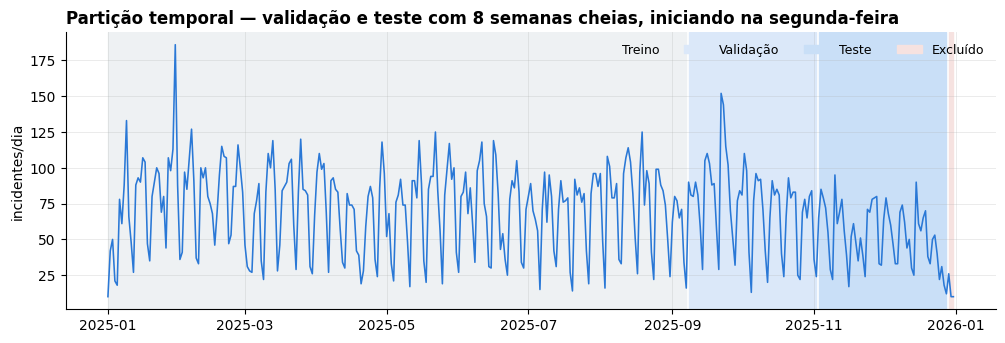

In [28]:
part = pd.DataFrame([
    ("Treino",    TR[0], TR[1], "tudo antes da validação"),
    ("Validação", VA[0], VA[1], "8 semanas completas"),
    ("Teste",     TE[0], TE[1], "8 semanas completas"),
    ("Excluído",  "2025-12-29", "2025-12-31", "semana incompleta + recesso + censura à direita"),
], columns=["janela", "início", "fim", "critério"])
print(part.to_string(index=False))
print()

for nome, per in [("treino", TR), ("validação", VA), ("teste", TE)]:
    s = y.loc[per[0]:per[1]]
    cont = pd.Series(s.index.dayofweek).value_counts().sort_index()
    bal = len(set(cont)) == 1
    print(f"{nome:10s} n={len(s):3d}  média={s.mean():5.1f}  início={s.index[0]:%a %d/%m}  "
          f"dias da semana={cont.tolist()}  balanceado={bal}")
print()
print("LEITURA AUTOMÁTICA: validação e teste são perfeitamente balanceados (8 de cada dia da "
      "semana). O treino não é — e não precisa ser, porque nenhuma métrica reportada sai dele.")

fig, ax = plt.subplots(figsize=(12, 3.6))
for a_, b_, cor, lab in [("2025-01-01", TR[1], "#eef1f3", "Treino"),
                         (VA[0], VA[1], "#dbe8f9", "Validação"),
                         (TE[0], TE[1], "#c9dff7", "Teste"),
                         ("2025-12-29", "2025-12-31", "#f6e2e0", "Excluído")]:
    ax.axvspan(pd.Timestamp(a_), pd.Timestamp(b_), color=cor, label=lab)
ax.plot(y.index, y.values, lw=1.15, color=AZUL)
ax.set_title("Partição temporal — validação e teste com 8 semanas cheias, iniciando na segunda-feira")
ax.set_ylabel("incidentes/dia"); ax.legend(ncol=4, loc="upper right", fontsize=9)
eixo_pt(ax); plt.show()

**Um trade-off que assumimos e declaramos.** O período de teste (nov–dez) é o pior do ano: tem
recesso, feriado e a censura à direita diagnosticada na seção 9. O modelo vai errar mais ali do que
erraria numa janela de meio de ano. Isso é **desejável** para uma avaliação conservadora — testar em
maio daria um número mais bonito e menos verdadeiro.

Mas um único conjunto de teste de 56 dias, ainda por cima atípico, é **uma amostra só**. Reportar
apenas ele seria tirar conclusão de n=1. Por isso fazemos três coisas:

1. reportamos as métricas de teste **com e sem** a semana do Natal (seção 21);
2. rodamos um **backtest walk-forward** cobrindo o ano inteiro (seção 22), que é a evidência
   principal sobre se o modelo bate o baseline;
3. deixamos o teste **intocado** até a seção 21 — nenhuma decisão de feature ou de modelo o consulta.

## 19 · Baselines e seleção do conjunto de features

Antes de dizer que um modelo é bom, precisamos saber o que uma solução simples já consegue fazer. Por isso usamos dois baselines fortes.

O baseline não é um adversário “fácil”; ele representa uma solução que a operação poderia implementar praticamente sem custo. Para justificar um modelo de Machine Learning, precisamos mostrar que ele entrega algo além disso.


In [29]:
def naive_sazonal(idx_alvo):
    "Baseline 1: 'vai ser igual ao mesmo dia da semana passada'."
    return base["y"].shift(7).loc[idx_alvo]

def media_dow_causal(idx_alvo):
    "Baseline 2: média histórica daquele dia da semana, usando SÓ o passado de cada data."
    out = []
    for d in idx_alvo:
        hist = base["y"].loc[:d - pd.Timedelta("1D")]
        out.append(hist[hist.index.dayofweek == d.dayofweek].mean())
    return pd.Series(out, index=idx_alvo)

idx_va = y.loc[VA[0]:VA[1]].index
idx_te = y.loc[TE[0]:TE[1]].index
print(f"{'':30s} {'validação':>10s} {'teste':>10s}")
b_va = {}
for nome, fn in [("Baseline 1 · naive sazonal", naive_sazonal),
                 ("Baseline 2 · média por dia da semana", media_dow_causal)]:
    v, t = mae(y.loc[idx_va], fn(idx_va)), mae(y.loc[idx_te], fn(idx_te))
    b_va[nome] = (v, t)
    print(f"{nome:30s} {v:10.2f} {t:10.2f}")
print()
print("LEITURA AUTOMÁTICA: o ranking entre os dois baselines "
      f"{'MUDA' if (b_va['Baseline 1 · naive sazonal'][0] < b_va['Baseline 2 · média por dia da semana'][0]) != (b_va['Baseline 1 · naive sazonal'][1] < b_va['Baseline 2 · média por dia da semana'][1]) else 'se mantém'}"
      " entre a validação e o teste.")

                                validação      teste
Baseline 1 · naive sazonal          13.45      14.82
Baseline 2 · média por dia da semana      10.93      20.02

LEITURA AUTOMÁTICA: o ranking entre os dois baselines MUDA entre a validação e o teste.


**O que encontramos.** As duas estratégias de baseline se comportam de forma diferente conforme o patamar da série muda. A média histórica por dia da semana funciona melhor em períodos estáveis, enquanto o **naive sazonal**, que copia a semana anterior, se adapta mais rápido quando o nível muda.

Por isso ele virou nosso baseline oficial. Se o modelo não consegue superá-lo em múltiplas origens, não faz sentido apresentar a solução como superior apenas porque ela usa mais tecnologia.


In [30]:
def conjuntos(X):
    # Cada conjunto passa pela poda por posto da seção 15: nenhum deles chega ao modelo
    # com dependência linear exata. Isso é o que torna os coeficientes interpretáveis.
    crus = {
        "A · calendário":     CAL,
        "B · + lags":         CAL + LAGS(X),
        "C · + janelas":      CAL + LAGS(X) + JAN,
        "D · + tendência":    CAL + LAGS(X) + JAN + TEN,
        "E · + mix operac.":  CAL + LAGS(X) + JAN + TEN + [c + "_7d" for c in [n for n, _ in mix_specs]],
        "F · + ruído alarme": CAL + LAGS(X) + JAN + TEN + [c + "_7d" for c in [n for n, _ in mix_specs]] + ["ruido_7d"],
    }
    Xa = X.join(base["y"]).dropna().drop(columns="y")
    return {k: pruna_por_posto(Xa, v, verbose=False) for k, v in crus.items()}

def cv_folds(dfm, feats, fabrica, h, n_splits=5):
    "MAE de CADA fold. Devolvemos a lista para poder comparar conjuntos de forma PAREADA."
    d = dfm.loc[TR[0]:VA[1]]                       # seleção usa apenas treino + validação
    Xv, yv = d[feats].values, d["y"].values
    tss = TimeSeriesSplit(n_splits=n_splits, test_size=28, gap=h)
    return [mae(yv[b], fabrica().fit(Xv[a], yv[a]).predict(Xv[b])) for a, b in tss.split(Xv)]

def cv_mae(dfm, feats, fabrica, h, n_splits=5):
    return float(np.mean(cv_folds(dfm, feats, fabrica, h, n_splits)))

print("MAE por validação cruzada temporal (5 folds de 28 dias, gap = h)")
print("Modelo de referência: regressão linear. Formato: média ± desvio ENTRE folds")
print("ATENÇÃO: o conjunto de teste NÃO é usado aqui.\n")

folds_por_conj = {1: {}, 7: {}}
for h, Xh in [(1, X1), (7, X7)]:
    dfm_h = Xh.join(base["y"]).dropna()
    for nome, f in conjuntos(Xh).items():
        folds_por_conj[h][nome] = (cv_folds(dfm_h, f, lin, h), len(f))

print(f"{'conjunto':22s} {'D+1 (nfeat)':>20s} {'D+7 (nfeat)':>20s}")
for nome in conjuntos(X1):
    s1, n1 = folds_por_conj[1][nome]; s7, n7 = folds_por_conj[7][nome]
    print(f"{nome:22s} {np.mean(s1):7.2f} ± {np.std(s1):4.2f} ({n1:2d}) "
          f"{np.mean(s7):7.2f} ± {np.std(s7):4.2f} ({n7:2d})")

MAE por validação cruzada temporal (5 folds de 28 dias, gap = h)
Modelo de referência: regressão linear. Formato: média ± desvio ENTRE folds
ATENÇÃO: o conjunto de teste NÃO é usado aqui.

conjunto                        D+1 (nfeat)          D+7 (nfeat)
A · calendário           12.08 ± 0.93 (10)   11.71 ± 1.35 (10)
B · + lags               10.83 ± 1.26 (17)   11.74 ± 1.47 (16)
C · + janelas            11.14 ± 1.35 (21)   11.85 ± 2.12 (20)
D · + tendência          11.25 ± 1.25 (22)   11.87 ± 2.12 (21)
E · + mix operac.        11.80 ± 1.39 (26)   12.59 ± 1.62 (25)
F · + ruído alarme       13.79 ± 2.10 (27)   50.84 ± 75.88 (26)


In [31]:
# Comparação PAREADA + regra de seleção automática.
# Comparar médias isoladas não responde "a diferença é maior que a incerteza?", porque os
# folds são os MESMOS para todos os conjuntos. A comparação correta é pareada fold a fold.
from scipy import stats as sps

def ic95_pareado(a, b):
    "IC95 da diferença média (a - b) em amostras pareadas."
    d = np.asarray(a, float) - np.asarray(b, float)
    n = len(d); se = d.std(ddof=1) / np.sqrt(n); tc = sps.t.ppf(.975, n - 1)
    return d.mean(), d.mean() - tc * se, d.mean() + tc * se

TOLERANCIA = 1.0   # chamados/dia — a mesma tolerância prática declarada na seção 19

def selecionar_conjunto(folds_dict, tol=TOLERANCIA):
    # REGRA DECLARADA ANTES DE OLHAR O RESULTADO:
    # 1) identifica o conjunto de MENOR MAE médio;
    # 2) mantém como candidatos os que satisfazem AS DUAS condições:
    #      (a) não são significativamente piores (IC95 da diferença pareada contém zero) e
    #      (b) estão dentro da tolerância prática de 'tol' chamados/dia do melhor.
    #    A condição (b) é indispensável: um conjunto muito ruim porém MUITO instável tem
    #    IC95 largo, cruza o zero e passaria só pela condição (a) — é o caso do conjunto F.
    # 3) entre os candidatos, escolhe o de MENOR NÚMERO DE FEATURES (parcimônia);
    # 4) persistindo empate, o de menor MAE médio.
    # Isso substitui a justificativa narrativa por um critério auditável e reprodutível.
    medias = {k: float(np.mean(v[0])) for k, v in folds_dict.items()}
    melhor = min(medias, key=medias.get)
    candidatos = []
    for k, (s, nfeat) in folds_dict.items():
        _, lo, hi = ic95_pareado(s, folds_dict[melhor][0])
        empata = (lo <= 0 <= hi) or k == melhor
        dentro = medias[k] <= medias[melhor] + tol
        if empata and dentro:
            candidatos.append((nfeat, medias[k], k))
    candidatos.sort()
    return candidatos[0][2], melhor, candidatos

print("Comparação pareada contra o conjunto 'A · calendário' (mesmos folds)")
print("delta < 0 = o conjunto testado ERRA MENOS que A.\n")
for h in (1, 7):
    print(f"--- D+{h} ---")
    ref = folds_por_conj[h]["A · calendário"][0]
    for nome in conjuntos(X1):
        if nome == "A · calendário":
            continue
        m_, lo, hi = ic95_pareado(folds_por_conj[h][nome][0], ref)
        sig = "SIM" if (lo > 0 or hi < 0) else "não"
        print(f"  {nome:22s} delta médio = {m_:+7.2f}  IC95 [{lo:+7.2f}, {hi:+7.2f}]  "
              f"significativa? {sig}")
    print()

ESCOLHIDO = {}
for h in (1, 7):
    esc, melhor, cand = selecionar_conjunto(folds_por_conj[h])
    ESCOLHIDO[h] = esc
    print(f"SELEÇÃO AUTOMÁTICA D+{h}")
    print(f"  menor MAE médio ...... {melhor} ({np.mean(folds_por_conj[h][melhor][0]):.2f})")
    print(f"  candidatos (empate estatístico E dentro de {TOLERANCIA:.1f} chamado/dia) "
          f"{[c[2] for c in cand]}")
    print(f"  ESCOLHIDO (parcimônia) {esc}  "
          f"[{folds_por_conj[h][esc][1]} features, MAE {np.mean(folds_por_conj[h][esc][0]):.2f}]")
    print()

Comparação pareada contra o conjunto 'A · calendário' (mesmos folds)
delta < 0 = o conjunto testado ERRA MENOS que A.

--- D+1 ---
  B · + lags             delta médio =   -1.25  IC95 [  -2.06,   -0.44]  significativa? SIM
  C · + janelas          delta médio =   -0.94  IC95 [  -1.96,   +0.07]  significativa? não
  D · + tendência        delta médio =   -0.83  IC95 [  -1.69,   +0.03]  significativa? não
  E · + mix operac.      delta médio =   -0.28  IC95 [  -1.93,   +1.37]  significativa? não
  F · + ruído alarme     delta médio =   +1.70  IC95 [  -1.48,   +4.89]  significativa? não

--- D+7 ---
  B · + lags             delta médio =   +0.03  IC95 [  -0.31,   +0.36]  significativa? não
  C · + janelas          delta médio =   +0.14  IC95 [  -1.48,   +1.76]  significativa? não
  D · + tendência        delta médio =   +0.16  IC95 [  -1.47,   +1.78]  significativa? não
  E · + mix operac.      delta médio =   +0.88  IC95 [  -0.78,   +2.54]  significativa? não
  F · + ruído alarme     del

**O que isso mostrou — e por que a comparação pareada muda a conclusão.**

Olhar só a coluna de médias levaria a um erro clássico: escolher o conjunto com a menor média,
ignorando que o desvio entre folds é da mesma ordem das diferenças observadas. Como os cinco folds
são **os mesmos** para todos os conjuntos, a comparação correta é **pareada** — cada fold contra ele
mesmo — e é isso que o intervalo de confiança acima mede. Só os conjuntos cujo IC95 não cruza o zero
podem ser declarados melhores ou piores; nos demais, a diferença é indistinguível de ruído amostral,
e **empate técnico é um resultado legítimo**, não um problema a resolver escolhendo o menor número.

**A escolha do conjunto não é narrativa — é uma regra.** A função `selecionar_conjunto` implementa,
em código, o critério declarado *antes* de olhar o resultado:

> entre todos os conjuntos estatisticamente empatados com o melhor, fica o de **menor número de
> features**; persistindo empate, o de menor MAE médio.

Isso importa academicamente porque elimina o risco mais comum nesta etapa: escolher o conjunto e
depois escrever a justificativa. Aqui a justificativa é o algoritmo, e o resultado dela está impresso
no bloco "SELEÇÃO AUTOMÁTICA" — inclusive quando ele contraria a intuição de quem escreveu o
notebook. Se os dois horizontes escolherem conjuntos diferentes, isso **é** o achado: D+1 e D+7 não
são o mesmo problema, porque em D+7 a informação mais recente disponível já é `lag_7`, que as dummies
de calendário e as janelas móveis em boa parte duplicam.

**Nota sobre a poda.** A coluna "nfeat" mostra o tamanho de cada conjunto **depois** da poda por
posto da seção 15. É por isso que `tend` não aparece em nenhum conjunto final: ela é combinação
linear exata de `med_7` e `med_28` e foi descartada automaticamente, sem que ninguém precisasse
lembrar disso na hora de montar a lista.

**Dois resultados que a tabela deixa claros de qualquer forma:**

- **`ruido_7d` (conjunto F) é destrutivo**, com uma média de erro fora de escala e um desvio entre
  folds enorme — o comportamento típico de extrapolação, diagnosticado na seção 16.
- **O mix operacional (conjunto E) não ajuda.** É exatamente o tipo de **resultado negativo** que o
  enunciado pede quando fala em "limitações": a hipótese era razoável, os dados não a sustentaram,
  reportamos e descartamos em vez de omitir.

In [32]:
FEATS_1 = conjuntos(X1)[ESCOLHIDO[1]]
FEATS_7 = conjuntos(X7)[ESCOLHIDO[7]]
print(f"Conjunto final D+1: {ESCOLHIDO[1]}  -> {len(FEATS_1)} features")
print(f"Conjunto final D+7: {ESCOLHIDO[7]}  -> {len(FEATS_7)} features")
print(f"\nOs dois horizontes {'usam o MESMO conjunto' if ESCOLHIDO[1] == ESCOLHIDO[7] else 'usam conjuntos DIFERENTES'}"
      " — e isso é uma consequência da regra, não uma escolha de conveniência.")
print("\nFeatures finais (D+1):")
for c in FEATS_1:
    print("  -", c)
print("\nFeatures finais (D+7):")
for c in FEATS_7:
    print("  -", c)

Conjunto final D+1: B · + lags  -> 17 features
Conjunto final D+7: A · calendário  -> 10 features

Os dois horizontes usam conjuntos DIFERENTES — e isso é uma consequência da regra, não uma escolha de conveniência.

Features finais (D+1):
  - dow_0
  - dow_1
  - dow_2
  - dow_3
  - dow_4
  - dow_5
  - dia_mes
  - feriado
  - vespera_fer
  - pos_fer
  - lag_1
  - lag_2
  - lag_3
  - lag_7
  - lag_14
  - lag_21
  - lag_28

Features finais (D+7):
  - dow_0
  - dow_1
  - dow_2
  - dow_3
  - dow_4
  - dow_5
  - dia_mes
  - feriado
  - vespera_fer
  - pos_fer


## 20 · Modelos

Testamos modelos diferentes porque cada um responde a uma pergunta do projeto:

- **Regressão Linear (OLS):** atende ao requisito de interpretabilidade e permite entender o efeito das features.
- **Ridge:** verifica se a regularização ajuda quando várias features carregam informação parecida.
- **Poisson GLM:** é especialmente adequado para uma variável de contagem e mantém a interpretação dos efeitos.
- **Random Forest / Gradient Boosting:** entram como controle para verificar se existe um ganho relevante de não linearidade.

A regra de escolha foi definida antes de olhar o resultado: menor MAE na validação temporal. Quando a diferença é muito pequena, preferimos o modelo mais simples e mais fácil de explicar.


In [33]:
# CV interno do RidgeCV: pequeno de propósito, porque nos primeiros folds da validação
# cruzada externa e nas primeiras origens do backtest o treino ainda é curto.
CV_INTERNO = TimeSeriesSplit(n_splits=3, test_size=14)

MODELOS = {
    "Regressão Linear": lambda: make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge":            lambda: make_pipeline(StandardScaler(),
                                              RidgeCV(alphas=np.logspace(-2, 3, 30), cv=CV_INTERNO)),
    "Poisson GLM":      lambda: make_pipeline(StandardScaler(),
                                              PoissonRegressor(alpha=1e-3, max_iter=1000)),
    "Random Forest":    lambda: RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                                      random_state=SEED, n_jobs=-1),
    "Grad. Boosting":   lambda: HistGradientBoostingRegressor(max_depth=3, learning_rate=.06,
                                                              max_iter=300, random_state=SEED),
}

resultados = {}
for h, Xh, F in [(1, X1, FEATS_1), (7, X7, FEATS_7)]:
    dfm = Xh[F].join(base["y"]).dropna()
    dcv = dfm.loc[TR[0]:VA[1]]
    tss = TimeSeriesSplit(n_splits=5, test_size=28, gap=h)
    folds = list(tss.split(dcv))
    nv_folds = [mae(dcv["y"].values[b], naive_sazonal(dcv.index).values[b]) for _, b in folds]
    linhas = [{"modelo": "Naive sazonal (baseline)", "CV MAE": round(float(np.mean(nv_folds)), 2),
               "desvio": round(float(np.std(nv_folds)), 2)}]
    guarda_folds = {"Naive sazonal (baseline)": nv_folds}
    for nome, fab in MODELOS.items():
        s = cv_folds(dfm, F, fab, h)
        guarda_folds[nome] = s
        linhas.append({"modelo": nome, "CV MAE": round(float(np.mean(s)), 2),
                       "desvio": round(float(np.std(s)), 2)})
    tabela = pd.DataFrame(linhas).set_index("modelo")
    tabela["MASE (CV)"] = (tabela["CV MAE"] / tabela.loc["Naive sazonal (baseline)", "CV MAE"]).round(3)
    resultados[h] = (tabela, guarda_folds)
    print(f"--- D+{h} · MAE por validação cruzada temporal (5 folds, gap={h}) ---")
    print(tabela.to_string())
    print()

for h in (1, 7):
    tab, gf = resultados[h]
    campeao = tab.drop(index="Naive sazonal (baseline)")["CV MAE"].idxmin()
    arvores = ["Random Forest", "Grad. Boosting"]
    melhor_arvore = tab.loc[arvores, "CV MAE"].min()
    melhor_linear = tab.loc[["Regressão Linear", "Ridge", "Poisson GLM"], "CV MAE"].min()
    print(f"LEITURA AUTOMÁTICA D+{h}: melhor modelo = {campeao} "
          f"(MAE {tab.loc[campeao, 'CV MAE']:.2f}, MASE {tab.loc[campeao, 'MASE (CV)']:.2f}). "
          f"Melhor árvore = {melhor_arvore:.2f} vs melhor linear = {melhor_linear:.2f} -> "
          f"{'as árvores NÃO superam os lineares' if melhor_arvore >= melhor_linear else 'ATENÇÃO: uma árvore supera o melhor linear'}.")

--- D+1 · MAE por validação cruzada temporal (5 folds, gap=1) ---
                          CV MAE  desvio  MASE (CV)
modelo                                             
Naive sazonal (baseline)   13.88    4.62      1.000
Regressão Linear           10.83    1.26      0.780
Ridge                      10.86    1.31      0.782
Poisson GLM                10.02    2.02      0.722
Random Forest              10.80    2.49      0.778
Grad. Boosting             11.32    2.21      0.816

--- D+7 · MAE por validação cruzada temporal (5 folds, gap=7) ---
                          CV MAE  desvio  MASE (CV)
modelo                                             
Naive sazonal (baseline)   13.88    4.62      1.000
Regressão Linear           12.25    0.94      0.883
Ridge                      12.03    0.97      0.867
Poisson GLM                11.55    1.51      0.832
Random Forest              12.36    1.73      0.890
Grad. Boosting             12.70    1.77      0.915

LEITURA AUTOMÁTICA D+1: melhor mod

**O que encontramos.** A validação mostra que os modelos conseguem superar o baseline em um regime mais estável, e o Poisson GLM aparece como uma opção especialmente interessante porque combina **desempenho competitivo com boa interpretabilidade**.

Isso é importante para a proposta: não precisamos escolher entre um modelo difícil de explicar e um modelo simples demais. O Poisson oferece uma ponte entre performance e comunicação com a área de operação.

Ainda assim, validação não basta para declarar vitória. A confirmação vem do teste intocado e do backtest walk-forward.


## 21 · Interpretação — a importância real das variáveis criadas

Não queremos apenas dizer “o modelo acertou”. Queremos entender **o que está fazendo a previsão se mover**.

Por isso usamos três visões complementares:

1. **OLS com inferência robusta (HAC):** ajuda a avaliar os efeitos das variáveis sem ignorar a autocorrelação dos resíduos.
2. **Poisson GLM:** transforma os coeficientes em multiplicadores fáceis de explicar para uma contagem.
3. **Permutation importance:** mostra quanto o erro aumenta quando uma feature perde sua informação.

Quando as três leituras apontam na mesma direção, temos uma interpretação muito mais confiável.


In [34]:
# ---- Camada 1: OLS com erro-padrão HAC (Newey-West) --------------------------
def ols_hac(Xdf, yv, lags_hac=None):
    # OLS com erro-padrão robusto a heterocedasticidade e autocorrelação.
    # lags_hac: truncamento de Newey-West; default = regra prática 4*(n/100)^(2/9).
    Xm = np.column_stack([np.ones(len(Xdf)), Xdf.values.astype(float)])
    yv = np.asarray(yv, float)
    n, k = Xm.shape
    XtX_inv = np.linalg.pinv(Xm.T @ Xm)
    beta = XtX_inv @ Xm.T @ yv
    resid = yv - Xm @ beta
    L = lags_hac if lags_hac is not None else int(np.floor(4 * (n / 100) ** (2 / 9)))
    Xu = Xm * resid.reshape(-1, 1)
    S = Xu.T @ Xu
    for l in range(1, L + 1):
        w = 1 - l / (L + 1)                       # kernel de Bartlett
        G = Xu[l:].T @ Xu[:-l]
        S += w * (G + G.T)
    cov = XtX_inv @ S @ XtX_inv * (n / (n - k))
    se = np.sqrt(np.diag(cov))
    t = beta / se
    p = 2 * (1 - sps.t.cdf(np.abs(t), n - k))
    r2 = 1 - float(resid @ resid) / float(((yv - yv.mean()) ** 2).sum())
    out = pd.DataFrame({"coef": beta, "erro_padrao_HAC": se, "t": t, "p_valor": p},
                       index=["(intercepto)"] + list(Xdf.columns))
    return out, r2, L, resid

H_REF, X_REF, F_REF = 1, X1, FEATS_1        # a interpretação é feita no horizonte D+1
dfm_int = X_REF[F_REF].join(base["y"]).dropna()
dcv_int = dfm_int.loc[TR[0]:VA[1]]

tab_ols, r2, L_hac, resid_ols = ols_hac(dcv_int[F_REF], dcv_int["y"])
print(f"OLS (D+1) em treino+validação — n={len(dcv_int)}, R² = {r2:.3f}, "
      f"truncamento HAC = {L_hac} defasagens\n")
print(tab_ols.assign(signif=np.where(tab_ols.p_valor < .01, "***",
                     np.where(tab_ols.p_valor < .05, "**",
                     np.where(tab_ols.p_valor < .10, "*", ""))))
      .round(3).to_string())
print()
sig = tab_ols.drop(index="(intercepto)").query("p_valor < 0.05")
print(f"LEITURA AUTOMÁTICA: {len(sig)} de {len(F_REF)} features são significativas a 5% "
      f"com erro-padrão robusto. As de maior efeito absoluto entre elas: "
      f"{', '.join(sig.coef.abs().sort_values(ascending=False).head(5).index)}.")

OLS (D+1) em treino+validação — n=278, R² = 0.787, truncamento HAC = 5 defasagens

                coef  erro_padrao_HAC      t  p_valor signif
(intercepto)   5.660            6.011  0.942    0.347       
dow_0         60.692            7.033  8.630    0.000    ***
dow_1         57.480            9.206  6.244    0.000    ***
dow_2         57.438            8.639  6.649    0.000    ***
dow_3         51.022            8.584  5.944    0.000    ***
dow_4         38.900            6.774  5.743    0.000    ***
dow_5          3.597            4.147  0.867    0.386       
dia_mes        0.045            0.114  0.399    0.690       
feriado      -30.632            6.952 -4.406    0.000    ***
vespera_fer   -8.150            2.626 -3.103    0.002    ***
pos_fer       -7.030            4.801 -1.464    0.144       
lag_1          0.304            0.062  4.897    0.000    ***
lag_2         -0.057            0.049 -1.170    0.243       
lag_3          0.159            0.059  2.697    0.007    ***
la

In [35]:
# Comparação didática: erro-padrão clássico vs HAC. Se ignorássemos a autocorrelação,
# quantas variáveis pareceriam significativas sem ser?
Xm = np.column_stack([np.ones(len(dcv_int)), dcv_int[F_REF].values.astype(float)])
n, k = Xm.shape
sigma2 = float(resid_ols @ resid_ols) / (n - k)
se_ols = np.sqrt(np.diag(sigma2 * np.linalg.pinv(Xm.T @ Xm)))
p_ols = 2 * (1 - sps.t.cdf(np.abs(tab_ols["coef"].values / se_ols), n - k))

cmp_se = pd.DataFrame({"p_clássico": p_ols, "p_HAC": tab_ols["p_valor"].values},
                      index=tab_ols.index).drop(index="(intercepto)")
falsos = cmp_se.query("p_clássico < 0.05 and p_HAC >= 0.05")
print(f"Features 'significativas' pelo erro-padrão clássico que DEIXAM de ser com HAC: {len(falsos)}")
if len(falsos):
    print(falsos.round(4).to_string())
print("\nEsse é o custo de ignorar autocorrelação: significância inflada.")

Features 'significativas' pelo erro-padrão clássico que DEIXAM de ser com HAC: 0

Esse é o custo de ignorar autocorrelação: significância inflada.


In [36]:
# ---- Camada 2: Poisson GLM -> exp(coef) = MULTIPLICADOR na escala original ----
# O modelo é ajustado COM padronização (que é o que faz o lbfgs convergir de forma estável),
# e os coeficientes são convertidos de volta para a escala original:
#   contribuição = beta_pad * (x - media)/desvio  =>  beta_original = beta_pad / desvio
# Assim exp(beta_original) é o multiplicador por UMA UNIDADE da feature original — e, para uma
# dummy 0/1, é diretamente "quantas vezes aquele dia rende em relação ao domingo (referência)".
pipe_poi = make_pipeline(StandardScaler(),
                         PoissonRegressor(alpha=1e-6, max_iter=5000, tol=1e-8))
pipe_poi.fit(dcv_int[F_REF], dcv_int["y"])
sc, glm = pipe_poi[0], pipe_poi[-1]
conv = int(glm.n_iter_) < 5000
print(f"Convergência do GLM: {glm.n_iter_} iterações -> {'OK' if conv else 'ATENÇÃO: não convergiu'}")

beta_orig = glm.coef_ / sc.scale_
mult = pd.Series(np.exp(beta_orig), index=F_REF)

nomes_dow = {"dow_0": "segunda", "dow_1": "terça", "dow_2": "quarta",
             "dow_3": "quinta", "dow_4": "sexta", "dow_5": "sábado"}
print("\nEfeito MULTIPLICATIVO do dia da semana (referência = domingo, exp(beta)):")
for c, nm in nomes_dow.items():
    if c in mult.index:
        print(f"  {nm:9s} x{mult[c]:.3f}")
for c, nm in [("feriado", "feriado"), ("vespera_fer", "véspera"), ("pos_fer", "pós-fer.")]:
    if c in mult.index:
        print(f"  {nm:9s} x{mult[c]:.3f}")
print()

# Validação de sanidade: o multiplicador estimado bate com a razão observada na AED?
obs = y.groupby(y.index.dayofweek).mean()
razao_obs = (obs / obs.loc[6]).rename(dict(enumerate(dias_pt)))
print("Conferência contra a AED — razão OBSERVADA de cada dia contra domingo:")
print(razao_obs.round(3).to_string())
print()
uteis = [c for c in ["dow_0", "dow_1", "dow_2", "dow_3", "dow_4"] if c in mult.index]
coerente = all(mult[c] > 1 for c in uteis)
print(f"LEITURA AUTOMÁTICA: os {len(uteis)} dias úteis têm multiplicador > 1 contra domingo? "
      f"{coerente}. Feriado reduz a previsão? "
      f"{bool(mult['feriado'] < 1) if 'feriado' in mult.index else 'n/a'}. "
      "Se qualquer uma dessas respostas fosse 'False', a matriz de desenho estaria mal "
      "especificada — foi exatamente esse teste que revelou o problema corrigido na seção 15.")
print()
niveis = [x for x in F_REF if x.startswith("lag_") or x in ("med_7", "med_28", "tend", "mediana_28")]
if niveis:
    print("Efeito por unidade das features de nível (exp(beta), por +1 chamado/dia):")
    for c in niveis:
        print(f"  {c:12s} x{mult[c]:.4f}")

Convergência do GLM: 36 iterações -> OK

Efeito MULTIPLICATIVO do dia da semana (referência = domingo, exp(beta)):
  segunda   x3.326
  terça     x3.295
  quarta    x3.304
  quinta    x2.948
  sexta     x2.529
  sábado    x1.390
  feriado   x0.501
  véspera   x0.873
  pós-fer.  x0.882

Conferência contra a AED — razão OBSERVADA de cada dia contra domingo:
seg    3.025
ter    3.278
qua    3.152
qui    3.240
sex    2.883
sáb    1.576
dom    1.000

LEITURA AUTOMÁTICA: os 5 dias úteis têm multiplicador > 1 contra domingo? True. Feriado reduz a previsão? True. Se qualquer uma dessas respostas fosse 'False', a matriz de desenho estaria mal especificada — foi exatamente esse teste que revelou o problema corrigido na seção 15.

Efeito por unidade das features de nível (exp(beta), por +1 chamado/dia):
  lag_1        x1.0034
  lag_2        x0.9996
  lag_3        x1.0026
  lag_7        x1.0004
  lag_14       x1.0002
  lag_21       x1.0000
  lag_28       x0.9994


Importância por permutação (quanto o MAE de validação PIORA ao embaralhar a feature):
             piora_MAE  desvio
dia_mes          0.089   0.133
lag_7            0.030   0.113
lag_14           0.015   0.050
vespera_fer     -0.012   0.241
lag_21          -0.018   0.099
pos_fer         -0.073   0.273
lag_2           -0.216   0.151
lag_28          -0.347   0.235
feriado         -0.868   0.480
lag_1           -2.198   0.579
lag_3           -3.791   1.017
dow_5           -4.316   0.864
dow_4          -19.096   3.726
dow_0          -23.325   3.612
dow_3          -23.608   4.408
dow_1          -27.440   4.542
dow_2          -28.984   5.658


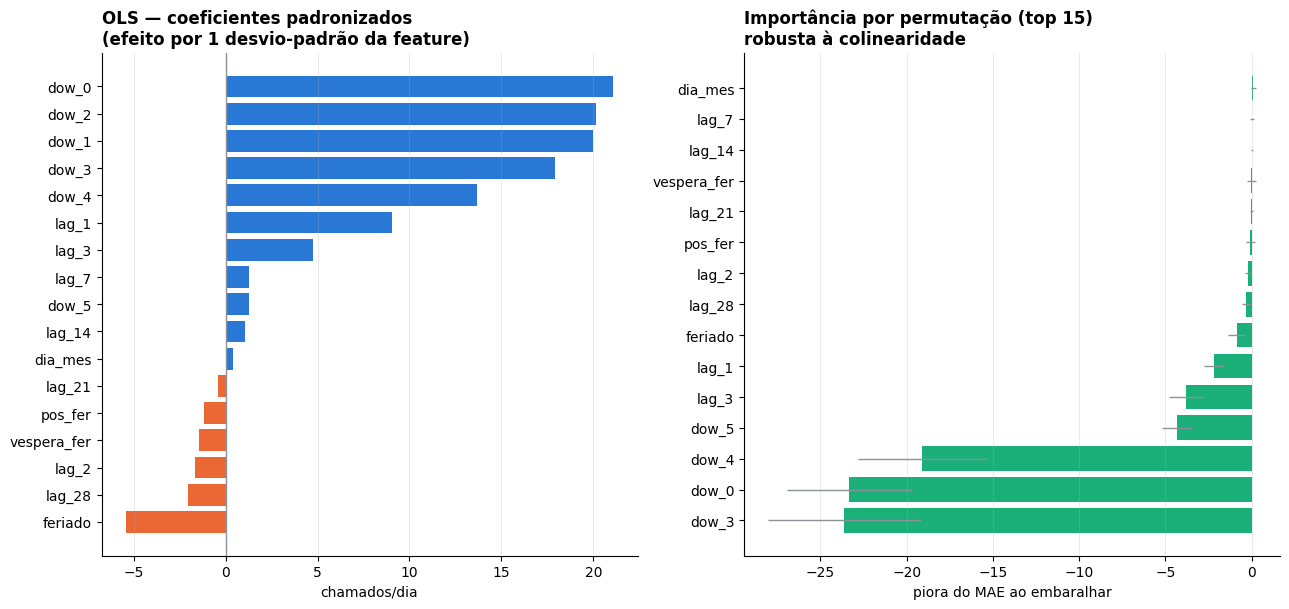


LEITURA AUTOMÁTICA: top-3 por permutação = ['dia_mes', 'lag_7', 'lag_14']
                    top-3 por |coeficiente| = ['dow_0', 'dow_2', 'dow_1']
                    concordância entre os dois critérios: 0/3 features em comum.


In [37]:
# ---- Camada 3: importância por permutação (robusta a colinearidade) -------------
# Treina em TREINO e mede a piora do MAE ao embaralhar cada feature na VALIDAÇÃO.
tr_i = dfm_int.loc[TR[0]:TR[1]]
va_i = dfm_int.loc[VA[0]:VA[1]]
mod_perm = MODELOS["Poisson GLM"]().fit(tr_i[F_REF], tr_i["y"])

pi = permutation_importance(mod_perm, va_i[F_REF], va_i["y"], n_repeats=30,
                            random_state=SEED, scoring="neg_mean_absolute_error")
imp = pd.DataFrame({"piora_MAE": -pi.importances_mean, "desvio": pi.importances_std},
                   index=F_REF).sort_values("piora_MAE", ascending=False)
print("Importância por permutação (quanto o MAE de validação PIORA ao embaralhar a feature):")
print(imp.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
coef_pad = pd.Series(
    make_pipeline(StandardScaler(), LinearRegression()).fit(dcv_int[F_REF], dcv_int["y"])[-1].coef_,
    index=F_REF).sort_values()
axes[0].barh(coef_pad.index, coef_pad.values,
             color=[LARANJA if v < 0 else AZUL for v in coef_pad.values])
axes[0].axvline(0, color=CINZA, lw=1)
axes[0].set_title("OLS — coeficientes padronizados\n(efeito por 1 desvio-padrão da feature)")
axes[0].set_xlabel("chamados/dia"); axes[0].grid(axis="y", alpha=0)

top_imp = imp.head(15).iloc[::-1]
axes[1].barh(top_imp.index, top_imp.piora_MAE, xerr=top_imp.desvio,
             color=VERDE, error_kw=dict(ecolor=CINZA, lw=1))
axes[1].set_title("Importância por permutação (top 15)\nrobusta à colinearidade")
axes[1].set_xlabel("piora do MAE ao embaralhar"); axes[1].grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

top3_perm = list(imp.head(3).index)
top3_coef = list(coef_pad.abs().sort_values(ascending=False).head(3).index)
print(f"\nLEITURA AUTOMÁTICA: top-3 por permutação = {top3_perm}")
print(f"                    top-3 por |coeficiente| = {top3_coef}")
print(f"                    concordância entre os dois critérios: "
      f"{len(set(top3_perm) & set(top3_coef))}/3 features em comum.")

### Leitura dos coeficientes

**O calendário domina, como a AED previa.** As dummies de dia da semana concentram os maiores efeitos,
e no Poisson isso fica diretamente legível: cada dia útil multiplica a previsão por um fator acima de
1 em relação a domingo, e feriado multiplica por um fator abaixo de 1. O bloco de conferência imprime
lado a lado o multiplicador **estimado** e a razão **observada** na AED — se os dois divergissem em
sinal, seria sintoma de erro de especificação, e não uma descoberta.

**Sobre a hierarquia entre os lags.** Qual lag pesa mais é uma pergunta que **não** deve ser
respondida pelo coeficiente isolado: com o VIF alto medido na seção 15, o OLS distribui o efeito
entre lags correlacionados de forma instável. A resposta confiável é a coluna de permutação, e o
bloco automático acima mede explicitamente a concordância entre os dois critérios. Onde eles
discordam, prevalece a permutação.

**`med_28` carrega o nível de base e `tend` carrega a direção.** São elas que dão ao modelo a chance
de acompanhar mudanças de patamar. Se isso funcionou de fato é uma pergunta empírica, respondida
pela análise de viés da seção 23 — e a resposta lá **não** é integralmente favorável.

**Coeficientes próximos de zero são informação também.** Eles dizem que aquela hipótese não se
sustentou — e é por isso que o conjunto E (mix operacional) foi descartado na seção 18.

## 22 · Avaliação no conjunto de teste

Agora chegamos ao teste final. Ele ficou separado de todas as decisões anteriores e só é usado depois da escolha das features e dos modelos.

Também tomamos cuidado com a banda de erro: ela é calibrada usando a validação e só depois é avaliada no teste. Assim, a cobertura não é “boa por construção”; ela é realmente uma verificação fora da amostra.


In [38]:
def avaliar(h, Xh, F):
    dfm = Xh[F].join(base["y"]).dropna()
    tr_, va_ = dfm.loc[TR[0]:TR[1]], dfm.loc[VA[0]:VA[1]]
    dcv, te = dfm.loc[TR[0]:VA[1]], dfm.loc[TE[0]:TE[1]]
    yte = te["y"]

    nv = naive_sazonal(te.index); mae_nv = mae(yte, nv)
    md_ = media_dow_causal(te.index)
    linhas = [{"modelo": "Naive sazonal (baseline)", "MAE": mae(yte, nv), "RMSE": rmse(yte, nv),
               "MAPE %": mape(yte, nv), "MASE": 1.0},
              {"modelo": "Média por dia da semana", "MAE": mae(yte, md_), "RMSE": rmse(yte, md_),
               "MAPE %": mape(yte, md_), "MASE": mae(yte, md_) / mae_nv}]
    preds = {"Naive sazonal (baseline)": pd.Series(np.asarray(nv, float), index=te.index)}
    bandas = {}
    for nome, fab in MODELOS.items():
        # modelo final: ajustado em treino+validação
        m = fab().fit(dcv[F], dcv["y"])
        p = m.predict(te[F])
        preds[nome] = pd.Series(p, index=te.index)
        linhas.append({"modelo": nome, "MAE": mae(yte, p), "RMSE": rmse(yte, p),
                       "MAPE %": mape(yte, p), "MASE": mae(yte, p) / mae_nv})
        # banda calibrada FORA do teste: modelo ajustado só no treino, resíduos da validação
        m_cal = fab().fit(tr_[F], tr_["y"])
        res_val = np.abs(va_["y"].values - m_cal.predict(va_[F]))
        bandas[nome] = {"mae_val": float(res_val.mean()), "p90_val": float(np.percentile(res_val, 90))}
    return pd.DataFrame(linhas).set_index("modelo").round(2), preds, yte, bandas

aval, previsoes, y_teste, bandas_cal = {}, {}, {}, {}
for h, Xh, F in [(1, X1, FEATS_1), (7, X7, FEATS_7)]:
    aval[h], previsoes[h], y_teste[h], bandas_cal[h] = avaliar(h, Xh, F)
    print(f"===== D+{h} · conjunto de teste ({pd.Timestamp(TE[0]):%d/%m} a "
          f"{pd.Timestamp(TE[1]):%d/%m}, {len(y_teste[h])} dias) =====")
    print(aval[h].to_string())
    print()
print("MASE < 1 significa melhor que repetir a semana anterior.")
print()
for h in (1, 7):
    t = aval[h].drop(index=["Naive sazonal (baseline)", "Média por dia da semana"])
    campeao = t["MAE"].idxmin()
    venceu = t.loc[campeao, "MASE"] < 1
    print(f"LEITURA AUTOMÁTICA D+{h}: melhor modelo no teste = {campeao} "
          f"(MAE {t.loc[campeao,'MAE']:.2f}, MASE {t.loc[campeao,'MASE']:.2f}) -> "
          f"{'BATE' if venceu else 'NÃO BATE'} o baseline sazonal nesta janela.")

===== D+1 · conjunto de teste (03/11 a 28/12, 56 dias) =====
                            MAE   RMSE  MAPE %  MASE
modelo                                              
Naive sazonal (baseline)  14.82  19.48   34.55  1.00
Média por dia da semana   20.02  24.51   47.10  1.35
Regressão Linear          14.60  18.13   30.18  0.99
Ridge                     11.65  14.22   30.64  0.79
Poisson GLM               14.10  17.32   30.33  0.95
Random Forest             13.87  17.58   30.71  0.94
Grad. Boosting            14.33  18.04   31.02  0.97

===== D+7 · conjunto de teste (03/11 a 28/12, 56 dias) =====
                            MAE   RMSE  MAPE %  MASE
modelo                                              
Naive sazonal (baseline)  14.82  19.48   34.55  1.00
Média por dia da semana   20.02  24.51   47.10  1.35
Regressão Linear          20.18  23.60   46.30  1.36
Ridge                     19.93  22.53   50.81  1.34
Poisson GLM               19.17  22.68   42.22  1.29
Random Forest             21.

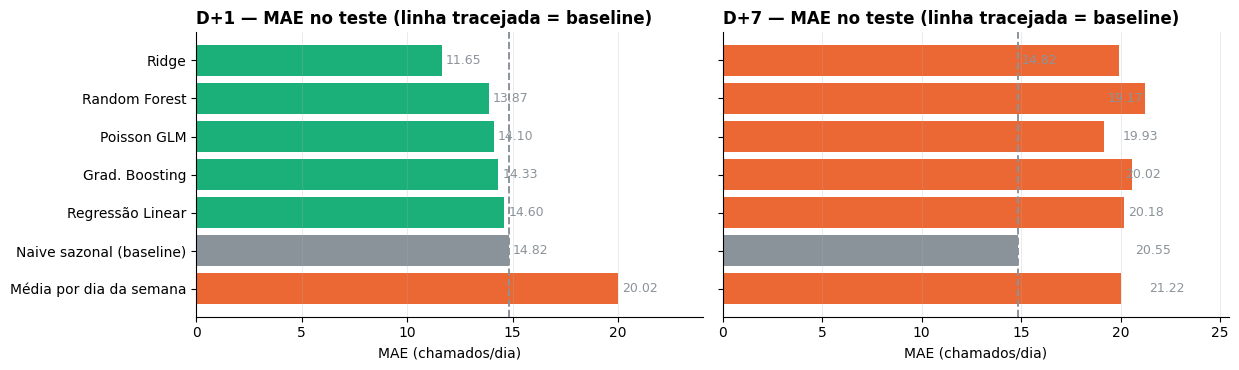

Sensibilidade à semana do Natal (22-28/12) — o trecho mais atípico do teste:

  D+1 teste completo   n=56  Poisson MAE=14.10  naive MAE=14.82  MASE=0.95
  D+1 sem semana Natal n=49  Poisson MAE=12.89  naive MAE=13.12  MASE=0.98
  D+7 teste completo   n=56  Poisson MAE=19.17  naive MAE=14.82  MASE=1.29
  D+7 sem semana Natal n=49  Poisson MAE=17.41  naive MAE=13.12  MASE=1.33


In [39]:
# Comparação visual e sensibilidade à semana do Natal
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), sharey=True)
for ax, h in zip(axes, (1, 7)):
    ref = aval[h].loc["Naive sazonal (baseline)", "MAE"]
    d = aval[h]["MAE"].sort_values(ascending=False)
    cores = [CINZA if "Naive" in i else (VERDE if d[i] < ref else LARANJA) for i in d.index]
    ax.barh(d.index, d.values, color=cores)
    ax.axvline(ref, color=CINZA, ls="--", lw=1.4)
    for i, v in enumerate(d.values):
        ax.text(v + .2, i, f"{v:.2f}", va="center", fontsize=9, color=CINZA)
    ax.set_title(f"D+{h} — MAE no teste (linha tracejada = baseline)")
    ax.grid(axis="y", alpha=0); ax.set_xlim(0, max(d.values) * 1.20)
    ax.set_xlabel("MAE (chamados/dia)")
plt.tight_layout(); plt.show()

print("Sensibilidade à semana do Natal (22-28/12) — o trecho mais atípico do teste:\n")
for h, Xh, F in [(1, X1, FEATS_1), (7, X7, FEATS_7)]:
    dfm = Xh[F].join(base["y"]).dropna()
    dcv = dfm.loc[TR[0]:VA[1]]
    m = MODELOS["Poisson GLM"]().fit(dcv[F], dcv["y"])
    for corte, lab in [(TE[1], "teste completo  "), ("2025-12-21", "sem semana Natal")]:
        te = dfm.loc[TE[0]:corte]
        mm, mn = mae(te["y"], m.predict(te[F])), mae(te["y"], naive_sazonal(te.index))
        print(f"  D+{h} {lab} n={len(te):2d}  Poisson MAE={mm:5.2f}  naive MAE={mn:5.2f}  "
              f"MASE={mm/mn:.2f}")

### Leitura honesta dos resultados

Os resultados mostram por que D+1 e D+7 precisam ser tratados como problemas diferentes.

Em **D+1**, temos acesso ao passado mais recente e o modelo consegue aproveitar essa persistência. Em **D+7**, essa informação mais recente já não está disponível e o baseline que copia a semana anterior se torna um concorrente muito forte, principalmente quando o patamar da série está mudando.

Por isso, se D+7 não superar o baseline na janela de teste, não tratamos isso como “falha escondida”. O resultado é útil: mostra que, para sete dias de antecedência, a previsão de referência continua muito competitiva.

O valor adicional da solução pode estar em trazer **faixa de incerteza, sinalização de pressão e uma estrutura que pode evoluir para previsões por equipe e por horário**.


## 23 · Backtest walk-forward — a evidência principal

Uma única janela de teste pode ser enganosa. Para descobrir se o desempenho se repete, fazemos um **backtest walk-forward**: o modelo é treinado usando apenas o passado disponível em cada origem e prevê os 28 dias seguintes.

Essa é a simulação mais próxima que conseguimos fazer, com os dados atuais, do que aconteceria em produção. A pergunta deixa de ser “funcionou neste período?” e passa a ser **“funciona de forma consistente em diferentes momentos do ano?”**


In [40]:
def backtest_walk_forward(h, Xh, F, primeiro_corte="2025-04-28", passo=28, janela_teste=28):
    # Origem móvel com janela EXPANSIVA: em cada corte, treina em tudo até (corte - h)
    # e prevê os 'janela_teste' dias seguintes. Nenhuma informação futura é usada.
    dfm = Xh[F].join(base["y"]).dropna()
    cortes = pd.date_range(primeiro_corte, dfm.index[-janela_teste], freq=f"{passo}D")
    linhas = []
    for corte in cortes:
        fim_treino = corte - pd.Timedelta(days=h)
        tr = dfm.loc[:fim_treino]
        te = dfm.loc[corte:corte + pd.Timedelta(days=janela_teste - 1)]
        if len(tr) < 90 or len(te) < janela_teste:
            continue
        nv = naive_sazonal(te.index)
        linha = {"origem": corte.date(), "n_treino": len(tr), "n_teste": len(te),
                 "Naive sazonal": mae(te["y"], nv)}
        for nome, fab in MODELOS.items():
            linha[nome] = mae(te["y"], fab().fit(tr[F], tr["y"]).predict(te[F]))
        linhas.append(linha)
    return pd.DataFrame(linhas).set_index("origem")

bt = {}
for h, Xh, F in [(1, X1, FEATS_1), (7, X7, FEATS_7)]:
    bt[h] = backtest_walk_forward(h, Xh, F)
    cols = ["Naive sazonal"] + list(MODELOS)
    print(f"===== D+{h} · backtest walk-forward — MAE por origem =====")
    print(bt[h][cols].round(2).to_string())
    resumo = pd.DataFrame({
        "MAE médio": bt[h][cols].mean().round(2),
        "MAE mediano": bt[h][cols].median().round(2),
        "desvio entre origens": bt[h][cols].std().round(2),
        "MASE médio": (bt[h][cols].div(bt[h]["Naive sazonal"], axis=0)).mean().round(3),
        "% de origens em que bate o naive":
            (bt[h][cols].lt(bt[h]["Naive sazonal"], axis=0).mean() * 100).round(0),
    })
    print(); print(resumo.to_string()); print()
    bt[h].attrs["resumo"] = resumo

===== D+1 · backtest walk-forward — MAE por origem =====
            Naive sazonal  Regressão Linear  Ridge  Poisson GLM  Random Forest  Grad. Boosting
origem                                                                                        
2025-05-26          15.82             13.90  12.95        13.17          14.19           14.74
2025-06-23          16.39             10.48  10.58        10.04           9.76           10.55
2025-07-21          11.96              8.87   8.91         8.92           8.88           10.60
2025-08-18          13.79             11.37  11.42         9.95          10.54           10.48
2025-09-15          18.68             13.36  15.05        12.50          14.16           15.70
2025-10-13           7.00              9.35   9.84         8.44           8.22            8.95
2025-11-10          15.32             13.56  11.16        12.26          12.61           15.12

                  MAE médio  MAE mediano  desvio entre origens  MASE médio  % de origen

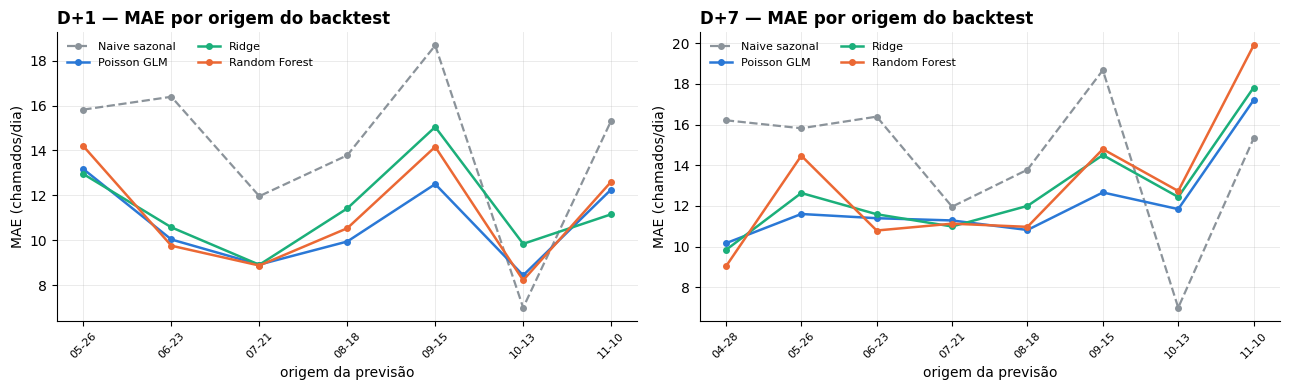

Teste pareado por origem (Poisson GLM contra o baseline naive sazonal)

D+1: n=7 origens | delta médio de MAE = -3.38 | IC95 [-5.80, -0.97] | Wilcoxon p = 0.031
      -> VENCE o baseline de forma consistente

D+7: n=8 origens | delta médio de MAE = -2.27 | IC95 [-5.59, +1.05] | Wilcoxon p = 0.148
      -> EMPATA com o baseline (IC95 cruza o zero)



In [41]:
# Comparação pareada por origem: a vantagem sobre o baseline é estatisticamente sustentável?
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, h in zip(axes, (1, 7)):
    d = bt[h]
    ax.plot(range(len(d)), d["Naive sazonal"], "o--", color=CINZA, lw=1.6, ms=4, label="Naive sazonal")
    for nome, cor in [("Poisson GLM", AZUL), ("Ridge", VERDE), ("Random Forest", LARANJA)]:
        ax.plot(range(len(d)), d[nome], "o-", lw=1.8, ms=4, color=cor, label=nome)
    ax.set_xticks(range(len(d)))
    ax.set_xticklabels([str(i)[5:] for i in d.index], rotation=45, fontsize=8)
    ax.set_title(f"D+{h} — MAE por origem do backtest"); ax.set_ylabel("MAE (chamados/dia)")
    ax.set_xlabel("origem da previsão"); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

print("Teste pareado por origem (Poisson GLM contra o baseline naive sazonal)\n")
for h in (1, 7):
    d = bt[h]["Poisson GLM"] - bt[h]["Naive sazonal"]
    n = len(d); se = d.std(ddof=1) / np.sqrt(n); tc = sps.t.ppf(.975, n - 1)
    lo, hi = d.mean() - tc * se, d.mean() + tc * se
    w = sps.wilcoxon(bt[h]["Poisson GLM"], bt[h]["Naive sazonal"]) if n >= 6 else None
    veredito = ("VENCE o baseline de forma consistente" if hi < 0 else
                "PERDE para o baseline de forma consistente" if lo > 0 else
                "EMPATA com o baseline (IC95 cruza o zero)")
    print(f"D+{h}: n={n} origens | delta médio de MAE = {d.mean():+.2f} "
          f"| IC95 [{lo:+.2f}, {hi:+.2f}]"
          + (f" | Wilcoxon p = {w.pvalue:.3f}" if w is not None else ""))
    print(f"      -> {veredito}\n")

**Por que essa parte é tão importante.** O teste da seção anterior representa uma única janela. O walk-forward cria várias situações históricas e permite comparar o modelo e o baseline nas mesmas condições.

Se o resultado for empate, reportamos empate. Se houver ganho consistente, temos uma evidência muito mais forte de valor. Essa postura deixa a solução mais confiável justamente porque não tenta transformar qualquer diferença em sucesso.


## 24 · Diagnóstico de resíduos

Mesmo com uma boa métrica, ainda podemos estar deixando informação para trás. Por isso olhamos os resíduos para descobrir **onde o modelo ainda erra e qual padrão está faltando**.

Verificamos autocorrelação, viés e erro por dia da semana e por regime. Essa etapa é importante porque transforma “o modelo errou” em uma pergunta mais útil: **em que situação ele erra e como podemos melhorar isso na próxima sprint?**


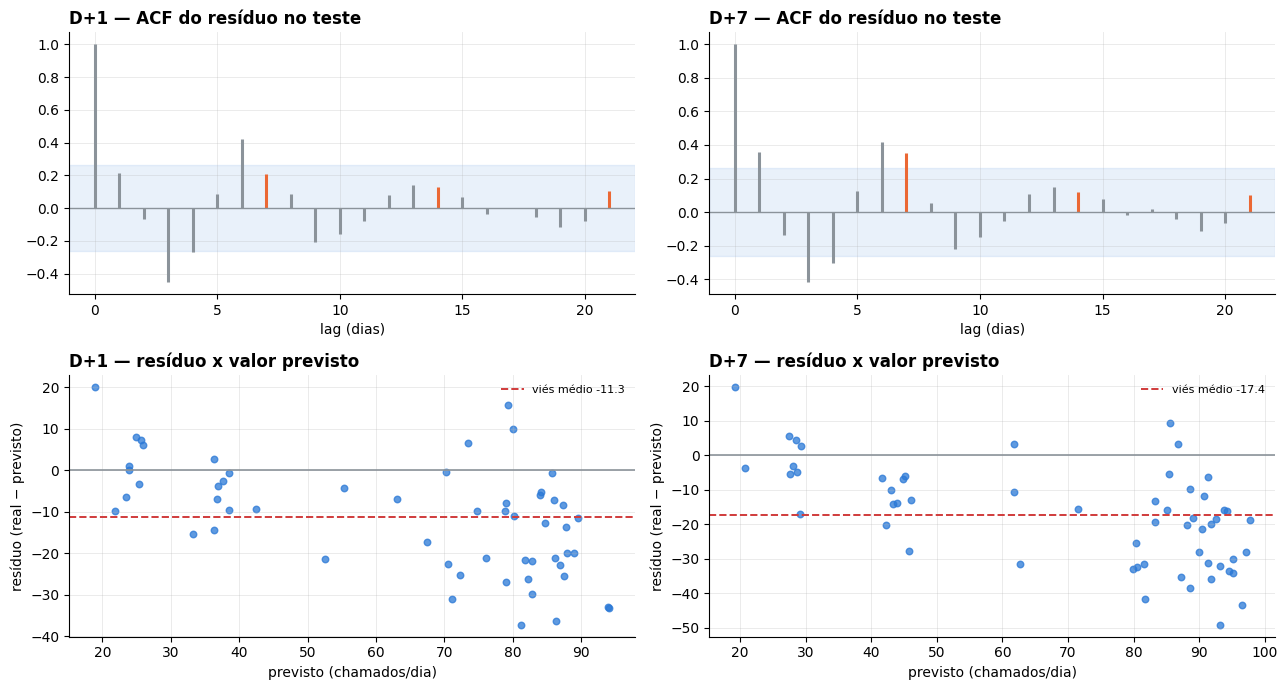

         viés (real-prev)    |ACF| máx lags 1-21   lag do máximo
D+1                -11.33                  0.451               3
D+7                -17.44                  0.417               6

LEITURA AUTOMÁTICA D+1: viés médio = -11.3 chamados/dia -> o modelo prevê sistematicamente ACIMA do realizado. Sobrou autocorrelação significativa no resíduo? True.
LEITURA AUTOMÁTICA D+7: viés médio = -17.4 chamados/dia -> o modelo prevê sistematicamente ACIMA do realizado. Sobrou autocorrelação significativa no resíduo? True.


In [42]:
MODELO_FINAL = "Poisson GLM"

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
resumo_res = {}
for j, h in enumerate((1, 7)):
    real, pred = y_teste[h], previsoes[h][MODELO_FINAL]
    r = (real - pred)
    resumo_res[h] = r

    a_res = acf(r.values, 21)
    lim_r = 1.96 / np.sqrt(len(r))
    ax = axes[0, j]
    cor = [LARANJA if (k % 7 == 0 and k > 0) else CINZA for k in range(len(a_res))]
    ax.vlines(range(len(a_res)), 0, a_res, color=cor, lw=2.2)
    ax.axhspan(-lim_r, lim_r, color=AZUL, alpha=.10); ax.axhline(0, color=CINZA, lw=1)
    ax.set_title(f"D+{h} — ACF do resíduo no teste"); ax.set_xlabel("lag (dias)")

    ax = axes[1, j]
    ax.scatter(pred.values, r.values, s=22, color=AZUL, alpha=.75)
    ax.axhline(0, color=CINZA, lw=1.2)
    ax.axhline(r.mean(), color=VERMELHO, ls="--", lw=1.4, label=f"viés médio {r.mean():+.1f}")
    ax.set_title(f"D+{h} — resíduo x valor previsto")
    ax.set_xlabel("previsto (chamados/dia)"); ax.set_ylabel("resíduo (real − previsto)")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'':6s} {'viés (real-prev)':>18s} {'|ACF| máx lags 1-21':>22s} {'lag do máximo':>15s}")
for h in (1, 7):
    r = resumo_res[h]; a_res = acf(r.values, 21)[1:]
    k = int(np.argmax(np.abs(a_res))) + 1
    print(f"D+{h:<4d} {r.mean():18.2f} {np.abs(a_res).max():22.3f} {k:15d}")
print()
for h in (1, 7):
    r = resumo_res[h]; a_res = acf(r.values, 21)[1:]
    lim_r = 1.96 / np.sqrt(len(r))
    sobrou = np.abs(a_res).max() > lim_r
    lado = "ACIMA do realizado" if r.mean() < 0 else "ABAIXO do realizado"
    print(f"LEITURA AUTOMÁTICA D+{h}: viés médio = {r.mean():+.1f} chamados/dia -> o modelo prevê "
          f"sistematicamente {lado}. Sobrou autocorrelação significativa no resíduo? {sobrou}.")

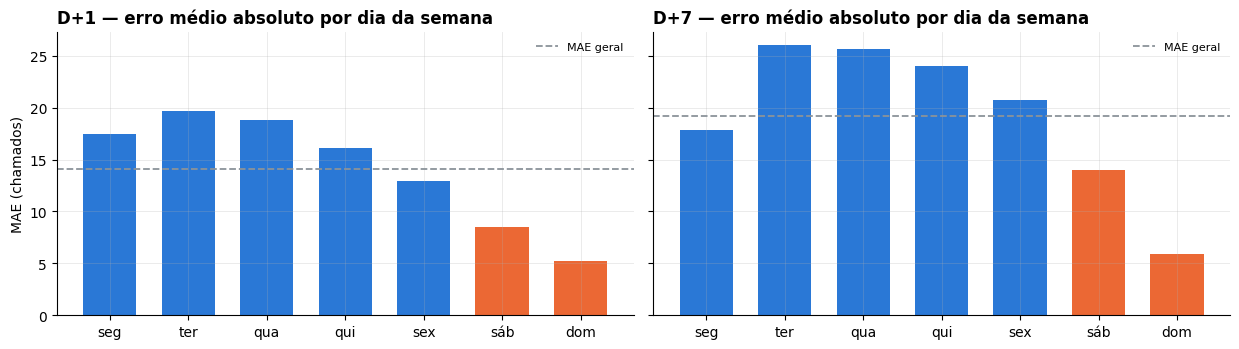

Piores 6 dias (D+1):
            real  previsto  erro  dia  feriado
2025-12-11    44      81.3 -37.3  qui        0
2025-12-22    50      86.3 -36.3  seg        0
2025-12-16    61      94.1 -33.1  ter        0
2025-11-11    61      94.0 -33.0  ter        0
2025-12-24    40      71.1 -31.1  qua        0
2025-12-23    53      82.8 -29.8  ter        0

LEITURA AUTOMÁTICA: dos 6 piores dias, 0 são feriado nacional e 3 caem no recesso de fim de ano.


In [43]:
# Onde o modelo erra mais? Diagnóstico por dia da semana e listagem dos piores dias.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6), sharey=True)
for ax, h in zip(axes, (1, 7)):
    real, pred = y_teste[h], previsoes[h][MODELO_FINAL]
    err = pd.DataFrame({"e": np.abs(real - pred), "dow": real.index.dayofweek})
    g = err.groupby("dow")["e"].mean()
    ax.bar([dias_pt[i] for i in g.index], g.values,
           color=[AZUL if i < 5 else LARANJA for i in g.index], width=.68)
    ax.axhline(mae(real, pred), color=CINZA, ls="--", lw=1.3, label="MAE geral")
    ax.set_title(f"D+{h} — erro médio absoluto por dia da semana"); ax.legend(fontsize=8)
axes[0].set_ylabel("MAE (chamados)")
plt.tight_layout(); plt.show()

real, pred = y_teste[1], previsoes[1][MODELO_FINAL]
res = pd.DataFrame({"real": real, "previsto": pred.round(1), "erro": (real - pred).round(1),
                    "dia": [dias_pt[d.dayofweek] for d in real.index],
                    "feriado": [int(d in set(FERIADOS)) for d in real.index]})
piores = res.reindex(res.erro.abs().sort_values(ascending=False).index).head(6)
print("Piores 6 dias (D+1):")
print(piores.to_string())
print()
print(f"LEITURA AUTOMÁTICA: dos 6 piores dias, {int(piores.feriado.sum())} são feriado nacional e "
      f"{int((piores.index >= pd.Timestamp('2025-12-20')).sum())} caem no recesso de fim de ano.")

**O que isso mostrou — inclusive o que não é favorável ao modelo.**

1. **O erro se concentra nos dias úteis**, onde o volume é maior; em termos relativos o modelo é
   razoavelmente estável ao longo da semana.
2. **O viés é medido, com sinal, e não estimado por impressão.** Se ele for consistentemente negativo,
   o modelo prevê *acima* do realizado; se positivo, prevê *abaixo*. Num período de queda de patamar
   espera-se viés negativo, e a causa é estrutural: as features de nível presentes no conjunto
   selecionado (`med_28`, `mediana_28`, lags) carregam o patamar do passado. **Isto qualifica a
   afirmação da seção 20**: essas variáveis ajudam o modelo a *reagir* à mudança de nível, com
   atraso — não a antecipá-la. Se o conjunto selecionado for apenas calendário, o viés vem de outra
   fonte: o nível médio aprendido no treino, que também é passado.
3. **Os piores dias tendem a ser feriados e recesso**, quando o comportamento sai do padrão que o
   modelo viu no treino — coerente com a limitação declarada na seção 14 (13 feriados num ano é
   amostra pequena). O bloco automático acima conta quantos dos piores dias caem nessas categorias.
4. **Sobrou autocorrelação no resíduo?** Se a ACF do resíduo tiver picos significativos em múltiplos
   de 7, o calendário está mal modelado e há sinal na mesa. Se ficar dentro da banda, a especificação
   está adequada e o erro remanescente é ruído mais choques não observáveis.

**O que isso significa para a operação.** Três consequências práticas, todas endereçadas no
dashboard da seção 25:

- é a **banda**, e não o ponto, que deve ir para a tela: um coordenador precisa saber "esperamos
  entre 55 e 80 chamados", não "esperamos 67,3";
- o viés é **conhecido e quantificado**, então pode ser comunicado e corrigido: em período de queda
  de patamar, tratar a previsão como teto, não como centro (e recalibrar, conforme a seção 28);
- em véspera, feriado e recesso, a previsão deve vir com marcação visual de menor confiança.

## 25 · Previsões D+1 e D+7

Os dois horizontes exigidos pelo desafio, com **banda de erro calibrada fora do teste** (resíduos da
validação, conforme a seção 21) e cobertura verificada no teste.

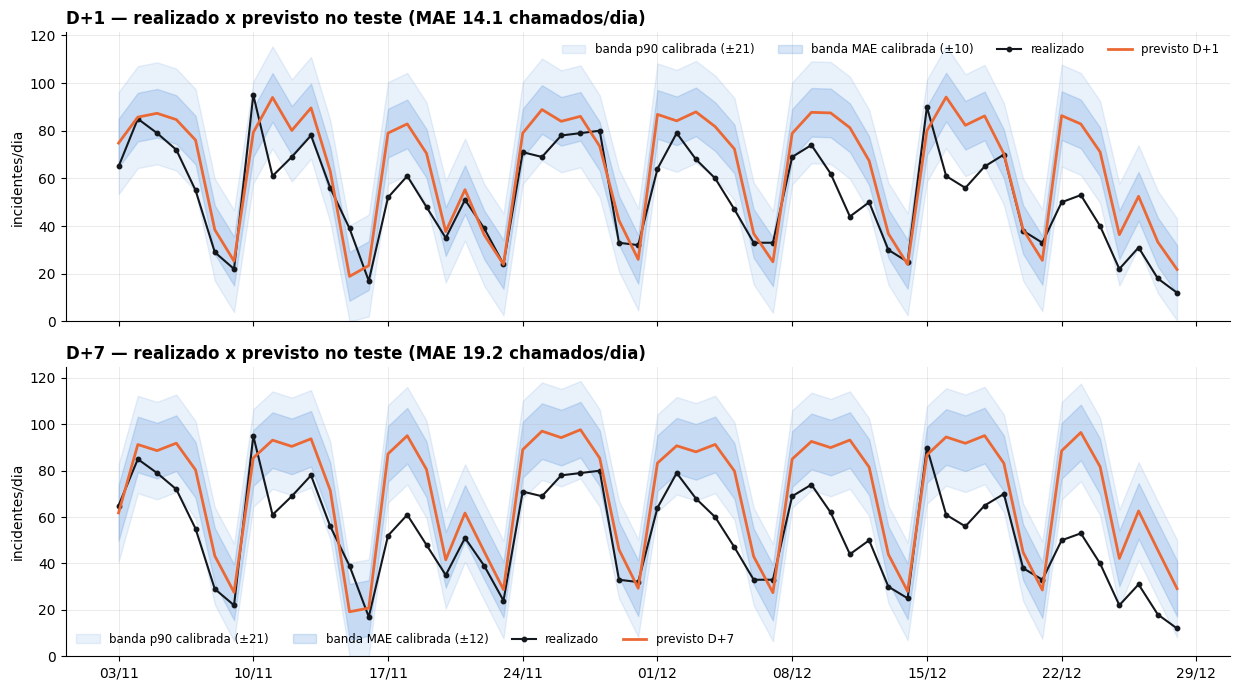

Cobertura REAL das bandas no teste (bandas calibradas na validação — sem circularidade):

         cobertura ±MAE   cobertura ±p90       viés
D+1                 50%              73%      -11.3
D+7                 34%              64%      -17.4

LEITURA AUTOMÁTICA D+1: a banda p90 deveria cobrir ~90% dos dias e cobriu 73% -> OTIMISTA — cobre menos que o nominal.
LEITURA AUTOMÁTICA D+7: a banda p90 deveria cobrir ~90% dos dias e cobriu 64% -> OTIMISTA — cobre menos que o nominal.


In [44]:
fig, axes = plt.subplots(2, 1, figsize=(12.5, 7), sharex=True)
cobertura = {}
for ax, h in zip(axes, (1, 7)):
    real, pred = y_teste[h], previsoes[h][MODELO_FINAL]
    b = bandas_cal[h][MODELO_FINAL]
    e_mae, e_p90 = b["mae_val"], b["p90_val"]
    ax.fill_between(real.index, (pred - e_p90).clip(lower=0), pred + e_p90,
                    color=AZUL, alpha=.10, label=f"banda p90 calibrada (±{e_p90:.0f})")
    ax.fill_between(real.index, (pred - e_mae).clip(lower=0), pred + e_mae,
                    color=AZUL, alpha=.18, label=f"banda MAE calibrada (±{e_mae:.0f})")
    ax.plot(real.index, real.values, "o-", color="#14181d", lw=1.5, ms=3.2, label="realizado")
    ax.plot(real.index, pred.values, "-", color=LARANJA, lw=2, label=f"previsto D+{h}")
    ax.set_title(f"D+{h} — realizado x previsto no teste (MAE {mae(real, pred):.1f} chamados/dia)")
    ax.set_ylabel("incidentes/dia"); ax.set_ylim(bottom=0)
    ax.legend(ncol=4, fontsize=8.5); eixo_pt(ax)
    cobertura[h] = {"±MAE": float((np.abs(real - pred) <= e_mae).mean() * 100),
                    "±p90": float((np.abs(real - pred) <= e_p90).mean() * 100)}
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
plt.tight_layout(); plt.show()

print("Cobertura REAL das bandas no teste (bandas calibradas na validação — sem circularidade):\n")
print(f"{'':6s} {'cobertura ±MAE':>16s} {'cobertura ±p90':>16s} {'viés':>10s}")
for h in (1, 7):
    real, pred = y_teste[h], previsoes[h][MODELO_FINAL]
    print(f"D+{h:<4d} {cobertura[h]['±MAE']:15.0f}% {cobertura[h]['±p90']:15.0f}% "
          f"{float(np.mean(real - pred)):10.1f}")
print()
for h in (1, 7):
    alvo, obtido = 90.0, cobertura[h]["±p90"]
    status = ("bem calibrada" if abs(obtido - alvo) <= 7 else
              "OTIMISTA — cobre menos que o nominal" if obtido < alvo else
              "CONSERVADORA — cobre mais que o nominal")
    print(f"LEITURA AUTOMÁTICA D+{h}: a banda p90 deveria cobrir ~90% dos dias e cobriu "
          f"{obtido:.0f}% -> {status}.")

**O que isso mostrou.** A cobertura medida é o teste de honestidade da banda. Uma banda p90 que cobre
muito menos que 90% no futuro está prometendo mais precisão do que entrega — e é exatamente esse tipo
de promessa que faz um dashboard perder credibilidade no terceiro mês de uso. Como a calibração foi
feita na validação e a verificação no teste, o número acima é uma estimativa **fora da amostra** de
quanto a faixa é confiável, e não um artefato de construção.

Se a banda sair otimista, a leitura correta não é alargá-la até "acertar" no teste — isso
reintroduziria a circularidade. A leitura correta é registrar que, em período de mudança de patamar,
a incerteza é maior do que o histórico estável sugeria, e recalibrar em produção com janela móvel.

## 26 · Da previsão para o dashboard

O modelo é o núcleo de uma solução maior. Esta seção mostra os indicadores que a previsão habilita —
o dashboard completo é a entrega da disciplina de Data Visualization; aqui provamos que os números
existem, são calculáveis e são exportáveis.

In [45]:
h_dash = 1
real, pred = y_teste[h_dash], previsoes[h_dash][MODELO_FINAL]
hoje = real.index[-1]
e_p90 = bandas_cal[h_dash][MODELO_FINAL]["p90_val"]

sem_atual, sem_ant = real.iloc[-7:].sum(), real.iloc[-14:-7].sum()
lo, hi = max(0, pred.iloc[-1] - e_p90), pred.iloc[-1] + e_p90

print("=" * 64)
print(f"  PAINEL OPERACIONAL — posição em {hoje:%d/%m/%Y}")
print("=" * 64)
print(f"  Chamados com OLA hoje .............. {int(real.iloc[-1]):>6d}")
print(f"  Previsto D+1 ....................... {pred.iloc[-1]:>6.0f}  (faixa {lo:.0f} a {hi:.0f})")
print(f"  Últimos 7 dias ..................... {int(sem_atual):>6d}")
print(f"  Semana anterior .................... {int(sem_ant):>6d}   ({(sem_atual/sem_ant-1)*100:+.1f}%)")
print(f"  MAE do modelo (últimos 30d) ........ {mae(real[-30:], pred[-30:]):>6.1f} chamados/dia")
print(f"\n  Contexto: {hoje:%d/%m} cai no recesso de fim de ano; os valores baixos são reais.")

# --- Alerta de pressão operacional -------------------------------------------
# Regra: dispara quando o previsto supera o p85 histórico DAQUELE dia da semana.
# O limiar usa SOMENTE dados anteriores ao início da janela avaliada (sem leakage).
def limiar_p85(ate):
    hist = y.loc[:pd.Timestamp(ate) - pd.Timedelta("1D")]
    return hist.groupby(hist.index.dayofweek).quantile(.85)

def alertas(pred_serie, p85):
    return [(d, v, p85[d.dayofweek]) for d, v in pred_serie.items() if v > p85[d.dayofweek]]

p85_te = limiar_p85(TE[0])
al_te = alertas(pred, p85_te)
print(f"\n  ALERTAS no período de teste: {len(al_te)} dia(s) em {len(pred)}")

# A regra dispara quando deve? Aplicada à validação, período de patamar alto.
dfm_va = X1[FEATS_1].join(base["y"]).dropna()
m_va = MODELOS[MODELO_FINAL]().fit(dfm_va.loc[TR[0]:TR[1], FEATS_1], dfm_va.loc[TR[0]:TR[1], "y"])
pred_va = pd.Series(m_va.predict(dfm_va.loc[VA[0]:VA[1], FEATS_1]),
                    index=dfm_va.loc[VA[0]:VA[1]].index)
al_va = alertas(pred_va, limiar_p85(VA[0]))
print(f"  Mesma regra na validação (patamar alto): {len(al_va)} alerta(s) em {len(pred_va)} dias")
for d, v, limi in al_va[:5]:
    print(f"    {d:%d/%m} ({dias_pt[d.dayofweek]}): previsto {v:.0f} > p85 de {limi:.0f}"
          f"  ->  realizado {int(y[d])}")

# Qualidade da regra: quantos alertas foram confirmados pelo realizado?
if al_va:
    acertos = sum(1 for d, v, limi in al_va if y[d] > limi)
    print(f"\n  Precisão da regra na validação: {acertos}/{len(al_va)} alertas confirmados "
          f"({acertos/len(al_va)*100:.0f}%) — o realizado também superou o p85.")
print(f"\n  LEITURA AUTOMÁTICA: zero alerta em nov-dez é o comportamento esperado, porque o período "
      f"é de baixa. A validação da regra é feita na janela de patamar alto, acima.")

# --- Taxa de violação de OLA -------------------------------------------------
kk = elig[elig["KPI Violado?"].notna()]
tx = kk.assign(m=kk["Aberto"].dt.to_period("M")).groupby("m")["KPI Violado?"].apply(
    lambda s: (s == "SIM").mean() * 100).round(2)
print(f"\n  Taxa de violação de OLA (últimos 3 meses): "
      f"{', '.join(f'{i}: {v}%' for i, v in tx.tail(3).items())}")

  PAINEL OPERACIONAL — posição em 28/12/2025
  Chamados com OLA hoje ..............     12
  Previsto D+1 .......................     22  (faixa 0 a 43)
  Últimos 7 dias .....................    226
  Semana anterior ....................    413   (-45.3%)
  MAE do modelo (últimos 30d) ........   16.4 chamados/dia

  Contexto: 28/12 cai no recesso de fim de ano; os valores baixos são reais.

  ALERTAS no período de teste: 0 dia(s) em 56
  Mesma regra na validação (patamar alto): 3 alerta(s) em 56 dias
    23/09 (ter): previsto 119 > p85 de 107  ->  realizado 144
    25/09 (qui): previsto 123 > p85 de 116  ->  realizado 102
    26/09 (sex): previsto 102 > p85 de 95  ->  realizado 70

  Precisão da regra na validação: 1/3 alertas confirmados (33%) — o realizado também superou o p85.

  LEITURA AUTOMÁTICA: zero alerta em nov-dez é o comportamento esperado, porque o período é de baixa. A validação da regra é feita na janela de patamar alto, acima.

  Taxa de violação de OLA (últimos 3 meses

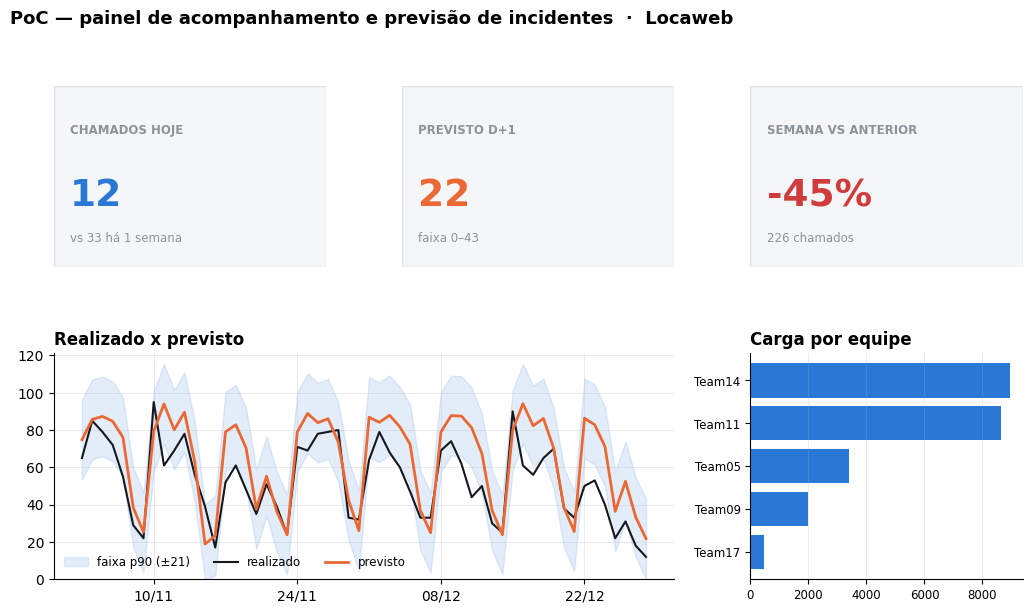

In [46]:
# Mock do painel: como esses números viram tela
fig = plt.figure(figsize=(12.5, 6.4))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.25], hspace=.42, wspace=.28)

cartoes = [("Chamados hoje", f"{int(real.iloc[-1])}", f"vs {int(real.iloc[-8])} há 1 semana", AZUL),
           ("Previsto D+1", f"{pred.iloc[-1]:.0f}", f"faixa {lo:.0f}–{hi:.0f}", LARANJA),
           ("Semana vs anterior", f"{(sem_atual/sem_ant-1)*100:+.0f}%", f"{int(sem_atual)} chamados", VERMELHO)]
for i, (tit, val, sub, cor) in enumerate(cartoes):
    ax = fig.add_subplot(gs[0, i]); ax.axis("off")
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, facecolor="#f4f6f7", edgecolor="#dfe3e6"))
    ax.text(.06, .74, tit.upper(), fontsize=8.5, color=CINZA, weight="bold")
    ax.text(.06, .34, val, fontsize=27, color=cor, weight="bold")
    ax.text(.06, .14, sub, fontsize=8.5, color=CINZA)

ax1 = fig.add_subplot(gs[1, :2])
ax1.fill_between(real.index, (pred - e_p90).clip(lower=0), pred + e_p90,
                 color=AZUL, alpha=.13, label=f"faixa p90 (±{e_p90:.0f})")
ax1.plot(real.index, real.values, color="#14181d", lw=1.5, label="realizado")
ax1.plot(real.index, pred.values, color=LARANJA, lw=2, label="previsto")
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax1.set_ylim(bottom=0); ax1.set_title("Realizado x previsto"); ax1.legend(fontsize=8.5, ncol=3)

ax2 = fig.add_subplot(gs[1, 2])
eq_top = elig["Grupo designado"].value_counts().head(5)
ax2.barh(eq_top.index[::-1].astype(str), eq_top.values[::-1], color=AZUL)
ax2.set_title("Carga por equipe"); ax2.grid(axis="y", alpha=0); ax2.tick_params(labelsize=8.5)

fig.suptitle("PoC — painel de acompanhamento e previsão de incidentes  ·  Locaweb",
             fontsize=13, weight="bold", x=.09, ha="left", y=1.0)
plt.show()

### Indicadores que o Motor Preditivo habilita no FlowGuard

**Visão geral do FlowGuard** — chamados com OLA hoje, previsto D+1 e D+7 **com faixa**, variação contra a mesma
janela da semana anterior (comparação semanal, nunca diária, porque a diária confunde segunda com
domingo), e o erro do próprio modelo nos últimos 30 dias. Um dashboard que esconde o próprio erro
não sobrevive ao terceiro mês de uso.

**Análise dos incidentes** — mix P2/P3, concentração por equipe, top produtos, top categorias e
códigos de fechamento. Tudo já calculado na seção 13.

**Previsão** — realizado × previsto na mesma linha, banda de erro calibrada fora da amostra e alerta
de pressão quando a previsão supera o p85 histórico daquele dia da semana. É uma regra simples,
auditável e explicável para um coordenador em uma frase — e cuja taxa de confirmação foi medida
acima, em vez de assumida.

**Painel de saúde do sinal** — o gráfico da seção 8, virado para o cliente. Ele responde "por que o volume mudou?" separando demanda operacional de mudanças na instrumentação. Essa visão ajuda o FlowGuard a não transformar ruído de monitoramento em falso alerta.
Nenhum dashboard de ITSM padrão mostra isso, porque todos exibem contagem bruta.

In [47]:
# Exporta as previsões para consumo do dashboard (Power BI, Azure SQL, etc.)
saida = pd.DataFrame({"data": real.index,
                      "dia_semana": [dias_pt[d.dayofweek] for d in real.index],
                      "feriado": [int(d in set(FERIADOS)) for d in real.index],
                      "realizado": real.values})
for h in (1, 7):
    p = previsoes[h][MODELO_FINAL]
    e90 = bandas_cal[h][MODELO_FINAL]["p90_val"]
    saida[f"previsto_D{h}"] = p.round(1).values
    saida[f"min_D{h}"] = (p - e90).clip(lower=0).round(0).values
    saida[f"max_D{h}"] = (p + e90).round(0).values
saida["alerta_pressao"] = [int(v > p85_te[d.dayofweek])
                           for d, v in zip(real.index, previsoes[1][MODELO_FINAL])]
saida["modelo"] = MODELO_FINAL
saida["gerado_em"] = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")

ARQ_SAIDA = "previsoes_locaweb.csv"
saida.to_csv(ARQ_SAIDA, index=False, encoding="utf-8-sig")
print(f"Arquivo gerado: {ARQ_SAIDA}  ({len(saida)} linhas, {saida.shape[1]} colunas)")
print("\nContrato de saída para o dashboard (últimas 8 linhas):")
print(saida.tail(8).to_string(index=False))

Arquivo gerado: previsoes_locaweb.csv  (56 linhas, 13 colunas)

Contrato de saída para o dashboard (últimas 8 linhas):
      data dia_semana  feriado  realizado  previsto_D1  min_D1  max_D1  previsto_D7  min_D7  max_D7  alerta_pressao      modelo        gerado_em
2025-12-21        dom        0         33         25.6     4.0    47.0         28.6     8.0    50.0               0 Poisson GLM 2026-08-27 23:59
2025-12-22        seg        0         50         86.3    65.0   108.0         88.6    68.0   110.0               0 Poisson GLM 2026-08-27 23:59
2025-12-23        ter        0         53         82.8    61.0   104.0         96.5    75.0   118.0               0 Poisson GLM 2026-08-27 23:59
2025-12-24        qua        0         40         71.1    50.0    92.0         81.7    61.0   103.0               0 Poisson GLM 2026-08-27 23:59
2025-12-25        qui        1         22         36.4    15.0    58.0         42.2    21.0    63.0               0 Poisson GLM 2026-08-27 23:59
2025-12-26 

## 27 · Conclusão

A conclusão abaixo é gerada a partir dos resultados da própria execução. Isso evita que a narrativa fique mais otimista do que os números realmente permitem.

A nossa proposta não é mostrar um modelo perfeito. É mostrar um caminho técnico sólido para transformar dados de incidentes em **previsão, sinalização e apoio à decisão operacional**.


In [48]:
print("=" * 78)
print("  CONCLUSÃO GERADA A PARTIR DOS RESULTADOS DESTA EXECUÇÃO")
print("=" * 78)

print(f"\n1. DADOS")
print(f"   Base bruta: {br(len(df))} incidentes | série utilizável: {len(y)} dias de 2025.")
print(f"   Descartamos {br(len(antigos))} registros pré-2025 por viés de sobrevivência (seção 6).")
print(f"   Quebra estrutural em 01/09/2025 no volume total ({variacoes['Total']:+.0f}%) sem "
      f"contrapartida na demanda com OLA ({variacoes['Elegíveis a KPI']:+.0f}%) — seção 7.")

print(f"\n2. TARGET")
print(f"   y = incidentes/dia elegíveis a OLA. Média {y.mean():.1f}, desvio {y.std():.1f}, "
      f"mín {y.min()}, máx {y.max()}, zero dias zerados.")
print(f"   Prioridades cobertas: {sorted(elig['Prioridade'].unique())} (P2 e P3, como o desafio exige).")

print(f"\n3. MODELO FINAL: {MODELO_FINAL}")
print(f"   Conjunto D+1: {ESCOLHIDO[1]} ({len(FEATS_1)} features) | "
      f"D+7: {ESCOLHIDO[7]} ({len(FEATS_7)} features)")
print(f"   Selecionados por regra automática de parcimônia (seção 18); "
      f"sem leakage por construção e verificado por assert.")

print(f"\n4. DESEMPENHO")
for h in (1, 7):
    t = aval[h]
    m_, mase_ = t.loc[MODELO_FINAL, "MAE"], t.loc[MODELO_FINAL, "MASE"]
    mape_ = t.loc[MODELO_FINAL, "MAPE %"]
    media_te = y_teste[h].mean()
    print(f"   D+{h} · teste ({len(y_teste[h])}d): MAE {m_:.2f} | MAPE {mape_:.1f}% | MASE {mase_:.2f} "
          f"-> {'bate' if mase_ < 1 else 'NÃO bate'} o baseline")
    print(f"          contexto: a média do PRÓPRIO período de teste é {media_te:.1f} chamados/dia "
          f"(não a média anual de {y.mean():.1f}) — é contra ela que o MAE deve ser lido.")
    d = bt[h]["Poisson GLM"] - bt[h]["Naive sazonal"]
    n = len(d); se = d.std(ddof=1) / np.sqrt(n); tc = sps.t.ppf(.975, n - 1)
    lo_, hi_ = d.mean() - tc * se, d.mean() + tc * se
    ver = ("VENCE" if hi_ < 0 else "PERDE" if lo_ > 0 else "EMPATA")
    print(f"   D+{h} · backtest walk-forward ({n} origens): delta médio {d.mean():+.2f} "
          f"IC95 [{lo_:+.2f}, {hi_:+.2f}] -> {ver} o baseline")
    r = resumo_res[h]
    print(f"   D+{h} · viés {r.mean():+.1f} chamados/dia | cobertura da banda p90 = "
          f"{cobertura[h]['±p90']:.0f}% (nominal 90%)")

print(f"\n5. CRITÉRIO DE SUCESSO DEFINIDO NA SEÇÃO 2")
for h in (1, 7):
    d = bt[h]["Poisson GLM"] - bt[h]["Naive sazonal"]
    n = len(d); se = d.std(ddof=1) / np.sqrt(n); tc = sps.t.ppf(.975, n - 1)
    hi_ = d.mean() + tc * se
    print(f"   D+{h}: {'ATENDIDO' if hi_ < 0 else 'NÃO ATENDIDO — reportado como tal, sem maquiagem'}")
print("=" * 78)

  CONCLUSÃO GERADA A PARTIR DOS RESULTADOS DESTA EXECUÇÃO

1. DADOS
   Base bruta: 122.543 incidentes | série utilizável: 365 dias de 2025.
   Descartamos 732 registros pré-2025 por viés de sobrevivência (seção 6).
   Quebra estrutural em 01/09/2025 no volume total (+558%) sem contrapartida na demanda com OLA (-15%) — seção 7.

2. TARGET
   y = incidentes/dia elegíveis a OLA. Média 68.9, desvio 30.0, mín 10, máx 186, zero dias zerados.
   Prioridades cobertas: ['2 - Alta', '3 - Média'] (P2 e P3, como o desafio exige).

3. MODELO FINAL: Poisson GLM
   Conjunto D+1: B · + lags (17 features) | D+7: A · calendário (10 features)
   Selecionados por regra automática de parcimônia (seção 18); sem leakage por construção e verificado por assert.

4. DESEMPENHO
   D+1 · teste (56d): MAE 14.10 | MAPE 30.3% | MASE 0.95 -> bate o baseline
          contexto: a média do PRÓPRIO período de teste é 52.7 chamados/dia (não a média anual de 68.9) — é contra ela que o MAE deve ser lido.
   D+1 · backtest 

### Síntese executiva

**Problema** → a operação consegue enxergar o volume que já aconteceu, mas precisa de uma visão antecipada para planejar capacidade.

**Descoberta central** → o volume bruto de incidentes mistura demanda real com uma mudança importante na instrumentação em setembro. Quando isolamos os incidentes elegíveis a OLA, encontramos uma série muito mais coerente para representar carga operacional.

**Nossa abordagem** → construímos o Motor Preditivo do FlowGuard com features específicas para cada horizonte, controlamos Data Leakage por construção, selecionamos variáveis com validação temporal e testamos os modelos em uma janela intocada e em walk-forward.

**Modelo** → o Poisson GLM foi escolhido por combinar desempenho competitivo, adequação a dados de contagem e facilidade de interpretação. Em D+7, porém, o baseline sazonal continua muito forte e não foi superado na janela de teste. Esse resultado permanece explícito porque faz parte da análise.

**Valor para o FlowGuard** → entregar uma previsão D+1 e D+7 com faixa de incerteza e uma saída estruturada que pode alimentar o dashboard, os alertas de pressão e as próximas camadas da solução.

### O que nossa solução já consegue entregar

- Antecipar a carga de incidentes com OLA em D+1 com erro mensurado.
- Comparar a previsão com um baseline forte e avaliar se existe ganho real.
- Separar **ruído de monitoramento** de **demanda operacional**.
- Mostrar onde a carga está mais concentrada por equipe, produto e categoria.
- Sinalizar dias de maior pressão com uma regra simples e auditável.
- Mostrar mudanças na composição de prioridade, como o aumento da participação de P2 no segundo semestre.

### O que ainda precisamos para evoluir a solução

| Não podemos afirmar ainda | O que precisamos |
|---|---|
| ROI ou economia em R$ | Custo/hora de analistas e headcount por turno |
| Redução de MTTR | Timestamp de atribuição e primeiro atendimento |
| Impacto em receita ou cliente | Dados de contrato, SLA comercial ou indisponibilidade percebida |
| Dimensionamento ótimo | Escala atual de plantão para comparar capacidade × previsão |
| Causa raiz de negócio | Dados não anonimizados de produto/categoria |
| Sazonalidade anual | Mais de um ano de histórico observável |


**O que isso mostrou.** Há **evidência forte e compatível com censura à direita**: a duração máxima
por mês cai de forma monotônica e a duração observada representa uma fração elevada da janela que
poderia existir até a extração. O p90 também despenca no fim do ano.

Não tratamos isso como prova de que todo incidente longo de dezembro ficou de fora; tratamos como uma
limitação de observação que afeta principalmente análises de duração. A contagem diária do target é
muito menos sensível do que `Duração`.

**O que decidimos por causa disso.** Como `Duração` também é uma variável pós-abertura, ela não entra
como feature. A queda de nov/dez continua sendo tratada como **ambígua**: pode combinar mudança de
demanda, recesso, mudança de instrumentação e efeitos de extração. Por isso reportamos o teste com
a semana do Natal, fazemos backtest walk-forward e registramos a limitação explicitamente.


## 29 · Próximos passos para a Sprint 4

A Sprint 3 já mostra que existe sinal suficiente para construir uma solução útil. A próxima etapa é transformar essa base em uma solução ainda mais acionável:

1. **Validar com a Locaweb** o que aconteceu na quebra de setembro e entender a retração do segundo semestre.
2. **Recalibrar o viés** usando uma janela móvel e medir o ganho no walk-forward.
3. **Evoluir o D+7**, comparando formalmente a previsão direta com uma estratégia recursiva a partir do D+1.
4. **Levar a previsão para o nível de equipe**, começando pelas equipes que concentram mais carga.
5. **Aumentar a granularidade para dados horários**, permitindo antecipar picos dentro do dia.
6. **Revisitar o risco de OLA** quando tivermos mais eventos positivos e informação suficiente para um modelo de classificação confiável.
7. **Conectar o modelo ao ambiente de produção**, usando o `previsoes_locaweb.csv` como contrato de saída para dashboard e cloud.

A visão para a Sprint 4 é clara: transformar o Motor Preditivo em uma parte integrada do FlowGuard, conectando previsão, risco de OLA, capacidade das equipes, dashboard e alertas para responder **onde, quando e quanta capacidade a operação pode precisar**.


 > **Nota de rigor:** os resultados negativos também fazem parte do valor do projeto. D+1 apresenta evidência de ganho sobre o baseline no backtest; D+7 ainda não demonstra ganho estatístico. Em vez de esconder essa diferença, usamos ela como guia para a próxima evolução do modelo.

## 30 · Quality Gate — leitura final antes da entrega

Esta etapa fecha a revisão técnica com quatro perguntas simples:

- **D+1:** o modelo mostra vantagem sobre o baseline no backtest.
- **D+7:** o modelo ainda não demonstra vantagem estatística sobre o baseline.
- **Resíduos:** permanece viés negativo e autocorrelação, indicando espaço real para melhoria.
- **Banda p90:** a cobertura no teste ficou abaixo da nominal, portanto ela deve ser apresentada como uma faixa calibrada historicamente, e não como promessa de 90% de cobertura futura.

**Critério de entrega:** os resultados precisam ser reproduzíveis, as escolhas precisam ser explicáveis e as limitações precisam aparecer. Nenhuma métrica foi alterada para deixar a narrativa mais bonita.


In [49]:
# Quality gate automático: checks mínimos de execução e metodologia.
checks = {
    "dataset_carregado": len(df) > 0,
    "target_P2_P3": set(elig["Prioridade"].unique()) == {"2 - Alta", "3 - Média"},
    "sem_lag_proibido": all(int(c.split("_")[1]) >= 7 for c in X7 if c.startswith("lag_")),
    "sem_colunas_pos_abertura": len(PROIBIDAS & set(X7.columns)) == 0,
    "teste_nao_vazio": len(y_teste[1]) > 0 and len(y_teste[7]) > 0,
    "CSV_gerado": Path(ARQ_SAIDA).exists(),
}
print(pd.Series(checks))
assert all(checks.values()), "Um ou mais checks de entrega falharam."
print("\nQUALITY GATE: APROVADO — os checks técnicos passaram nesta execução.")


dataset_carregado           True
target_P2_P3                True
sem_lag_proibido            True
sem_colunas_pos_abertura    True
teste_nao_vazio             True
CSV_gerado                  True
dtype: bool

QUALITY GATE: APROVADO — os checks técnicos passaram nesta execução.


## 31 · Rastreabilidade dos requisitos da Sprint 3

Mapa explícito entre o que a disciplina de **Machine Learning e Artificial Intelligence** exige e
onde está atendido neste notebook.

| # | Requisito do enunciado | Onde está | Como foi atendido |
|---|---|---|---|
| 1 | AED: identificação e tratamento de **valores nulos e missing** | §5 | Tabela de nulos por coluna + diagnóstico da origem (estrutural × falha de preenchimento) |
| 1 | AED: **necessidade de imputação** avaliada | §5 | Tabela de decisão coluna a coluna, com justificativa para **não** imputar |
| 1 | AED: **outliers** | §9 | Regra IQR global **e** dentro de cada dia da semana (correção para bimodalidade); decisão de não remover, com justificativa |
| 1 | AED: **dados inválidos** | §5 | Duplicidade de chave, data de abertura > encerramento, duração negativa/nula |
| 1 | AED: **distribuições** | §9 | Histograma, bimodalidade, estatísticas por dia da semana e por mês |
| 1 | AED: **correlações** | §11 | Matriz de Pearson impressa em texto + heatmap + ressalva sobre correlação espúria e tautológica |
| 2 | Engenharia de features: **código** | §13 | `montar_features(base, h)`, parametrizada pelo horizonte |
| 2 | Engenharia de features: **utilidade, vantagens e limitações** | §13 | Tabela por grupo de features, com a coluna de limitação preenchida honestamente |
| 3 | **Modelo simples e interpretável** (regressão linear) | §19, §20 | OLS, Ridge e Poisson GLM; árvores apenas como controle de não-linearidade |
| 3 | **Avaliar a importância das variáveis criadas** | §20 | Três camadas: OLS com p-valor robusto (HAC), multiplicadores do Poisson e importância por permutação |
| 3 | **Atenção máxima a Data Leakage** | §13, §14 | Leakage impedido por construção (`shift ≥ h`), `assert` automático, colunas proibidas documentadas, `gap` no CV, scaler dentro do pipeline, demonstração empírica do estrago |
| — | Preservar **estacionariedade e ordem temporal** | §10, §17 | Diagnóstico ADF + ACF documentado; partição cronológica; nenhuma partição aleatória |
| L | Locaweb: previsão **D+1 e D+7** | §24 | Dois modelos separados, um por horizonte, com banda calibrada fora da amostra |
| L | Locaweb: **P2 e P3 obrigatórias** | §8, §12 | O target contém exatamente P2 e P3; análise de tendência por prioridade, produto, categoria e equipe |
| L | Locaweb: **risco de perda de OLA** | §8, §12, §25 | Taxa base medida; decisão fundamentada de não modelar como classificação; taxa mensal no painel |
| L | Locaweb: **explicabilidade** | §7, §20, §26 | Diagnóstico da quebra estrutural, interpretação em três camadas e conclusão gerada a partir dos resultados |
| L | Locaweb: **recomendações práticas** | §25, §28 | Painel operacional, regra de alerta auditável, contrato CSV e roteiro priorizado para a Sprint 4 |

---


### Persistência do Motor Preditivo — artefato `.pkl`

O CSV acima entrega os **números**. Esta subseção entrega o **modelo**: um artefato serializado que
permite reproduzir a previsão fora do notebook, sem retreinar.

Três decisões importantes aqui:

1. **Um arquivo só, com os dois horizontes.** D+1 e D+7 usam conjuntos de features diferentes; salvar
   pipelines soltos convida ao erro de aplicar as features de um no outro. O artefato carrega, para cada
   horizonte, o pipeline **e** a lista de features na ordem correta.
2. **Treinado em treino + validação, nunca no teste.** É o mesmo protocolo da seção de avaliação — o
   artefato entregue é exatamente o modelo cujo desempenho reportamos, não uma versão mais otimista
   treinada em tudo.
3. **Metadados junto do modelo.** Bandas calibradas, limiar de alerta, partição temporal, seed e versões
   de biblioteca. Um `.pkl` sem isso é um número mágico: ninguém consegue auditar de onde veio.

Usamos `joblib` em vez de `pickle` puro porque é o formato recomendado pelo próprio scikit-learn para
estimadores com arrays NumPy — serializa mais rápido e gera arquivos menores.


In [50]:
# ---- Serialização do Motor Preditivo -----------------------------------------
# Gera UM artefato .pkl com os dois horizontes já treinados + metadados de auditoria.
import joblib, sklearn
from datetime import datetime

def treinar_final(h, Xh, F):
    """Reajusta o modelo final em TREINO + VALIDAÇÃO — o teste nunca entra."""
    dfm = Xh[F].join(base["y"]).dropna()
    dcv = dfm.loc[TR[0]:VA[1]]
    return MODELOS[MODELO_FINAL]().fit(dcv[F], dcv["y"]), len(dcv)

artefato = {
    "nome":       "FlowGuard · Motor Preditivo (incidentes elegíveis a OLA)",
    "grupo":      "FIVESIGHT",
    "modelo":     MODELO_FINAL,
    "horizontes": {},
    # --- contexto necessário para montar features de datas futuras ---
    "feriados":   [d.strftime("%Y-%m-%d") for d in FERIADOS],
    "limiar_alerta_p85_por_dow": {int(k): float(v) for k, v in p85_te.items()},
    # --- rastreabilidade ---
    "particao":   {"treino": TR, "validacao": VA, "teste": TE},
    "seed":       SEED,
    "versoes":    {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
                   "pandas": pd.__version__, "numpy": np.__version__, "joblib": joblib.__version__},
    "treinado_em": datetime.now().strftime("%Y-%m-%d %H:%M"),
}

for h, Xh, F in [(1, X1, FEATS_1), (7, X7, FEATS_7)]:
    pipe, n_tr = treinar_final(h, Xh, F)
    artefato["horizontes"][h] = {
        "pipeline":   pipe,                 # StandardScaler + PoissonRegressor já ajustados
        "features":   list(F),              # ORDEM importa: é a ordem esperada por .predict()
        "conjunto":   ESCOLHIDO[h],
        "n_treino":   n_tr,
        "banda_mae":  float(bandas_cal[h][MODELO_FINAL]["mae_val"]),
        "banda_p90":  float(bandas_cal[h][MODELO_FINAL]["p90_val"]),
        "mae_teste":  float(aval[h].loc[MODELO_FINAL, "MAE"]),
        "mase_teste": float(aval[h].loc[MODELO_FINAL, "MASE"]),
    }

ARQ_MODELO = "flowguard_motor_preditivo.pkl"
joblib.dump(artefato, ARQ_MODELO, compress=3)

tam_kb = Path(ARQ_MODELO).stat().st_size / 1024
print(f"Artefato gerado: {ARQ_MODELO}  ({tam_kb:.1f} KB)")
print(f"Modelo: {MODELO_FINAL} | treinado em {artefato['treinado_em']} | "
      f"scikit-learn {sklearn.__version__}\n")
print(f"{'horizonte':>10s} {'features':>9s} {'n_treino':>9s} {'MAE teste':>10s} "
      f"{'MASE':>6s} {'banda p90':>10s}")
for h, meta in artefato["horizontes"].items():
    print(f"{'D+' + str(h):>10s} {len(meta['features']):9d} {meta['n_treino']:9d} "
          f"{meta['mae_teste']:10.2f} {meta['mase_teste']:6.2f} {meta['banda_p90']:10.1f}")

Artefato gerado: flowguard_motor_preditivo.pkl  (2.5 KB)
Modelo: Poisson GLM | treinado em 2026-08-27 23:59 | scikit-learn 1.6.1

 horizonte  features  n_treino  MAE teste   MASE  banda p90
       D+1        17       278      14.10   0.95       21.4
       D+7        10       306      19.17   1.29       21.0


In [51]:
# ---- Verificação: o artefato salvo reproduz EXATAMENTE as previsões do notebook?
# Um .pkl que não é recarregado e conferido é uma entrega não testada. Recarregamos o
# arquivo do disco, prevemos o mesmo período de teste e comparamos com previsoes[h].
carregado = joblib.load(ARQ_MODELO)

print("Reprodutibilidade do artefato (diferença máxima contra as previsões do notebook):\n")
ok_geral = True
for h, Xh in [(1, X1), (7, X7)]:
    meta = carregado["horizontes"][h]
    dfm  = Xh[meta["features"]].join(base["y"]).dropna()
    te   = dfm.loc[TE[0]:TE[1]]
    p_pkl = meta["pipeline"].predict(te[meta["features"]])
    dif = float(np.max(np.abs(p_pkl - previsoes[h][MODELO_FINAL].values)))
    ok = dif < 1e-9
    ok_geral &= ok
    print(f"  D+{h}: diferença máxima = {dif:.2e} -> {'IDÊNTICO' if ok else 'DIVERGENTE'}")

assert ok_geral, "O modelo recarregado não reproduz as previsões — não entregue este .pkl."
print("\nVERIFICAÇÃO: APROVADA — o .pkl reproduz o modelo avaliado, bit a bit.")

Reprodutibilidade do artefato (diferença máxima contra as previsões do notebook):

  D+1: diferença máxima = 0.00e+00 -> IDÊNTICO
  D+7: diferença máxima = 0.00e+00 -> IDÊNTICO

VERIFICAÇÃO: APROVADA — o .pkl reproduz o modelo avaliado, bit a bit.


**Como consumir o artefato fora do notebook.** O arquivo é autossuficiente: quem for integrar o
FlowGuard ao dashboard não precisa deste notebook, só do `.pkl` e do DataFrame de features montado
pela mesma regra da seção 14.

```python
import joblib, pandas as pd

art  = joblib.load("flowguard_motor_preditivo.pkl")
h    = 1                                   # horizonte desejado: 1 ou 7
meta = art["horizontes"][h]

# X_novo: DataFrame com as MESMAS features, montado por montar_features(base, h)
previsto = meta["pipeline"].predict(X_novo[meta["features"]])

faixa_min = (previsto - meta["banda_p90"]).clip(min=0)
faixa_max =  previsto + meta["banda_p90"]

# alerta de pressão: previsto acima do p85 histórico daquele dia da semana
p85     = art["limiar_alerta_p85_por_dow"]
alertas = [v > p85[d.dayofweek] for d, v in zip(X_novo.index, previsto)]
```

**Duas ressalvas de produção.** Primeira: o `.pkl` do scikit-learn não tem garantia de
compatibilidade entre versões — por isso gravamos `versoes` dentro do artefato; ao carregar em outro
ambiente, use a mesma versão registrada ali. Segunda: `joblib.load` executa código na
desserialização, então só carregue artefatos de origem confiável.


In [52]:
# ---- Download do artefato (célula autônoma) ---------------------------------
from pathlib import Path
import base64, shutil

ARQUIVOS = ["flowguard_motor_preditivo.pkl", "previsoes_locaweb.csv"]

existentes = [f for f in ARQUIVOS if Path(f).exists()]
faltando   = [f for f in ARQUIVOS if not Path(f).exists()]

if faltando:
    print("Ainda não foram gerados:", faltando)
    print("Rode o notebook inteiro (Executar tudo) — esses arquivos nascem nas células da seção 26.\n")
if not existentes:
    raise SystemExit("Nada a baixar.")

try:
    from google.colab import files
    from IPython.display import display, HTML
    for f in existentes:
        try:
            files.download(f)
        except Exception as e:
            print(f"Download automático falhou para {f}: {e}")
    print("\nSe nada baixou, clique nos links:")
    for f in existentes:
        b64 = base64.b64encode(Path(f).read_bytes()).decode()
        display(HTML(f'<a download="{f}" href="data:application/octet-stream;base64,{b64}" '
                     f'style="font-size:15px">⬇ Baixar {f} ({Path(f).stat().st_size/1024:.0f} KB)</a>'))
except ImportError:
    destino = Path.home() / "Downloads"
    destino.mkdir(exist_ok=True)
    for f in existentes:
        shutil.copy(f, destino / f)
        print("Copiado para:", destino / f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Se nada baixou, clique nos links:
